# AgroConecta IA — Semanas 4, 5, 6, 8 y 9
## Limpieza → exportación → recarga → entrenamiento → evaluación → interacción → balanceo → diccionario y EDA

**Integrantes:** Julián Alejandro Cárdenas Santiago; Carlos Mateo Cruz Ibarra; Juan Nicolás Bobadilla Soler  
**Entorno:** Google Colab  
**Modelo principal:** MLP con TensorFlow + Keras  
**Validación comparativa:** implementación equivalente con PyTorch  
**Dataset de entrada:** `AgroConecta_Semana4_Dataset_Sucio_2000_v3.csv`

Este cuadernillo acumulativo conserva el trabajo de las semanas 4, 5 y 6 e incorpora las evidencias exigidas para las semanas 8 y 9. La comparación entre frameworks utiliza el mismo problema, las mismas variables y el mismo conjunto de prueba; no constituye un tercer problema independiente.

### Ruta acumulativa

1. **Semana 4:** carga del CSV sucio, diagnóstico, limpieza, trazabilidad, visualización y descarga del CSV limpio.
2. **Semana 5:** recarga manual del CSV limpio, pares Productor–Comprador, etiqueta sintética, preprocesamiento y entrenamiento MLP.
3. **Semana 6:** métricas, curvas, matrices, selección, ranking e interacción en lenguaje natural.
4. **Semana 8:** consolidación de limpieza, balanceo, control de fuga y comparación TensorFlow/Keras–PyTorch.
5. **Semana 9:** diccionarios de datos, visualización inicial de patrones y paquete reproducible.

> **Advertencia:** los datos, la etiqueta y las distancias son didácticos. El puntaje ordena compatibilidades y no representa todavía una probabilidad calibrada de venta.


## Flujo obligatorio que debe mostrarse en la sustentación

**CSV SUCIO v3 → LIMPIEZA → CSV LIMPIO DESCARGADO → NUEVA CARGA MANUAL DEL CSV LIMPIO → ENTRENAMIENTO → EVALUACIÓN → RECOMENDADOR**

Esta separación demuestra que la etapa de entrenamiento recibe como entrada un artefacto de datos ya depurado y no una variable temporal que quedó en memoria durante la limpieza.


# PARTE I — SEMANA 4
# Carga, limpieza, organización y análisis de datos

La limpieza se realiza **antes de entrenar**. Primero diagnosticamos la base, luego corregimos los problemas y finalmente comprobamos que el resultado sea adecuado para el modelo.



## 1. Cargar el dataset sucio

Carga el archivo actualizado:

`AgroConecta_Semana4_Dataset_Sucio_2000_v3.csv`

La base contiene 2.000 registros y exactamente 35 % de filas contaminadas.


In [ ]:

from google.colab import files

archivos = files.upload()

nombre_csv = next(
    (nombre for nombre in archivos.keys()
     if nombre.lower().endswith(".csv")),
    None
)

if nombre_csv is None:
    raise ValueError("Debes cargar un archivo CSV.")

print("Archivo cargado:", nombre_csv)


Saving AgroConecta_Semana4_Dataset_Sucio_2000_v3 (2).csv to AgroConecta_Semana4_Dataset_Sucio_2000_v3 (2).csv
Archivo cargado: AgroConecta_Semana4_Dataset_Sucio_2000_v3 (2).csv



## 2. Importar librerías

Pandas y NumPy se utilizan para trabajar los datos; Matplotlib para las gráficas; TensorFlow/Keras para la red neuronal y Scikit-learn para preprocesamiento y métricas.


In [ ]:

import warnings
warnings.filterwarnings("ignore")

import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)


# Semilla reproducible para muestreos y gráficas.
SEED = 42

np.random.seed(SEED)

print("Semilla reproducible:", SEED)


Pandas: 2.2.3
NumPy: 2.1.3
Semilla reproducible: 42



## 3. Leer la base original

Guardamos el archivo sin modificar en `df_sucio`. Esto permite comparar el estado inicial con la base final.


In [ ]:

df_sucio = pd.read_csv(nombre_csv)

print("Dimensiones originales:", df_sucio.shape)
display(df_sucio.head(10))

print("\nInformación general:")
df_sucio.info()


Dimensiones originales: (2000, 15)


,id_registro,rol,producto,zona,cantidad_kg,precio_objetivo_cop_kg,fecha_registro,fecha_disponibilidad_o_necesidad,transporte_disponible,dias_desde_cosecha,vida_util_restante_dias,plazo_maximo_compra_dias,tipo_comprador,frecuencia_compra,activo
0,REG0001,Comprador,Habichuela,Occidente rural,619.00,2476.62,2026-08-20 12:14:32,2026-08-27 12:14:32,Sí,0,0,14,Plaza de mercado,Única,1
1,REG0002,Productor,Guanábana,Norte rural,1164.57,5218.72,2026-03-21 23:57:59,2026-03-23 23:57:59,Sí,4,2,0,No aplica,No aplica,1
2,REG0003,Productor,Pimentón,Occidente rural,-150.34,4772.29,2026-08-06 14:27:18,2026-08-06 14:27:18,Sí,9,1,0,No aplica,No aplica,1
3,REG0004,Comprador,Mora,Norte rural,227.04,6218.56,2026-04-09 04:32:33,2026-04-10 04:32:33,No,0,0,10,Comerciante,Mensual,1
4,REG0005,Comprador,Habichuela,Sur rural,555.14,3184.25,2026-02-08 05:38:35,2026-02-12 05:38:35,No,0,0,2,Plaza de mercado,Mensual,1
5,REG0006,Productor,NaN,NaN,NaN,5887.28,NaN,2026-04-15 08:42:12,NaN,0,5,0,No aplica,No aplica,1
6,REG0007,Comprador,Tomate de árbol,Cabecera Fusagasugá,395.36,3472.65,2026-05-21 04:22:19,2026-05-24 04:22:19,No,0,0,10,Consumidor organizado,Mensual,1
7,REG0008,Productor,Habichuela,Occidente rural,1168.86,2835.47,2026-04-20 05:19:51,2026-04-20 05:19:51,Sí,2,4,0,No aplica,No aplica,1
8,REG0009,Comprador,Habichuela,Norte rural,272.42,2164.89,31/02/2026,2026-06-09 22:56:53,No,0,0,13,Plaza de mercado,Única,1
9,REG0010,Productor,Mora,Oriente rural,696.29,5448.97,2026-06-26 15:26:53,2026-06-28 15:26:53,Sí,0,5,0,No aplica,No aplica,1



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id_registro                       2000 non-null   object 
 1   rol                               2000 non-null   object 
 2   producto                          1970 non-null   object 
 3   zona                              1956 non-null   object 
 4   cantidad_kg                       1949 non-null   float64
 5   precio_objetivo_cop_kg            1944 non-null   float64
 6   fecha_registro                    1956 non-null   object 
 7   fecha_disponibilidad_o_necesidad  1992 non-null   object 
 8   transporte_disponible             1936 non-null   object 
 9   dias_desde_cosecha                2000 non-null   int64  
 10  vida_util_restante_dias           2000 non-null   int64  
 11  plazo_maximo_compra_dias          2000 non-null


## 4. Diagnóstico de calidad

Antes de corregir la información medimos los problemas existentes.

### Importante sobre los productos

La normalización **no se realiza únicamente sobre Mora**.

Los diez productos tienen una forma canónica. Cualquier variante de:

- mayúsculas/minúsculas;
- tildes;
- espacios;
- escritura equivalente;

se compara contra ese catálogo.

Por ejemplo:

`mora`, `MORA`, ` Mora ` → `Mora`

pero también:

`aguacate`, `AGUACATE` → `Aguacate`

`cafe pergamino seco`, `CAFÉ PERGAMINO SECO` → `Café pergamino seco`

`pimenton`, `PIMENTÓN` → `Pimentón`

y así para todos los productos.


### Cómo leer el diagnóstico

Los valores de la tabla **no deben sumarse para intentar obtener 700**.

Las 700 filas sucias fueron asignadas sin solapamiento durante la construcción del dataset, pero una misma alteración puede activar varias reglas de diagnóstico. Por ejemplo:

- un registro incompleto genera varios valores nulos;
- un espacio adicional en `producto` también puede aparecer como inconsistencia categórica;
- una fecha vacía aparece como nulo y también como fecha inválida.

Por eso el diagnóstico cuenta **incidencias detectadas**, no filas sucias únicas.


In [ ]:

# ============================================================
# 4. FUNCIONES Y DIAGNÓSTICO INICIAL
# ============================================================

def normalizar_texto(texto):
    """
    Convierte un texto a una forma comparable:
    - elimina espacios externos;
    - pasa a minúsculas;
    - elimina tildes.
    """
    if pd.isna(texto):
        return ""

    texto = str(texto).strip().lower()

    texto = "".join(
        caracter
        for caracter in unicodedata.normalize("NFD", texto)
        if unicodedata.category(caracter) != "Mn"
    )

    return texto


CATALOGO_CANONICO = [
    "Aguacate",
    "Banano",
    "Café pergamino seco",
    "Cítricos",
    "Guanábana",
    "Habichuela",
    "Lulo",
    "Mora",
    "Pimentón",
    "Tomate de árbol"
]

MAPA_PRODUCTOS = {
    normalizar_texto(producto): producto
    for producto in CATALOGO_CANONICO
}


ZONAS_VALIDAS = [
    "Cabecera Fusagasugá",
    "Norte rural",
    "Sur rural",
    "Oriente rural",
    "Occidente rural"
]

MAPA_ZONAS = {
    "cabecera fusagasuga": "Cabecera Fusagasugá",
    "fusagasuga centro": "Cabecera Fusagasugá",

    "norte rural": "Norte rural",
    "norte": "Norte rural",
    "zona norte": "Norte rural",

    "sur rural": "Sur rural",
    "sur": "Sur rural",
    "zona sur": "Sur rural",

    "oriente rural": "Oriente rural",
    "oriente": "Oriente rural",
    "zona oriental": "Oriente rural",

    "occidente rural": "Occidente rural",
    "occidente": "Occidente rural",
    "zona occidental": "Occidente rural"
}


def producto_canonico(valor):
    """
    Devuelve el producto canónico si reconoce la variante.
    """
    return MAPA_PRODUCTOS.get(
        normalizar_texto(valor),
        None
    )


def producto_inconsistente(valor):
    """
    True si el texto representa un producto válido,
    pero no está escrito exactamente en su forma canónica.
    """
    if pd.isna(valor):
        return False

    canonico = producto_canonico(valor)

    if canonico is None:
        return True

    return str(valor) != canonico


def zona_inconsistente(valor):
    if pd.isna(valor):
        return False

    valor_norm = normalizar_texto(valor)

    canonica = MAPA_ZONAS.get(
        valor_norm,
        None
    )

    if canonica is None:
        return True

    return str(valor) != canonica


def transporte_inconsistente_func(valor):
    if pd.isna(valor):
        return False

    return str(valor) not in ["Sí", "No"]


# ------------------------------------------------------------
# Conversión temporal para diagnóstico
# ------------------------------------------------------------

cantidad_num = pd.to_numeric(
    df_sucio["cantidad_kg"],
    errors="coerce"
)

precio_num = pd.to_numeric(
    df_sucio["precio_objetivo_cop_kg"],
    errors="coerce"
)

fecha_registro_parse = pd.to_datetime(
    df_sucio["fecha_registro"],
    errors="coerce"
)

fecha_necesidad_parse = pd.to_datetime(
    df_sucio["fecha_disponibilidad_o_necesidad"],
    errors="coerce"
)

# ------------------------------------------------------------
# Problemas detectados
# ------------------------------------------------------------

nulos_totales = int(
    df_sucio.isna().sum().sum()
)

duplicados = int(
    df_sucio.duplicated().sum()
)

columnas_texto_revision = [
    "rol",
    "producto",
    "zona",
    "transporte_disponible"
]

filas_con_espacios = int(
    sum(
        (
            df_sucio[columna]
            .dropna()
            .astype(str)
            !=
            df_sucio[columna]
            .dropna()
            .astype(str)
            .str.strip()
        ).sum()
        for columna in columnas_texto_revision
    )
)

inconsistencias_producto = int(
    df_sucio["producto"]
    .apply(producto_inconsistente)
    .sum()
)

cantidades_negativas = int(
    (cantidad_num < 0).sum()
)

precios_cero = int(
    (precio_num == 0).sum()
)

precios_extremos = int(
    (precio_num > 100000).sum()
)

cantidades_fuera_rango = int(
    (cantidad_num > 5000).sum()
)

fechas_invalidas = int(
    fecha_registro_parse.isna().sum()
    + fecha_necesidad_parse.isna().sum()
)

zonas_inconsistentes = int(
    df_sucio["zona"]
    .apply(zona_inconsistente)
    .sum()
)

transporte_inconsistente = int(
    df_sucio["transporte_disponible"]
    .apply(transporte_inconsistente_func)
    .sum()
)

campos_criticos = [
    "rol",
    "producto",
    "zona",
    "cantidad_kg",
    "precio_objetivo_cop_kg",
    "fecha_registro",
    "transporte_disponible"
]

registros_incompletos = int(
    (
        df_sucio[campos_criticos]
        .isna()
        .sum(axis=1)
        >= 3
    )
    .sum()
)

diagnostico = pd.DataFrame({
    "Problema detectado": [
        "Valores nulos",
        "Filas duplicadas",
        "Espacios adicionales",
        "Productos escritos de forma inconsistente",
        "Cantidades negativas",
        "Precios en cero",
        "Precios > 100.000 COP/kg",
        "Fechas inválidas o vacías",
        "Zonas inconsistentes",
        "Transporte inconsistente",
        "Cantidades > 5.000 kg",
        "Registros muy incompletos"
    ],
    "Cantidad detectada": [
        nulos_totales,
        duplicados,
        filas_con_espacios,
        inconsistencias_producto,
        cantidades_negativas,
        precios_cero,
        precios_extremos,
        fechas_invalidas,
        zonas_inconsistentes,
        transporte_inconsistente,
        cantidades_fuera_rango,
        registros_incompletos
    ]
})

display(diagnostico)


,Problema detectado,Cantidad detectada
0,Valores nulos,297
1,Filas duplicadas,59
2,Espacios adicionales,100
3,Productos escritos de forma inconsistente,75
4,Cantidades negativas,58
5,Precios en cero,58
6,Precios > 100.000 COP/kg,58
7,Fechas inválidas o vacías,110
8,Zonas inconsistentes,74
9,Transporte inconsistente,74



## 5. Valores nulos por columna

Esto permite decidir qué campos necesitan imputación y cuáles filas están demasiado incompletas para conservarlas.


In [ ]:

display(
    df_sucio
    .isna()
    .sum()
    .sort_values(ascending=False)
    .rename("Número de nulos")
    .to_frame()
)


,Número de nulos
transporte_disponible,64
precio_objetivo_cop_kg,56
cantidad_kg,51
fecha_registro,44
zona,44
producto,30
fecha_disponibilidad_o_necesidad,8
id_registro,0
rol,0
dias_desde_cosecha,0



## 6. Crear la copia de limpieza

Nunca alteramos directamente la base original. La limpieza se realiza en `df_limpio`.


In [ ]:

df_limpio = df_sucio.copy()
registros_iniciales = len(df_limpio)

print("Registros iniciales:", registros_iniciales)


Registros iniciales: 2000



## 6.1 Trazabilidad de correcciones

Además de limpiar, registraremos qué filas necesitaron intervención. Estas variables auxiliares se usan solo para las gráficas de validación y **no se exportarán al CSV limpio**.


In [ ]:

# Indicadores auxiliares de trazabilidad.
df_limpio["_indice_original"] = df_limpio.index
df_limpio["_corr_cantidad"] = False
df_limpio["_corr_precio"] = False
df_limpio["_corr_producto"] = False
df_limpio["_corr_zona"] = False
df_limpio["_corr_transporte"] = False
df_limpio["_corr_fecha"] = False

print("Trazabilidad activada.")


Trazabilidad activada.



## 7. Normalizar texto y categorías

La limpieza de categorías se aplica a **todo el catálogo**, no a un producto específico.

### Productos
Cada valor se compara contra los 10 nombres canónicos después de eliminar diferencias de:

- mayúsculas/minúsculas;
- tildes;
- espacios.

### Zonas
Se unifican nombres alternativos como `NORTE`, `zona norte` o `Norte Rural`.

### Transporte
Se unifican `Si`, `sí`, `SI`, `NO`, etc., en únicamente:

- `Sí`
- `No`


In [ ]:

# ============================================================
# 7. NORMALIZACIÓN DE TEXTO Y CATEGORÍAS
# ============================================================

# Guardamos una copia de los valores originales para
# documentar las variantes encontradas.
productos_originales = df_limpio["producto"].copy()
zonas_originales = df_limpio["zona"].copy()
transporte_original = df_limpio["transporte_disponible"].copy()


# Guardar valores previos para comprobar qué cambió.
_producto_antes_norm = df_limpio["producto"].copy()
_zona_antes_norm = df_limpio["zona"].copy()
_transporte_antes_norm = df_limpio["transporte_disponible"].copy()

# 7.1 Eliminar espacios externos en todas las columnas de texto.
for columna in df_limpio.select_dtypes(include="object").columns:
    df_limpio[columna] = (
        df_limpio[columna]
        .apply(
            lambda x:
            x.strip()
            if isinstance(x, str)
            else x
        )
    )


# 7.2 Rol
MAPA_ROL = {
    "productor": "Productor",
    "comprador": "Comprador"
}

df_limpio["rol"] = (
    df_limpio["rol"]
    .apply(
        lambda x:
        MAPA_ROL.get(
            normalizar_texto(x),
            np.nan
        )
    )
)


# 7.3 PRODUCTOS — aplica a los 10 productos.
df_limpio["producto"] = (
    df_limpio["producto"]
    .apply(
        lambda x:
        MAPA_PRODUCTOS.get(
            normalizar_texto(x),
            np.nan
        )
    )
)


# 7.4 Zonas
df_limpio["zona"] = (
    df_limpio["zona"]
    .apply(
        lambda x:
        MAPA_ZONAS.get(
            normalizar_texto(x),
            np.nan
        )
    )
)


# 7.5 Transporte
def normalizar_transporte(valor):
    valor_n = normalizar_texto(valor)

    if valor_n in [
        "si",
        "s",
        "1",
        "yes"
    ]:
        return "Sí"

    if valor_n in [
        "no",
        "n",
        "0"
    ]:
        return "No"

    return np.nan


df_limpio["transporte_disponible"] = (
    df_limpio["transporte_disponible"]
    .apply(normalizar_transporte)
)

df_limpio["_corr_producto"] = (
    _producto_antes_norm.fillna("").astype(str)
    != df_limpio["producto"].fillna("").astype(str)
)

df_limpio["_corr_zona"] = (
    _zona_antes_norm.fillna("").astype(str)
    != df_limpio["zona"].fillna("").astype(str)
)

df_limpio["_corr_transporte"] = (
    _transporte_antes_norm.fillna("").astype(str)
    != df_limpio["transporte_disponible"].fillna("").astype(str)
)

print("Normalización aplicada a productos, zonas, rol y transporte.")


Normalización aplicada a productos, zonas, rol y transporte.



## 8. Convertir números y fechas

Los valores que no puedan convertirse correctamente pasan temporalmente a `NaN`, para ser tratados después.


In [ ]:

for columna in [
    "cantidad_kg",
    "precio_objetivo_cop_kg",
    "dias_desde_cosecha",
    "vida_util_restante_dias",
    "plazo_maximo_compra_dias",
    "activo"
]:
    df_limpio[columna] = pd.to_numeric(
        df_limpio[columna],
        errors="coerce"
    )

df_limpio["fecha_registro"] = pd.to_datetime(
    df_limpio["fecha_registro"],
    errors="coerce"
)

df_limpio["fecha_disponibilidad_o_necesidad"] = pd.to_datetime(
    df_limpio["fecha_disponibilidad_o_necesidad"],
    errors="coerce"
)

print("Tipos convertidos.")


# Las fechas que quedaron NaT requerirán corrección/imputación.
df_limpio["_corr_fecha"] = (
    df_limpio["fecha_registro"].isna()
    | df_limpio["fecha_disponibilidad_o_necesidad"].isna()
)

print("Filas con fecha a corregir:", int(df_limpio["_corr_fecha"].sum()))


Tipos convertidos.
Filas con fecha a corregir: 110



## 9. Eliminar duplicados exactos

Los duplicados pueden alterar conteos, medias y el entrenamiento. Se conserva una sola copia.


In [ ]:

columnas_datos_para_duplicados = [
    c for c in df_limpio.columns
    if not c.startswith("_")
]

duplicados_antes = int(
    df_limpio.duplicated(
        subset=columnas_datos_para_duplicados
    ).sum()
)

df_limpio = (
    df_limpio
    .drop_duplicates(
        subset=columnas_datos_para_duplicados
    )
    .copy()
)

print("Duplicados eliminados:", duplicados_antes)
print("Registros actuales:", len(df_limpio))


Duplicados eliminados: 59
Registros actuales: 1941



## 10. Eliminar registros demasiado incompletos

Si faltan **tres o más campos críticos**, la fila se elimina en lugar de inventar múltiples datos.


In [ ]:

campos_criticos_limpieza = [
    "rol",
    "producto",
    "zona",
    "cantidad_kg",
    "precio_objetivo_cop_kg",
    "fecha_registro",
    "transporte_disponible"
]

faltantes_criticos = (
    df_limpio[campos_criticos_limpieza]
    .isna()
    .sum(axis=1)
)

mascara_incompletos = faltantes_criticos >= 3
incompletos_eliminados = int(mascara_incompletos.sum())

df_limpio = (
    df_limpio
    .loc[~mascara_incompletos]
    .copy()
)

print("Registros incompletos eliminados:", incompletos_eliminados)


Registros incompletos eliminados: 58



## 11. Corregir cantidades negativas y fuera de rango

Para el ejercicio se considera válido:

**0 < cantidad ≤ 5.000 kg**

Los valores inválidos se reemplazan por la **mediana del mismo producto y rol**.


In [ ]:

mascara_cantidad_invalida = (
    (df_limpio["cantidad_kg"] <= 0)
    | (df_limpio["cantidad_kg"] > 5000)
)

cantidades_invalidas = int(mascara_cantidad_invalida.sum())

mascara_cantidad_corregida = (
    mascara_cantidad_invalida
    | df_limpio["cantidad_kg"].isna()
)

df_limpio.loc[
    mascara_cantidad_corregida,
    "_corr_cantidad"
] = True

df_limpio.loc[
    mascara_cantidad_invalida,
    "cantidad_kg"
] = np.nan

df_limpio["cantidad_kg"] = (
    df_limpio
    .groupby(["producto", "rol"])["cantidad_kg"]
    .transform(lambda serie: serie.fillna(serie.median()))
)

df_limpio["cantidad_kg"] = (
    df_limpio["cantidad_kg"]
    .fillna(df_limpio["cantidad_kg"].median())
)

print("Cantidades corregidas:", cantidades_invalidas)


Cantidades corregidas: 116



## 12. Corregir precios en cero y exageradamente altos

Para esta simulación, precios `≤ 0` o `> 100.000 COP/kg` se consideran inválidos. Se sustituyen por la mediana del mismo producto y rol.


In [ ]:

mascara_precio_invalido = (
    (df_limpio["precio_objetivo_cop_kg"] <= 0)
    | (df_limpio["precio_objetivo_cop_kg"] > 100000)
)

precios_invalidos = int(mascara_precio_invalido.sum())

mascara_precio_corregido = (
    mascara_precio_invalido
    | df_limpio["precio_objetivo_cop_kg"].isna()
)

df_limpio.loc[
    mascara_precio_corregido,
    "_corr_precio"
] = True

df_limpio.loc[
    mascara_precio_invalido,
    "precio_objetivo_cop_kg"
] = np.nan

df_limpio["precio_objetivo_cop_kg"] = (
    df_limpio
    .groupby(["producto", "rol"])["precio_objetivo_cop_kg"]
    .transform(lambda serie: serie.fillna(serie.median()))
)

df_limpio["precio_objetivo_cop_kg"] = (
    df_limpio["precio_objetivo_cop_kg"]
    .fillna(df_limpio["precio_objetivo_cop_kg"].median())
)

print("Precios corregidos:", precios_invalidos)


Precios corregidos: 116



## 13. Imputar los valores faltantes restantes

- zona → moda;
- transporte → No;
- fecha inválida → fecha mediana;
- disponibilidad/necesidad inválida → registro + 1 día;
- variables específicas de cada rol → cero o `No aplica`.


In [ ]:

if df_limpio["zona"].isna().any():
    df_limpio["zona"] = df_limpio["zona"].fillna(
        df_limpio["zona"].mode().iloc[0]
    )

df_limpio["transporte_disponible"] = (
    df_limpio["transporte_disponible"]
    .fillna("No")
)

fecha_mediana = (
    df_limpio["fecha_registro"]
    .dropna()
    .median()
)

df_limpio["fecha_registro"] = (
    df_limpio["fecha_registro"]
    .fillna(fecha_mediana)
)

df_limpio["fecha_disponibilidad_o_necesidad"] = (
    df_limpio["fecha_disponibilidad_o_necesidad"]
    .fillna(
        df_limpio["fecha_registro"]
        + pd.Timedelta(days=1)
    )
)

for columna in [
    "dias_desde_cosecha",
    "vida_util_restante_dias",
    "plazo_maximo_compra_dias"
]:
    df_limpio[columna] = df_limpio[columna].fillna(0)

df_limpio["tipo_comprador"] = (
    df_limpio["tipo_comprador"]
    .fillna("No informado")
)

df_limpio["frecuencia_compra"] = (
    df_limpio["frecuencia_compra"]
    .fillna("No informado")
)

df_limpio.loc[
    df_limpio["rol"] == "Productor",
    ["tipo_comprador", "frecuencia_compra"]
] = ["No aplica", "No aplica"]

df_limpio.loc[
    df_limpio["rol"] == "Productor",
    "plazo_maximo_compra_dias"
] = 0

df_limpio.loc[
    df_limpio["rol"] == "Comprador",
    ["dias_desde_cosecha", "vida_util_restante_dias"]
] = [0, 0]

df_limpio["activo"] = (
    df_limpio["activo"]
    .fillna(1)
    .astype(int)
)

print("Imputación finalizada.")


Imputación finalizada.



## 14. Distancia de referencia para el análisis exploratorio

Antes de construir pares comerciales todavía no existe una distancia entre dos actores. Para la exploración asignamos una distancia didáctica desde cada zona hacia la cabecera.


In [ ]:

DISTANCIA_REFERENCIA_ZONA = {
    "Cabecera Fusagasugá": 2.0,
    "Norte rural": 12.0,
    "Sur rural": 14.0,
    "Oriente rural": 16.0,
    "Occidente rural": 15.0
}

df_limpio["distancia_referencia_km"] = (
    df_limpio["zona"]
    .map(DISTANCIA_REFERENCIA_ZONA)
)

df_limpio = df_limpio.reset_index(drop=True)

print("Distancia de referencia creada.")


Distancia de referencia creada.



## 15. Auditoría final de limpieza

La base debe quedar sin duplicados, nulos esenciales, cantidades inválidas ni precios artificialmente extremos.


In [ ]:

auditoria = pd.DataFrame({
    "Indicador": [
        "Registros iniciales",
        "Registros finales",
        "Duplicados finales",
        "Nulos totales finales",
        "Cantidades <= 0",
        "Cantidades > 5.000 kg",
        "Precios <= 0",
        "Precios > 100.000 COP/kg",
        "IDs duplicados"
    ],
    "Resultado": [
        registros_iniciales,
        len(df_limpio),
        int(
            df_limpio.duplicated(
                subset=[
                    c for c in df_limpio.columns
                    if not c.startswith("_")
                ]
            ).sum()
        ),
        int(
            df_limpio[
                [
                    c for c in df_limpio.columns
                    if not c.startswith("_")
                ]
            ].isna().sum().sum()
        ),
        int((df_limpio["cantidad_kg"] <= 0).sum()),
        int((df_limpio["cantidad_kg"] > 5000).sum()),
        int((df_limpio["precio_objetivo_cop_kg"] <= 0).sum()),
        int((df_limpio["precio_objetivo_cop_kg"] > 100000).sum()),
        int(df_limpio["id_registro"].duplicated().sum())
    ]
})

display(auditoria)
display(df_limpio.head(10))


,Indicador,Resultado
0,Registros iniciales,2000
1,Registros finales,1883
2,Duplicados finales,0
3,Nulos totales finales,0
4,Cantidades <= 0,0
5,Cantidades > 5.000 kg,0
6,Precios <= 0,0
7,Precios > 100.000 COP/kg,0
8,IDs duplicados,0


,id_registro,rol,producto,zona,cantidad_kg,precio_objetivo_cop_kg,fecha_registro,fecha_disponibilidad_o_necesidad,transporte_disponible,dias_desde_cosecha,...,frecuencia_compra,activo,_indice_original,_corr_cantidad,_corr_precio,_corr_producto,_corr_zona,_corr_transporte,_corr_fecha,distancia_referencia_km
0,REG0001,Comprador,Habichuela,Occidente rural,619.00,2476.62,2026-08-20 12:14:32,2026-08-27 12:14:32,Sí,0,...,Única,1,0,False,False,False,True,False,False,15.0
1,REG0002,Productor,Guanábana,Norte rural,1164.57,5218.72,2026-03-21 23:57:59,2026-03-23 23:57:59,Sí,4,...,No aplica,1,1,False,False,False,False,False,False,12.0
2,REG0003,Productor,Pimentón,Occidente rural,412.63,4772.29,2026-08-06 14:27:18,2026-08-06 14:27:18,Sí,9,...,No aplica,1,2,True,False,False,False,False,False,15.0
3,REG0004,Comprador,Mora,Norte rural,227.04,6218.56,2026-04-09 04:32:33,2026-04-10 04:32:33,No,0,...,Mensual,1,3,False,False,False,False,False,False,12.0
4,REG0005,Comprador,Habichuela,Sur rural,555.14,3184.25,2026-02-08 05:38:35,2026-02-12 05:38:35,No,0,...,Mensual,1,4,False,False,False,False,False,False,14.0
5,REG0007,Comprador,Tomate de árbol,Cabecera Fusagasugá,395.36,3472.65,2026-05-21 04:22:19,2026-05-24 04:22:19,No,0,...,Mensual,1,6,False,False,False,False,True,False,2.0
6,REG0008,Productor,Habichuela,Occidente rural,1168.86,2835.47,2026-04-20 05:19:51,2026-04-20 05:19:51,Sí,2,...,No aplica,1,7,False,False,False,False,False,False,15.0
7,REG0009,Comprador,Habichuela,Norte rural,272.42,2164.89,2026-05-03 13:29:17,2026-06-09 22:56:53,No,0,...,Única,1,8,False,False,False,False,False,True,12.0
8,REG0010,Productor,Mora,Oriente rural,696.29,5448.97,2026-06-26 15:26:53,2026-06-28 15:26:53,Sí,0,...,No aplica,1,9,False,False,False,False,False,False,16.0
9,REG0011,Comprador,Lulo,Sur rural,1008.66,5601.78,2026-02-01 05:37:52,2026-02-04 05:37:52,No,0,...,Mensual,1,10,False,False,False,False,False,False,14.0



# 16. Evidencia visual de la limpieza

Las gráficas de esta sección no describen solamente la base final. Su objetivo es demostrar **qué cambió gracias a la limpieza**.

Se utilizan indicadores de:

1. incidencias de calidad;
2. completitud por columna;
3. consistencia de productos;
4. cardinalidad de categorías;
5. distribución de cantidades;
6. distribución de precios;
7. dimensiones generales de calidad;
8. operaciones de limpieza ejecutadas.

Después de este bloque se conservan las gráficas descriptivas de la base limpia.



## 16.1 Tabla general — Antes vs. después

Esta tabla resume los principales problemas y permite verificar si cada regla de limpieza cumplió su objetivo.


In [ ]:

# ============================================================
# 16.1 FUNCIÓN PARA MEDIR CALIDAD DE UN DATASET
# ============================================================

def medir_calidad_dataset(df_revision):
    df_base = df_revision[
        [
            c for c in df_revision.columns
            if not c.startswith("_")
        ]
    ].copy()
    cantidad = pd.to_numeric(
        df_base["cantidad_kg"],
        errors="coerce"
    )

    precio = pd.to_numeric(
        df_base["precio_objetivo_cop_kg"],
        errors="coerce"
    )

    fecha_1 = pd.to_datetime(
        df_base["fecha_registro"],
        errors="coerce"
    )

    fecha_2 = pd.to_datetime(
        df_base["fecha_disponibilidad_o_necesidad"],
        errors="coerce"
    )

    incompletos = (
        df_base[campos_criticos]
        .isna()
        .sum(axis=1)
        >= 3
    )

    return {
        "Valores nulos": int(
            df_base.isna().sum().sum()
        ),

        "Filas duplicadas": int(
            df_base.duplicated().sum()
        ),

        "Producto inconsistente": int(
            df_base["producto"]
            .apply(producto_inconsistente)
            .sum()
        ),

        "Zona inconsistente": int(
            df_base["zona"]
            .apply(zona_inconsistente)
            .sum()
        ),

        "Transporte inconsistente": int(
            df_base["transporte_disponible"]
            .apply(transporte_inconsistente_func)
            .sum()
        ),

        "Cantidad <= 0": int(
            (cantidad <= 0).sum()
        ),

        "Cantidad > 5.000 kg": int(
            (cantidad > 5000).sum()
        ),

        "Precio <= 0": int(
            (precio <= 0).sum()
        ),

        "Precio > 100.000": int(
            (precio > 100000).sum()
        ),

        "Fechas inválidas": int(
            fecha_1.isna().sum()
            + fecha_2.isna().sum()
        ),

        "Registros muy incompletos": int(
            incompletos.sum()
        )
    }


calidad_antes = medir_calidad_dataset(
    df_sucio
)

calidad_despues = medir_calidad_dataset(
    df_limpio
)

tabla_calidad = pd.DataFrame({
    "Indicador": list(
        calidad_antes.keys()
    ),

    "Antes": list(
        calidad_antes.values()
    ),

    "Después": [
        calidad_despues[indicador]
        for indicador in calidad_antes.keys()
    ]
})

tabla_calidad["Reducción"] = (
    tabla_calidad["Antes"]
    - tabla_calidad["Después"]
)

display(tabla_calidad)


,Indicador,Antes,Después,Reducción
0,Valores nulos,297,0,297
1,Filas duplicadas,59,0,59
2,Producto inconsistente,75,0,75
3,Zona inconsistente,74,0,74
4,Transporte inconsistente,74,0,74
5,Cantidad <= 0,58,0,58
6,Cantidad > 5.000 kg,58,0,58
7,Precio <= 0,58,0,58
8,Precio > 100.000,58,0,58
9,Fechas inválidas,110,0,110



## 16.2 Gráfica — Incidencias de calidad antes vs. después

Esta es la gráfica principal de la limpieza.

No muestra cuántos registros existen por producto; muestra **cuántos problemas de calidad existían y cuántos quedan después de aplicar las reglas**.


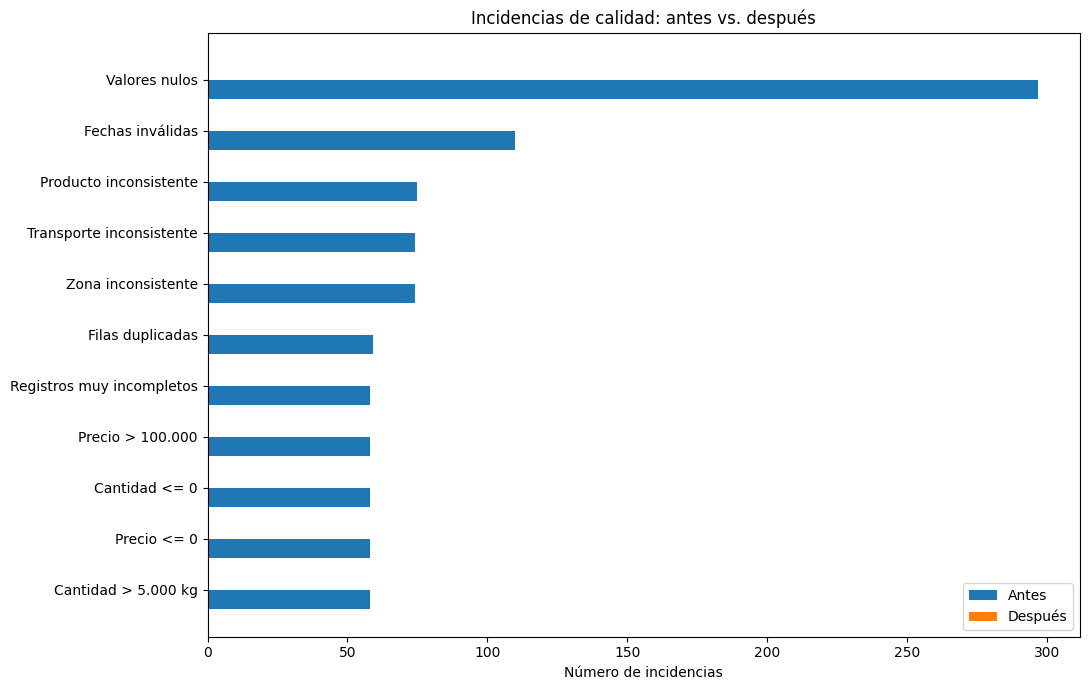

In [ ]:

grafica_calidad = (
    tabla_calidad
    .sort_values(
        "Antes",
        ascending=True
    )
)

y = np.arange(
    len(grafica_calidad)
)

alto = 0.38

plt.figure(
    figsize=(11, 7)
)

plt.barh(
    y - alto / 2,
    grafica_calidad["Antes"],
    height=alto,
    label="Antes"
)

plt.barh(
    y + alto / 2,
    grafica_calidad["Después"],
    height=alto,
    label="Después"
)

plt.yticks(
    y,
    grafica_calidad["Indicador"]
)

plt.title(
    "Incidencias de calidad: antes vs. después"
)

plt.xlabel(
    "Número de incidencias"
)

plt.legend()
plt.tight_layout()
plt.show()



## 16.3 Tabla y gráfica — Completitud por columna

La completitud indica qué porcentaje de valores de cada columna está disponible.

Una columna con 100 % de completitud no contiene valores nulos.


,Columna,Antes (%),Después (%),Cambio (p.p.)
0,id_registro,100.00,100.0,0.00
1,rol,100.00,100.0,0.00
2,producto,98.50,100.0,1.50
3,zona,97.80,100.0,2.20
4,cantidad_kg,97.45,100.0,2.55
5,precio_objetivo_cop_kg,97.20,100.0,2.80
6,fecha_registro,97.80,100.0,2.20
7,fecha_disponibilidad_o_necesidad,99.60,100.0,0.40
8,transporte_disponible,96.80,100.0,3.20
9,dias_desde_cosecha,100.00,100.0,0.00


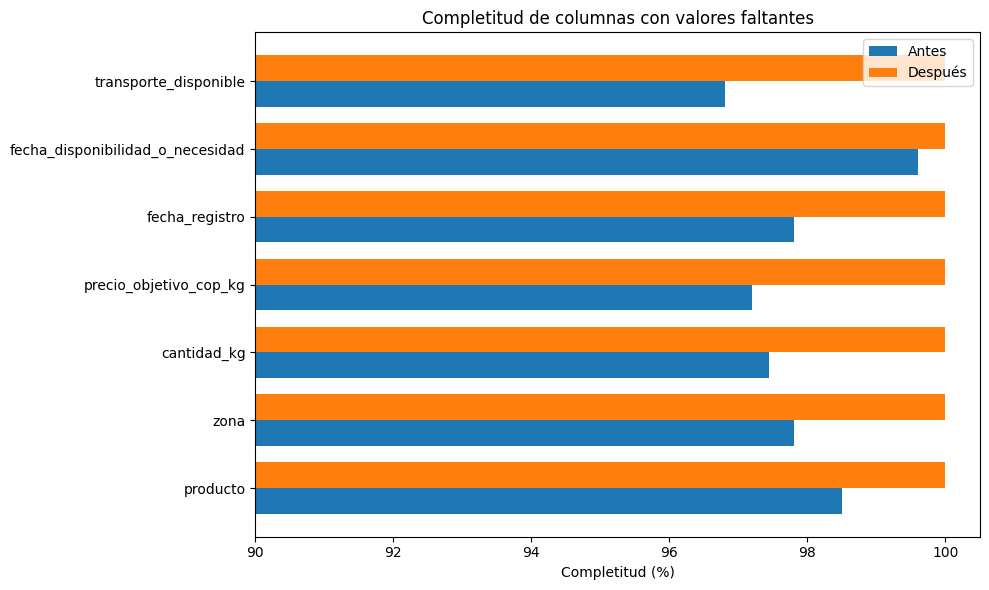

In [ ]:

completitud_antes = (
    1
    - df_sucio.isna().mean()
) * 100

completitud_despues = (
    1
    - df_limpio.isna().mean()
) * 100

tabla_completitud = pd.DataFrame({
    "Columna": df_sucio.columns,
    "Antes (%)": [
        completitud_antes.get(
            columna,
            np.nan
        )
        for columna in df_sucio.columns
    ],
    "Después (%)": [
        completitud_despues.get(
            columna,
            np.nan
        )
        for columna in df_sucio.columns
    ]
})

# Mostramos primero las columnas que tuvieron cambios.
tabla_completitud["Cambio (p.p.)"] = (
    tabla_completitud["Después (%)"]
    - tabla_completitud["Antes (%)"]
)

display(
    tabla_completitud
    .round(2)
)

tabla_grafica_completitud = (
    tabla_completitud[
        tabla_completitud["Antes (%)"] < 100
    ]
    .copy()
)

if len(tabla_grafica_completitud) > 0:

    y = np.arange(
        len(tabla_grafica_completitud)
    )

    alto = 0.38

    plt.figure(
        figsize=(10, 6)
    )

    plt.barh(
        y - alto / 2,
        tabla_grafica_completitud["Antes (%)"],
        height=alto,
        label="Antes"
    )

    plt.barh(
        y + alto / 2,
        tabla_grafica_completitud["Después (%)"],
        height=alto,
        label="Después"
    )

    plt.yticks(
        y,
        tabla_grafica_completitud["Columna"]
    )

    plt.xlim(
        90,
        100.5
    )

    plt.title(
        "Completitud de columnas con valores faltantes"
    )

    plt.xlabel(
        "Completitud (%)"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()



## 16.4 Tabla — Variantes de escritura detectadas en TODOS los productos

Esta tabla valida que la normalización no está centrada únicamente en Mora.

Cada valor original se asigna a su producto canónico. Se listan las distintas formas encontradas antes de limpiar.


In [ ]:

# ============================================================
# VARIANTES DE PRODUCTO ANTES DE LIMPIAR
# ============================================================

registros_variantes = []

for valor_original, cantidad in (
    df_sucio["producto"]
    .dropna()
    .astype(str)
    .value_counts()
    .items()
):
    canonico = producto_canonico(
        valor_original
    )

    if canonico is not None:
        registros_variantes.append({
            "Producto canónico": canonico,
            "Valor encontrado": valor_original,
            "Cantidad": int(cantidad),
            "¿Es escritura canónica?":
                "Sí"
                if valor_original == canonico
                else "No"
        })


tabla_variantes_producto = (
    pd.DataFrame(
        registros_variantes
    )
    .sort_values([
        "Producto canónico",
        "¿Es escritura canónica?",
        "Valor encontrado"
    ])
    .reset_index(drop=True)
)

display(
    tabla_variantes_producto
)


,Producto canónico,Valor encontrado,Cantidad,¿Es escritura canónica?
0,Aguacate,Aguacate,1,No
1,Aguacate,AGUACATE,1,No
2,Aguacate,aguacate,4,No
3,Aguacate,Aguacate,188,Sí
4,Banano,Banano,1,No
5,Banano,Banano,1,No
6,Banano,BANANO,4,No
7,Banano,banano,1,No
8,Banano,Banano,191,Sí
9,Café pergamino seco,Café pergamino seco,3,No



## 16.5 Gráfica — Número de formas de escribir cada producto

Para cada producto se cuenta cuántas etiquetas distintas aparecen antes de limpiar.

Después de normalizar, cada producto debe quedar representado por **una sola forma canónica**.


,Producto,Formas antes,Formas después
0,Aguacate,4,1
1,Banano,5,1
2,Café pergamino seco,4,1
3,Cítricos,5,1
4,Guanábana,5,1
5,Habichuela,5,1
6,Lulo,4,1
7,Mora,5,1
8,Pimentón,4,1
9,Tomate de árbol,4,1


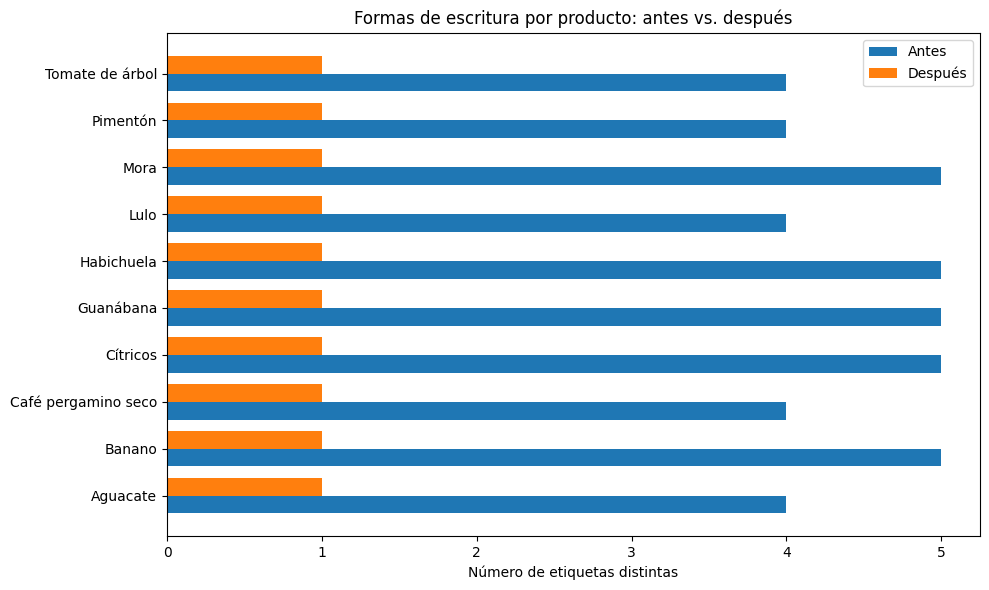

In [ ]:

variantes_por_producto_antes = (
    tabla_variantes_producto
    .groupby(
        "Producto canónico"
    )["Valor encontrado"]
    .nunique()
    .reindex(
        CATALOGO_CANONICO
    )
    .fillna(0)
)

variantes_por_producto_despues = pd.Series(
    1,
    index=CATALOGO_CANONICO
)

tabla_variantes_resumen = pd.DataFrame({
    "Producto": CATALOGO_CANONICO,
    "Formas antes": [
        int(
            variantes_por_producto_antes[
                producto
            ]
        )
        for producto in CATALOGO_CANONICO
    ],
    "Formas después": [
        int(
            variantes_por_producto_despues[
                producto
            ]
        )
        for producto in CATALOGO_CANONICO
    ]
})

display(
    tabla_variantes_resumen
)

y = np.arange(
    len(tabla_variantes_resumen)
)

alto = 0.38

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    y - alto / 2,
    tabla_variantes_resumen["Formas antes"],
    height=alto,
    label="Antes"
)

plt.barh(
    y + alto / 2,
    tabla_variantes_resumen["Formas después"],
    height=alto,
    label="Después"
)

plt.yticks(
    y,
    tabla_variantes_resumen["Producto"]
)

plt.title(
    "Formas de escritura por producto: antes vs. después"
)

plt.xlabel(
    "Número de etiquetas distintas"
)

plt.legend()
plt.tight_layout()
plt.show()



## 16.6 Gráfica — Cardinalidad de categorías

La cardinalidad es el número de valores distintos de una variable categórica.

Si hay errores de escritura, aparecen categorías artificiales adicionales.

Comparamos:

- producto;
- zona;
- transporte.


,Variable,Antes,Después
0,Producto,45,10
1,Zona,25,5
2,Transporte,12,2


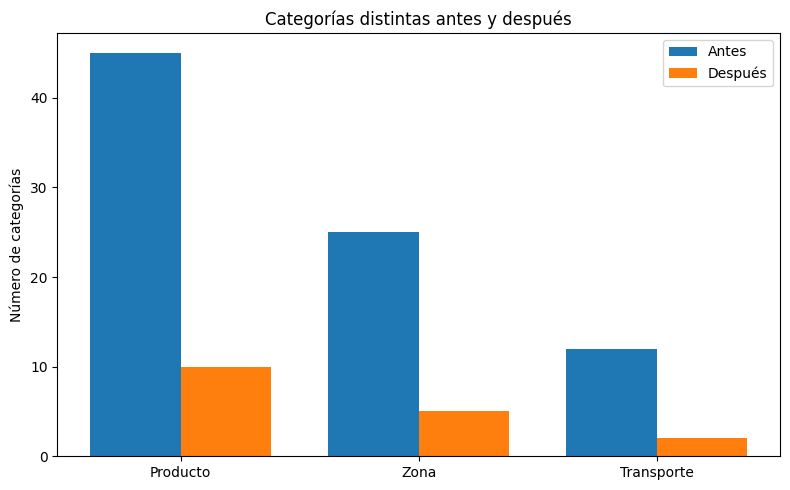

In [ ]:

cardinalidad = pd.DataFrame({
    "Variable": [
        "Producto",
        "Zona",
        "Transporte"
    ],

    "Antes": [
        int(
            df_sucio["producto"]
            .nunique(dropna=True)
        ),
        int(
            df_sucio["zona"]
            .nunique(dropna=True)
        ),
        int(
            df_sucio[
                "transporte_disponible"
            ]
            .nunique(dropna=True)
        )
    ],

    "Después": [
        int(
            df_limpio["producto"]
            .nunique(dropna=True)
        ),
        int(
            df_limpio["zona"]
            .nunique(dropna=True)
        ),
        int(
            df_limpio[
                "transporte_disponible"
            ]
            .nunique(dropna=True)
        )
    ]
})

display(
    cardinalidad
)

x = np.arange(
    len(cardinalidad)
)

ancho = 0.38

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    x - ancho / 2,
    cardinalidad["Antes"],
    width=ancho,
    label="Antes"
)

plt.bar(
    x + ancho / 2,
    cardinalidad["Después"],
    width=ancho,
    label="Después"
)

plt.xticks(
    x,
    cardinalidad["Variable"]
)

plt.title(
    "Categorías distintas antes y después"
)

plt.ylabel(
    "Número de categorías"
)

plt.legend()
plt.tight_layout()
plt.show()



## 16.7 Gráfica — Distribución de cantidades antes vs. después

El boxplot permite ver el efecto de corregir:

- cantidades negativas;
- cantidades exageradamente altas.

No se busca cambiar la distribución válida, sino retirar o sustituir valores imposibles.


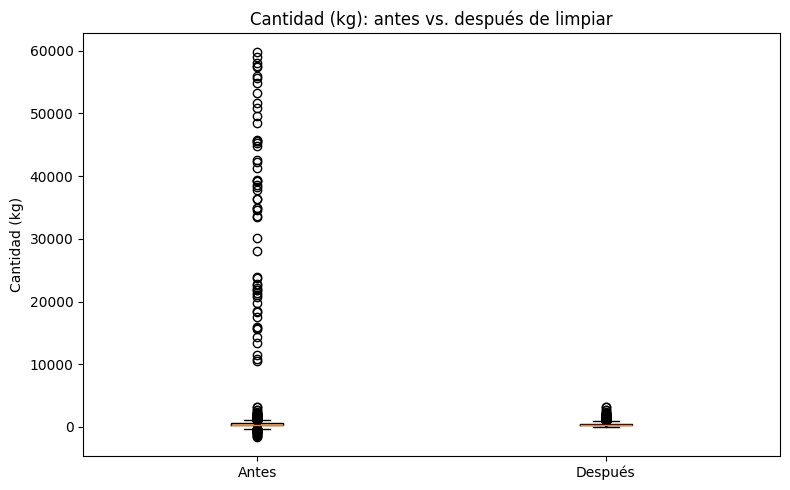

In [ ]:

cantidad_antes_box = pd.to_numeric(
    df_sucio["cantidad_kg"],
    errors="coerce"
).dropna()

cantidad_despues_box = pd.to_numeric(
    df_limpio["cantidad_kg"],
    errors="coerce"
).dropna()

plt.figure(
    figsize=(8, 5)
)

plt.boxplot(
    [
        cantidad_antes_box,
        cantidad_despues_box
    ],
    tick_labels=[
        "Antes",
        "Después"
    ]
)

plt.title(
    "Cantidad (kg): antes vs. después de limpiar"
)

plt.ylabel(
    "Cantidad (kg)"
)

plt.tight_layout()
plt.show()



## 16.8 Gráfica — Distribución de precios antes vs. después

Permite observar el efecto de corregir:

- precios en cero;
- precios artificialmente exagerados.


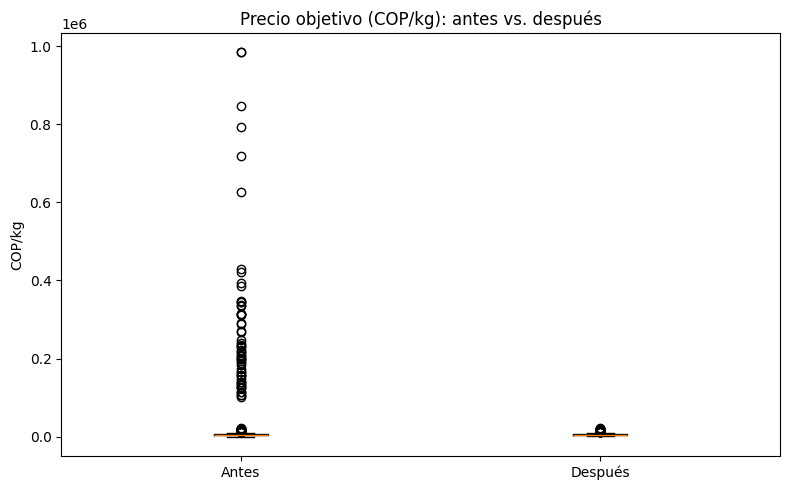

In [ ]:

precio_antes_box = pd.to_numeric(
    df_sucio[
        "precio_objetivo_cop_kg"
    ],
    errors="coerce"
).dropna()

precio_despues_box = pd.to_numeric(
    df_limpio[
        "precio_objetivo_cop_kg"
    ],
    errors="coerce"
).dropna()

plt.figure(
    figsize=(8, 5)
)

plt.boxplot(
    [
        precio_antes_box,
        precio_despues_box
    ],
    tick_labels=[
        "Antes",
        "Después"
    ]
)

plt.title(
    "Precio objetivo (COP/kg): antes vs. después"
)

plt.ylabel(
    "COP/kg"
)

plt.tight_layout()
plt.show()



## 16.9 Gráfica — Dimensiones generales de calidad

Para resumir el resultado definimos cinco indicadores sencillos, calculados sobre la misma base:

### Completitud
Porcentaje de celdas no nulas.

### Unicidad
Porcentaje de filas que no son duplicados exactos.

### Validez numérica
Porcentaje de valores válidos en cantidad y precio según los rangos definidos.

### Validez temporal
Porcentaje de fechas que pueden interpretarse correctamente.

### Consistencia categórica
Porcentaje de valores escritos exactamente en las formas canónicas de producto, zona y transporte.

Estos indicadores se utilizan únicamente como resumen didáctico de calidad de datos.


,Dimensión,Antes (%),Después (%)
0,Completitud,99.01,100.0
1,Unicidad,97.05,100.0
2,Validez numérica,91.52,100.0
3,Validez temporal,97.25,100.0
4,Consistencia categórica,93.98,100.0


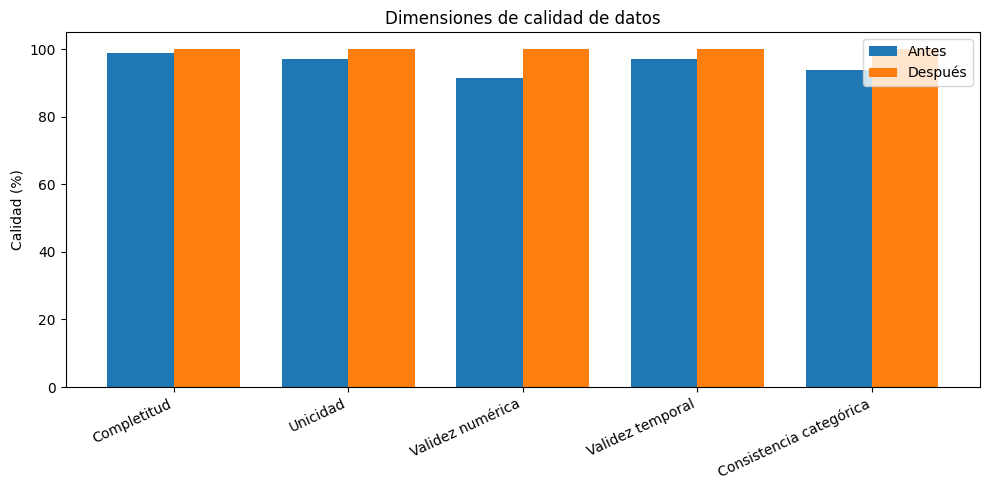

In [ ]:

def indicadores_calidad_porcentaje(df_revision):
    df_base = df_revision[
        [
            c for c in df_revision.columns
            if not c.startswith("_")
        ]
    ].copy()

    cantidad = pd.to_numeric(
        df_base["cantidad_kg"],
        errors="coerce"
    )

    precio = pd.to_numeric(
        df_revision[
            "precio_objetivo_cop_kg"
        ],
        errors="coerce"
    )

    fecha_1 = pd.to_datetime(
        df_base["fecha_registro"],
        errors="coerce"
    )

    fecha_2 = pd.to_datetime(
        df_revision[
            "fecha_disponibilidad_o_necesidad"
        ],
        errors="coerce"
    )

    completitud = (
        1
        - df_base.isna().sum().sum()
        / df_base.size
    ) * 100

    unicidad = (
        1
        - df_base.duplicated().sum()
        / len(df_base)
    ) * 100

    validos_cantidad = (
        (cantidad > 0)
        & (cantidad <= 5000)
    ).sum()

    validos_precio = (
        (precio > 0)
        & (precio <= 100000)
    ).sum()

    validez_numerica = (
        validos_cantidad
        + validos_precio
    ) / (
        2 * len(df_base)
    ) * 100

    validez_temporal = (
        fecha_1.notna().sum()
        + fecha_2.notna().sum()
    ) / (
        2 * len(df_base)
    ) * 100

    # Un valor nulo no puede considerarse consistente.
    consistentes_producto = (
        df_base["producto"].notna()
        &
        (
            ~df_base["producto"]
            .apply(producto_inconsistente)
        )
    ).sum()

    consistentes_zona = (
        df_base["zona"].notna()
        &
        (
            ~df_base["zona"]
            .apply(zona_inconsistente)
        )
    ).sum()

    consistentes_transporte = (
        df_base["transporte_disponible"].notna()
        &
        (
            ~df_revision[
                "transporte_disponible"
            ]
            .apply(
                transporte_inconsistente_func
            )
        )
    ).sum()

    consistencia_categorica = (
        consistentes_producto
        + consistentes_zona
        + consistentes_transporte
    ) / (
        3 * len(df_base)
    ) * 100

    return {
        "Completitud": completitud,
        "Unicidad": unicidad,
        "Validez numérica": validez_numerica,
        "Validez temporal": validez_temporal,
        "Consistencia categórica":
            consistencia_categorica
    }


indicadores_antes = (
    indicadores_calidad_porcentaje(
        df_sucio
    )
)

indicadores_despues = (
    indicadores_calidad_porcentaje(
        df_limpio
    )
)

tabla_indicadores = pd.DataFrame({
    "Dimensión": list(
        indicadores_antes.keys()
    ),

    "Antes (%)": list(
        indicadores_antes.values()
    ),

    "Después (%)": [
        indicadores_despues[
            dimension
        ]
        for dimension
        in indicadores_antes.keys()
    ]
})

display(
    tabla_indicadores.round(2)
)

x = np.arange(
    len(tabla_indicadores)
)

ancho = 0.38

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    x - ancho / 2,
    tabla_indicadores["Antes (%)"],
    width=ancho,
    label="Antes"
)

plt.bar(
    x + ancho / 2,
    tabla_indicadores["Después (%)"],
    width=ancho,
    label="Después"
)

plt.xticks(
    x,
    tabla_indicadores["Dimensión"],
    rotation=25,
    ha="right"
)

plt.ylim(
    0,
    105
)

plt.title(
    "Dimensiones de calidad de datos"
)

plt.ylabel(
    "Calidad (%)"
)

plt.legend()
plt.tight_layout()
plt.show()



## 16.10 Tabla y gráfica — Acciones ejecutadas durante la limpieza

Esta gráfica resume las **acciones o incidencias tratadas**, no filas únicas.

Es útil para explicar qué hizo realmente el cuadernillo:

- eliminó duplicados;
- eliminó registros irreparables;
- imputó cantidades y precios inválidos;
- normalizó productos, zonas y transporte;
- corrigió fechas.

Una misma fila podría requerir más de una acción en un dataset real.


,Operación,Cantidad
0,Duplicados eliminados,59
1,Registros muy incompletos eliminados,58
2,Cantidades corregidas,116
3,Precios corregidos,116
4,Productos normalizados detectados,75
5,Zonas normalizadas detectadas,74
6,Transportes normalizados detectados,74
7,Fechas inválidas tratadas,110


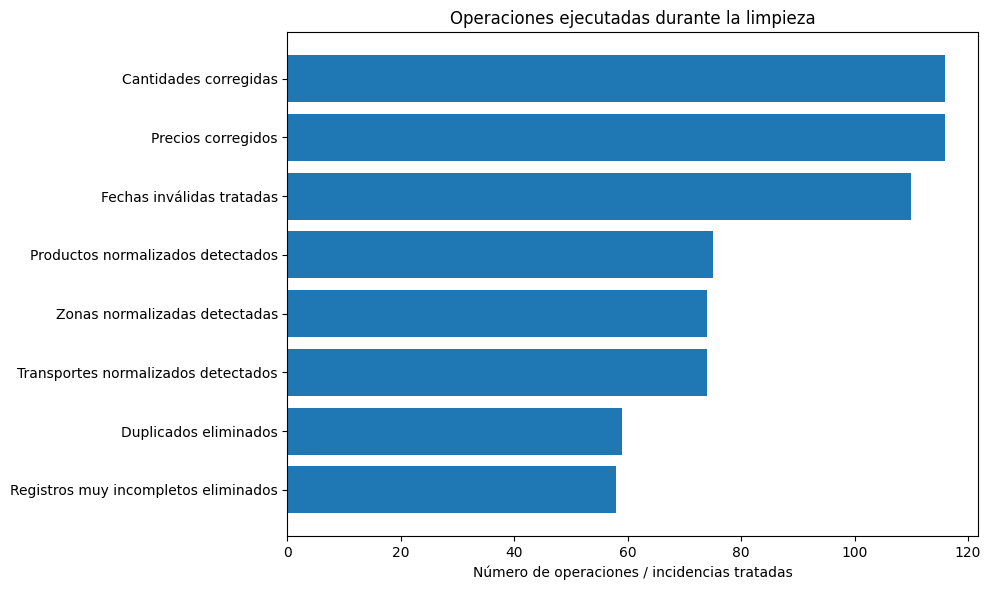

In [ ]:

# Cantidad de valores categóricos que cambiaron
# entre el original y el resultado normalizado.
productos_normalizados = int(
    (
        productos_originales
        .fillna("")
        .astype(str)
        !=
        df_limpio["producto"]
        .reindex(
            productos_originales.index
        )
        .fillna("")
        .astype(str)
    )
    .sum()
)

# Para evitar comparar índices eliminados directamente,
# reportamos como operaciones categóricas las incidencias
# detectadas inicialmente.
operaciones_limpieza = pd.DataFrame({
    "Operación": [
        "Duplicados eliminados",
        "Registros muy incompletos eliminados",
        "Cantidades corregidas",
        "Precios corregidos",
        "Productos normalizados detectados",
        "Zonas normalizadas detectadas",
        "Transportes normalizados detectados",
        "Fechas inválidas tratadas"
    ],

    "Cantidad": [
        duplicados_antes,
        incompletos_eliminados,
        cantidades_invalidas,
        precios_invalidos,
        inconsistencias_producto,
        zonas_inconsistentes,
        transporte_inconsistente,
        fechas_invalidas
    ]
})

display(
    operaciones_limpieza
)

grafica_operaciones = (
    operaciones_limpieza
    .sort_values(
        "Cantidad",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    grafica_operaciones["Operación"],
    grafica_operaciones["Cantidad"]
)

plt.title(
    "Operaciones ejecutadas durante la limpieza"
)

plt.xlabel(
    "Número de operaciones / incidencias tratadas"
)

plt.tight_layout()
plt.show()



## 16.11 Interpretación de la limpieza

Las gráficas anteriores permiten sustentar que la limpieza no consistió únicamente en borrar registros.

El proceso aplicó distintas estrategias:

- **normalización:** productos, zonas y transporte;
- **eliminación:** duplicados y registros demasiado incompletos;
- **imputación robusta:** cantidades y precios inválidos mediante mediana por producto y rol;
- **conversión e imputación temporal:** fechas inválidas;
- **validación final:** comprobación de que los errores críticos fueron reducidos.

La normalización de productos se aplica a **todo el catálogo de 10 productos**.



# 17. Diagnóstico gráfico avanzado de la limpieza

Este bloque agrega visualizaciones específicas para validar **estructura, completitud, volumen, anomalías y consistencia**.

Las gráficas anteriores se conservan. Estas nuevas visualizaciones complementan la evidencia de la Semana 4.



## 17.1 Mapa de calor de nulos — Antes de limpiar

Cada fila representa un registro y cada columna una variable. Un valor presente se representa como `1` y un valor faltante como `0`.


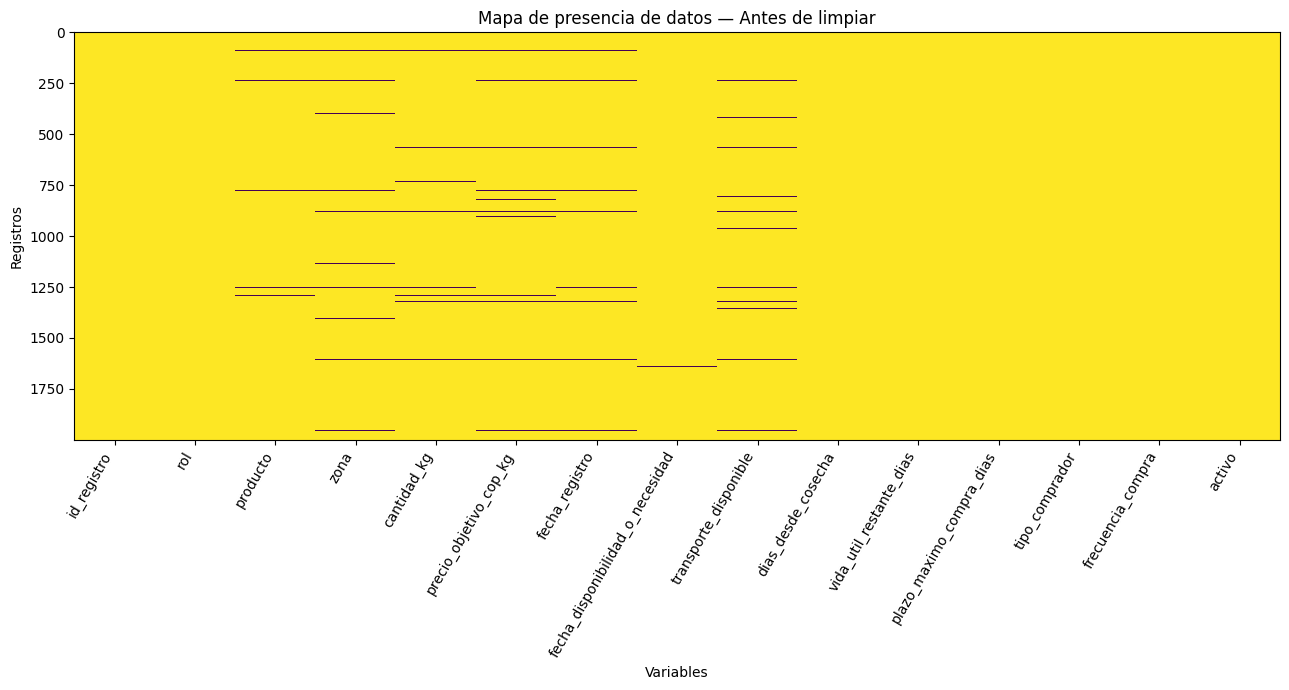

In [ ]:

columnas_originales = list(df_sucio.columns)

presencia_antes = (
    df_sucio[columnas_originales]
    .notna()
    .astype(int)
)

plt.figure(figsize=(13, 7))
plt.imshow(
    presencia_antes.values,
    aspect="auto",
    interpolation="nearest"
)
plt.title("Mapa de presencia de datos — Antes de limpiar")
plt.xlabel("Variables")
plt.ylabel("Registros")
plt.xticks(
    range(len(columnas_originales)),
    columnas_originales,
    rotation=60,
    ha="right"
)
plt.tight_layout()
plt.show()



## 17.2 Mapa de calor de nulos — Después de limpiar

Si la limpieza de completitud fue exitosa, la matriz final debe verse uniforme y sin vacíos en las variables de datos.


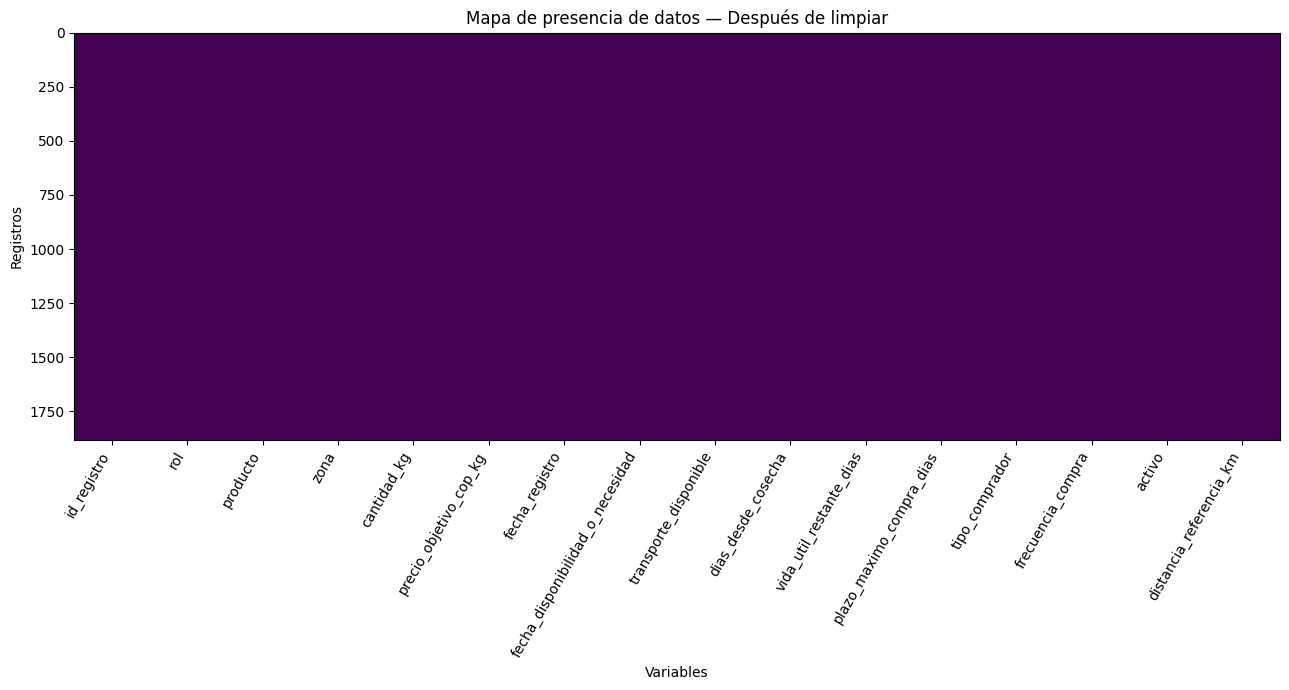

In [ ]:

columnas_limpias = [
    c for c in df_limpio.columns
    if not c.startswith("_")
]

presencia_despues = (
    df_limpio[columnas_limpias]
    .notna()
    .astype(int)
)

plt.figure(figsize=(13, 7))
plt.imshow(
    presencia_despues.values,
    aspect="auto",
    interpolation="nearest"
)
plt.title("Mapa de presencia de datos — Después de limpiar")
plt.xlabel("Variables")
plt.ylabel("Registros")
plt.xticks(
    range(len(columnas_limpias)),
    columnas_limpias,
    rotation=60,
    ha="right"
)
plt.tight_layout()
plt.show()



## 17.3 Barras de valores nulos por columna

Compara el número exacto de valores faltantes antes y después de la limpieza.


,Columna,Antes,Después
0,id_registro,0,0
1,rol,0,0
2,producto,30,0
3,zona,44,0
4,cantidad_kg,51,0
5,precio_objetivo_cop_kg,56,0
6,fecha_registro,44,0
7,fecha_disponibilidad_o_necesidad,8,0
8,transporte_disponible,64,0
9,dias_desde_cosecha,0,0


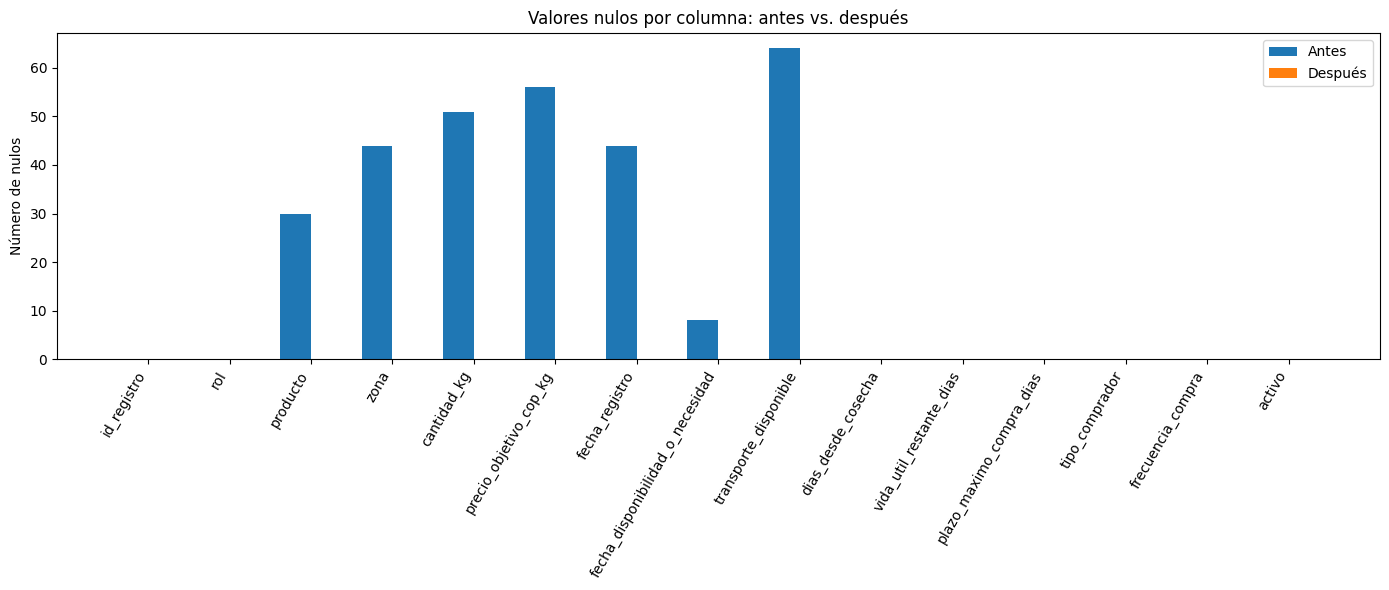

In [ ]:

nulos_antes_col = df_sucio.isna().sum()

nulos_despues_col = (
    df_limpio[columnas_limpias]
    .isna()
    .sum()
)

comparacion_nulos_columnas = pd.DataFrame({
    "Columna": columnas_originales,
    "Antes": [
        int(nulos_antes_col.get(c, 0))
        for c in columnas_originales
    ],
    "Después": [
        int(nulos_despues_col.get(c, 0))
        for c in columnas_originales
    ]
})

display(comparacion_nulos_columnas)

x = np.arange(len(comparacion_nulos_columnas))
ancho = 0.38

plt.figure(figsize=(14, 6))
plt.bar(
    x - ancho / 2,
    comparacion_nulos_columnas["Antes"],
    width=ancho,
    label="Antes"
)
plt.bar(
    x + ancho / 2,
    comparacion_nulos_columnas["Después"],
    width=ancho,
    label="Después"
)
plt.xticks(
    x,
    comparacion_nulos_columnas["Columna"],
    rotation=60,
    ha="right"
)
plt.title("Valores nulos por columna: antes vs. después")
plt.ylabel("Número de nulos")
plt.legend()
plt.tight_layout()
plt.show()



## 17.4 Embudo de conservación de registros

El embudo muestra cuántas filas quedan después de cada etapa que realmente elimina registros.

En este cuadernillo se eliminan:

- duplicados exactos;
- registros demasiado incompletos.

Las demás incidencias se corrigen o imputan.


,Etapa,Registros,Retención (%)
0,Dataset original,2000,100.00
1,Tras eliminar duplicados,1941,97.05
2,Tras eliminar incompletos,1883,94.15
3,Dataset limpio final,1883,94.15


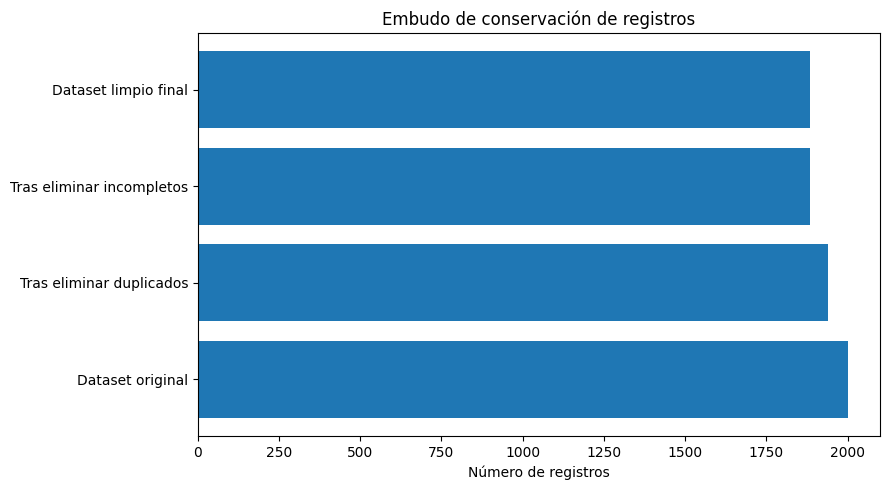

In [ ]:

registros_inicio = registros_iniciales
registros_tras_duplicados = registros_inicio - duplicados_antes
registros_tras_incompletos = len(df_limpio)
registros_finales = len(df_limpio)

embudo = pd.DataFrame({
    "Etapa": [
        "Dataset original",
        "Tras eliminar duplicados",
        "Tras eliminar incompletos",
        "Dataset limpio final"
    ],
    "Registros": [
        registros_inicio,
        registros_tras_duplicados,
        registros_tras_incompletos,
        registros_finales
    ]
})

embudo["Retención (%)"] = (
    embudo["Registros"]
    / registros_inicio
    * 100
).round(2)

display(embudo)

plt.figure(figsize=(9, 5))
plt.barh(
    embudo["Etapa"],
    embudo["Registros"]
)
plt.title("Embudo de conservación de registros")
plt.xlabel("Número de registros")
plt.tight_layout()
plt.show()



## 17.5 Boxplot de cantidades — Antes de limpiar


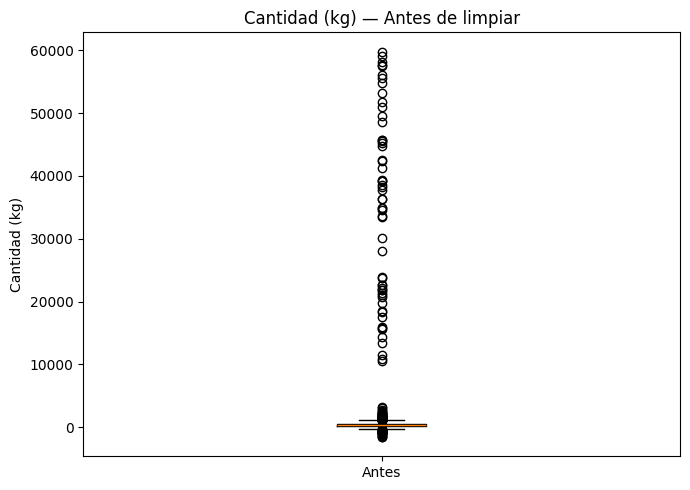

In [ ]:

cantidad_antes_plot = pd.to_numeric(
    df_sucio["cantidad_kg"],
    errors="coerce"
).dropna()

plt.figure(figsize=(7, 5))
plt.boxplot(cantidad_antes_plot)
plt.title("Cantidad (kg) — Antes de limpiar")
plt.ylabel("Cantidad (kg)")
plt.xticks([1], ["Antes"])
plt.tight_layout()
plt.show()



## 17.6 Boxplot de cantidades — Después de limpiar


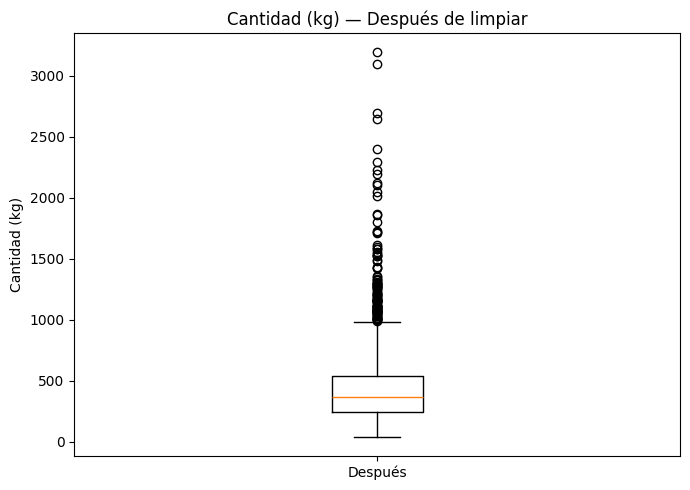

In [ ]:

cantidad_despues_plot = pd.to_numeric(
    df_limpio["cantidad_kg"],
    errors="coerce"
).dropna()

plt.figure(figsize=(7, 5))
plt.boxplot(cantidad_despues_plot)
plt.title("Cantidad (kg) — Después de limpiar")
plt.ylabel("Cantidad (kg)")
plt.xticks([1], ["Después"])
plt.tight_layout()
plt.show()



## 17.7 Histogramas de densidad de cantidades

La comparación permite comprobar que la corrección de extremos no elimina la concentración principal de los datos.


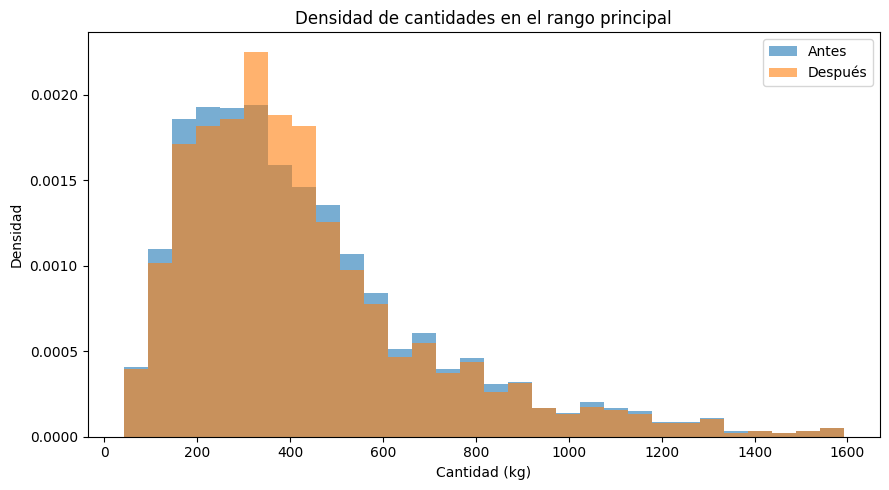

In [ ]:

limite_cantidad = float(
    df_limpio["cantidad_kg"]
    .quantile(0.99)
)

plt.figure(figsize=(9, 5))
plt.hist(
    cantidad_antes_plot[
        cantidad_antes_plot.between(0, limite_cantidad)
    ],
    bins=30,
    density=True,
    alpha=0.6,
    label="Antes"
)
plt.hist(
    cantidad_despues_plot[
        cantidad_despues_plot.between(0, limite_cantidad)
    ],
    bins=30,
    density=True,
    alpha=0.6,
    label="Después"
)
plt.title("Densidad de cantidades en el rango principal")
plt.xlabel("Cantidad (kg)")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()



## 17.8 Boxplots e histograma de precios

Primero se observa el efecto de los precios extremos y luego se compara la distribución principal antes y después.


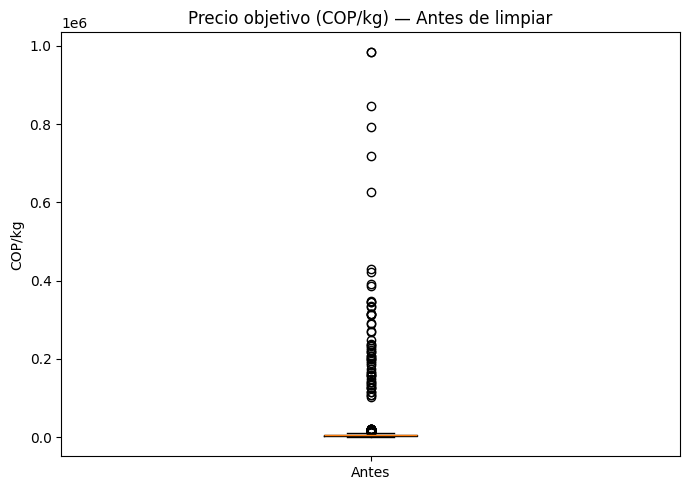

In [ ]:

precio_antes_plot = pd.to_numeric(
    df_sucio["precio_objetivo_cop_kg"],
    errors="coerce"
).dropna()

plt.figure(figsize=(7, 5))
plt.boxplot(precio_antes_plot)
plt.title("Precio objetivo (COP/kg) — Antes de limpiar")
plt.ylabel("COP/kg")
plt.xticks([1], ["Antes"])
plt.tight_layout()
plt.show()


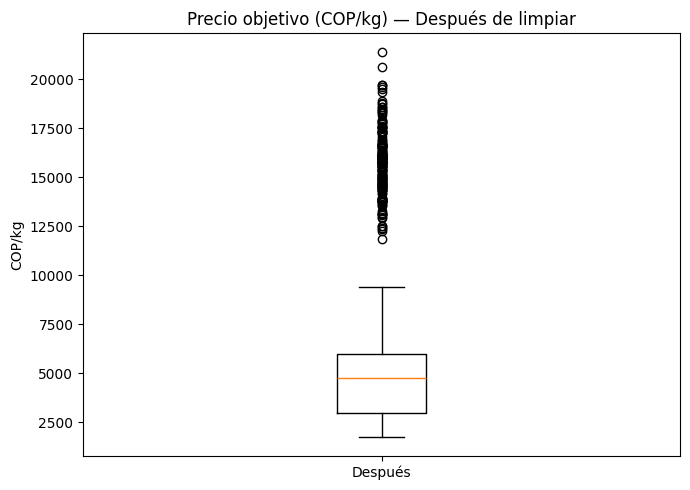

In [ ]:

precio_despues_plot = pd.to_numeric(
    df_limpio["precio_objetivo_cop_kg"],
    errors="coerce"
).dropna()

plt.figure(figsize=(7, 5))
plt.boxplot(precio_despues_plot)
plt.title("Precio objetivo (COP/kg) — Después de limpiar")
plt.ylabel("COP/kg")
plt.xticks([1], ["Después"])
plt.tight_layout()
plt.show()


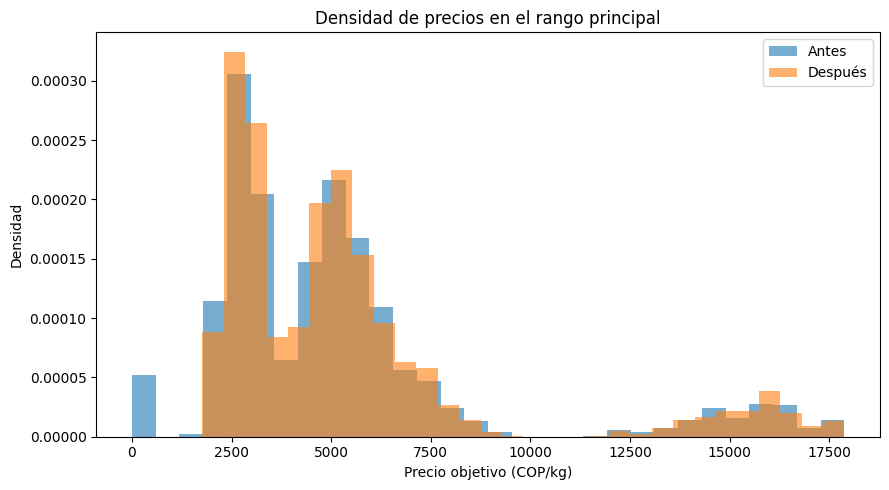

In [ ]:

limite_precio = float(
    df_limpio["precio_objetivo_cop_kg"]
    .quantile(0.99)
)

plt.figure(figsize=(9, 5))
plt.hist(
    precio_antes_plot[
        precio_antes_plot.between(0, limite_precio)
    ],
    bins=30,
    density=True,
    alpha=0.6,
    label="Antes"
)
plt.hist(
    precio_despues_plot[
        precio_despues_plot.between(0, limite_precio)
    ],
    bins=30,
    density=True,
    alpha=0.6,
    label="Después"
)
plt.title("Densidad de precios en el rango principal")
plt.xlabel("Precio objetivo (COP/kg)")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()



## 17.9 Scatter — Cantidad vs. precio con valores corregidos

Los puntos corregidos o imputados se muestran como una serie diferente. Esto permite comprobar que las correcciones numéricas quedaron dentro de una región coherente con el resto del dataset.


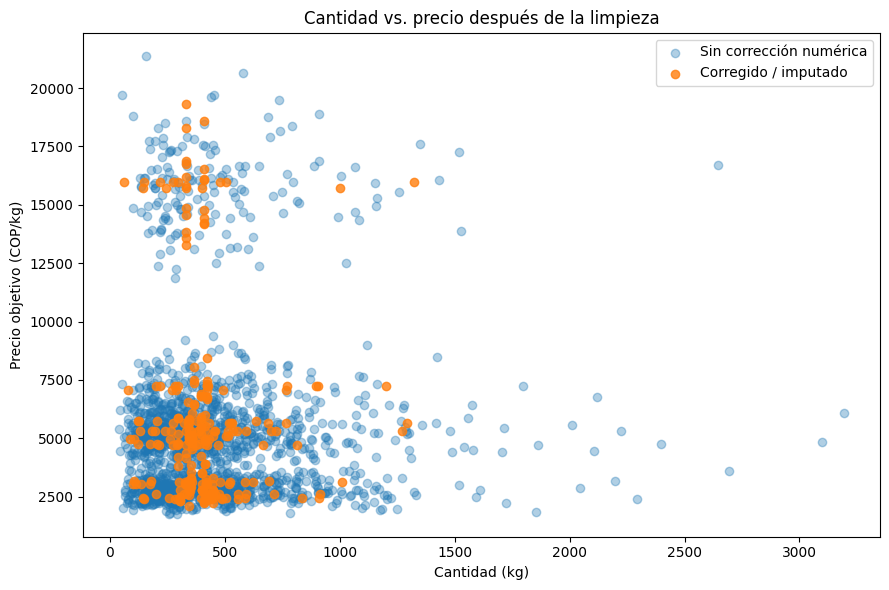

Registros corregidos/imputados mostrados: 259


In [ ]:

mascara_corregidos_scatter = (
    df_limpio["_corr_cantidad"]
    | df_limpio["_corr_precio"]
)

sin_correccion = df_limpio.loc[
    ~mascara_corregidos_scatter
]

con_correccion = df_limpio.loc[
    mascara_corregidos_scatter
]

plt.figure(figsize=(9, 6))

plt.scatter(
    sin_correccion["cantidad_kg"],
    sin_correccion["precio_objetivo_cop_kg"],
    alpha=0.35,
    label="Sin corrección numérica"
)

plt.scatter(
    con_correccion["cantidad_kg"],
    con_correccion["precio_objetivo_cop_kg"],
    alpha=0.8,
    label="Corregido / imputado"
)

plt.title("Cantidad vs. precio después de la limpieza")
plt.xlabel("Cantidad (kg)")
plt.ylabel("Precio objetivo (COP/kg)")
plt.legend()
plt.tight_layout()
plt.show()

print(
    "Registros corregidos/imputados mostrados:",
    int(mascara_corregidos_scatter.sum())
)



## 17.10 Gráfico de barras — Reducción de categorías

La gráfica demuestra la normalización de etiquetas.

Después de limpiar deben quedar:

- 10 productos;
- 5 zonas;
- 2 valores de transporte.


,Variable,Antes,Después
0,Producto,45,10
1,Zona,25,5
2,Transporte,12,2


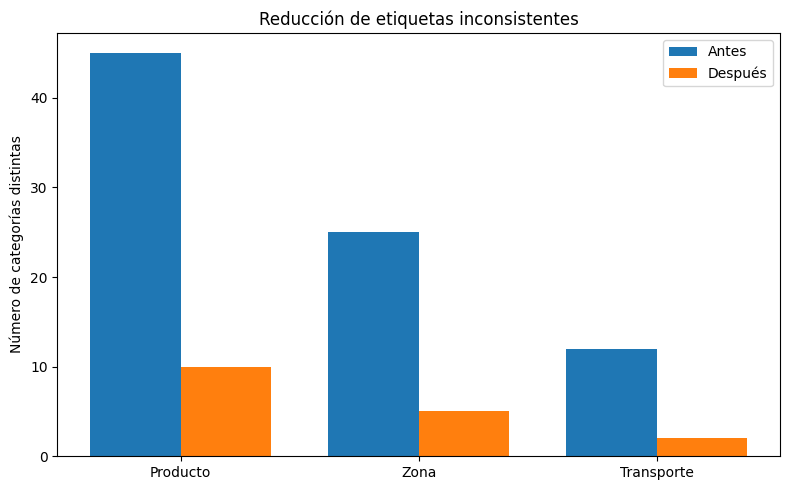

In [ ]:

categorias_consistencia = pd.DataFrame({
    "Variable": [
        "Producto",
        "Zona",
        "Transporte"
    ],
    "Antes": [
        int(df_sucio["producto"].nunique(dropna=True)),
        int(df_sucio["zona"].nunique(dropna=True)),
        int(df_sucio["transporte_disponible"].nunique(dropna=True))
    ],
    "Después": [
        int(df_limpio["producto"].nunique(dropna=True)),
        int(df_limpio["zona"].nunique(dropna=True)),
        int(df_limpio["transporte_disponible"].nunique(dropna=True))
    ]
})

display(categorias_consistencia)

x = np.arange(len(categorias_consistencia))
ancho = 0.38

plt.figure(figsize=(8, 5))
plt.bar(
    x - ancho / 2,
    categorias_consistencia["Antes"],
    width=ancho,
    label="Antes"
)
plt.bar(
    x + ancho / 2,
    categorias_consistencia["Después"],
    width=ancho,
    label="Después"
)
plt.xticks(
    x,
    categorias_consistencia["Variable"]
)
plt.title("Reducción de etiquetas inconsistentes")
plt.ylabel("Número de categorías distintas")
plt.legend()
plt.tight_layout()
plt.show()



## 17.11 Mapa de calor de correlación

Se utiliza como diagnóstico de relaciones lineales entre variables numéricas.

Una correlación muy alta puede señalar una **posible redundancia**, pero no eliminamos una columna automáticamente solo porque exista correlación.


,cantidad_kg,precio_objetivo_cop_kg,dias_desde_cosecha,vida_util_restante_dias,plazo_maximo_compra_dias,distancia_referencia_km
cantidad_kg,1.000,0.010,0.083,0.059,-0.089,0.017
precio_objetivo_cop_kg,0.010,1.000,0.093,0.614,-0.009,0.043
dias_desde_cosecha,0.083,0.093,1.000,0.310,-0.543,0.017
vida_util_restante_dias,0.059,0.614,0.310,1.000,-0.232,0.033
plazo_maximo_compra_dias,-0.089,-0.009,-0.543,-0.232,1.000,0.007
distancia_referencia_km,0.017,0.043,0.017,0.033,0.007,1.000


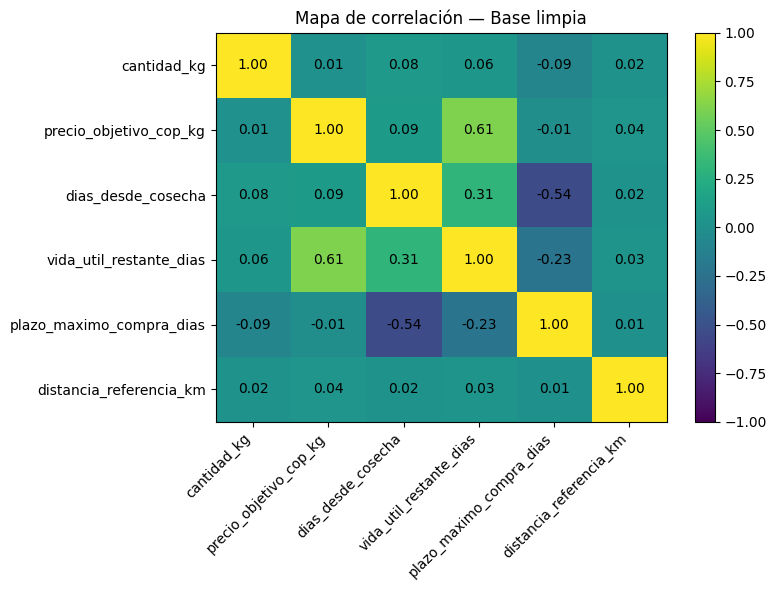

In [ ]:

columnas_corr_avanzada = [
    "cantidad_kg",
    "precio_objetivo_cop_kg",
    "dias_desde_cosecha",
    "vida_util_restante_dias",
    "plazo_maximo_compra_dias",
    "distancia_referencia_km"
]

corr_avanzada = (
    df_limpio[columnas_corr_avanzada]
    .corr()
)

display(corr_avanzada.round(3))

plt.figure(figsize=(8, 6))

imagen_corr = plt.imshow(
    corr_avanzada.values,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(imagen_corr)

plt.xticks(
    range(len(columnas_corr_avanzada)),
    columnas_corr_avanzada,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(columnas_corr_avanzada)),
    columnas_corr_avanzada
)

for i in range(len(columnas_corr_avanzada)):
    for j in range(len(columnas_corr_avanzada)):
        plt.text(
            j,
            i,
            f"{corr_avanzada.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Mapa de correlación — Base limpia")
plt.tight_layout()
plt.show()



## 17.12 Coordenadas paralelas — Antes de limpiar

Esta visualización combina varias variables numéricas en un solo gráfico. Para hacerlas comparables, cada variable se normaliza entre 0 y 1.

Se usa una muestra de hasta 120 registros para mantener la gráfica legible.


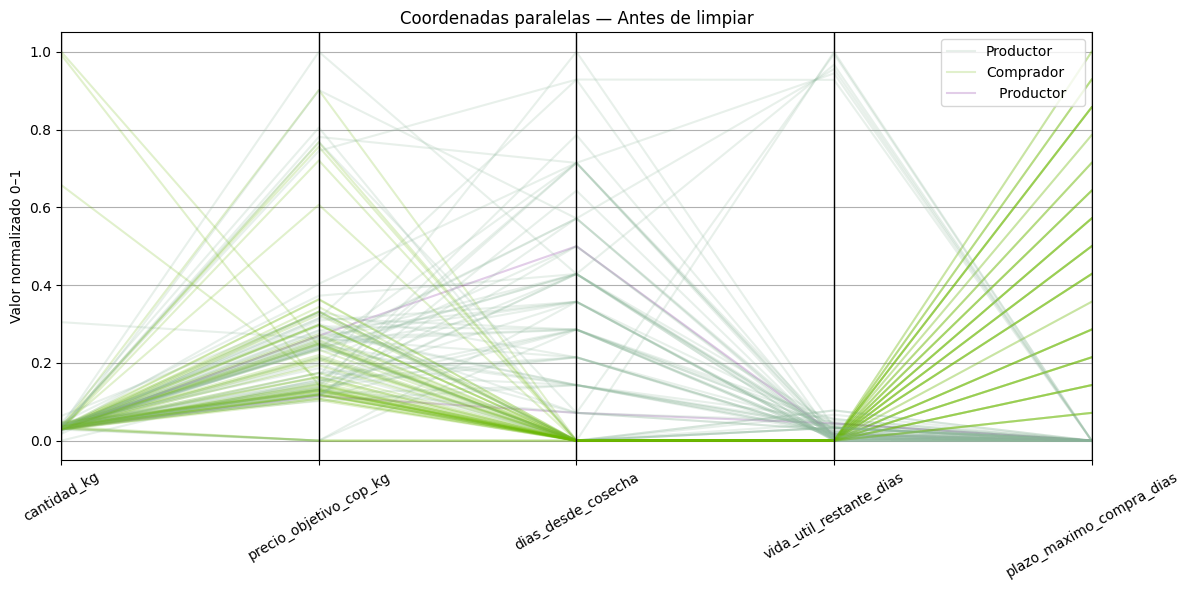

In [ ]:

from pandas.plotting import parallel_coordinates

# Esta celda es autónoma:
# define su propia semilla y variables.
SEED = 42

variables_paralelas = [
    "cantidad_kg",
    "precio_objetivo_cop_kg",
    "dias_desde_cosecha",
    "vida_util_restante_dias",
    "plazo_maximo_compra_dias"
]

antes_paralelo = (
    df_sucio[
        ["rol"] + variables_paralelas
    ]
    .copy()
)

# Convertimos las variables a formato numérico.
for columna in variables_paralelas:
    antes_paralelo[columna] = pd.to_numeric(
        antes_paralelo[columna],
        errors="coerce"
    )

# Eliminamos temporalmente nulos solo para esta visualización
# y tomamos una muestra reproducible de máximo 120 registros.
antes_paralelo = (
    antes_paralelo
    .dropna()
    .sample(
        n=min(
            120,
            len(antes_paralelo.dropna())
        ),
        random_state=SEED
    )
    .copy()
)

# Normalizamos cada variable al rango 0–1
# para poder compararlas en una misma escala.
for columna in variables_paralelas:

    minimo = antes_paralelo[columna].min()
    maximo = antes_paralelo[columna].max()

    if maximo > minimo:

        antes_paralelo[columna] = (
            antes_paralelo[columna]
            - minimo
        ) / (
            maximo
            - minimo
        )

    else:
        antes_paralelo[columna] = 0


plt.figure(figsize=(12, 6))

parallel_coordinates(
    antes_paralelo,
    "rol",
    alpha=0.20
)

plt.title(
    "Coordenadas paralelas — Antes de limpiar"
)

plt.ylabel(
    "Valor normalizado 0–1"
)

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()



## 17.13 Coordenadas paralelas — Después de limpiar

La misma lectura se repite con el dataset limpio. La desaparición de valores artificialmente extremos debe producir un comportamiento más compacto.


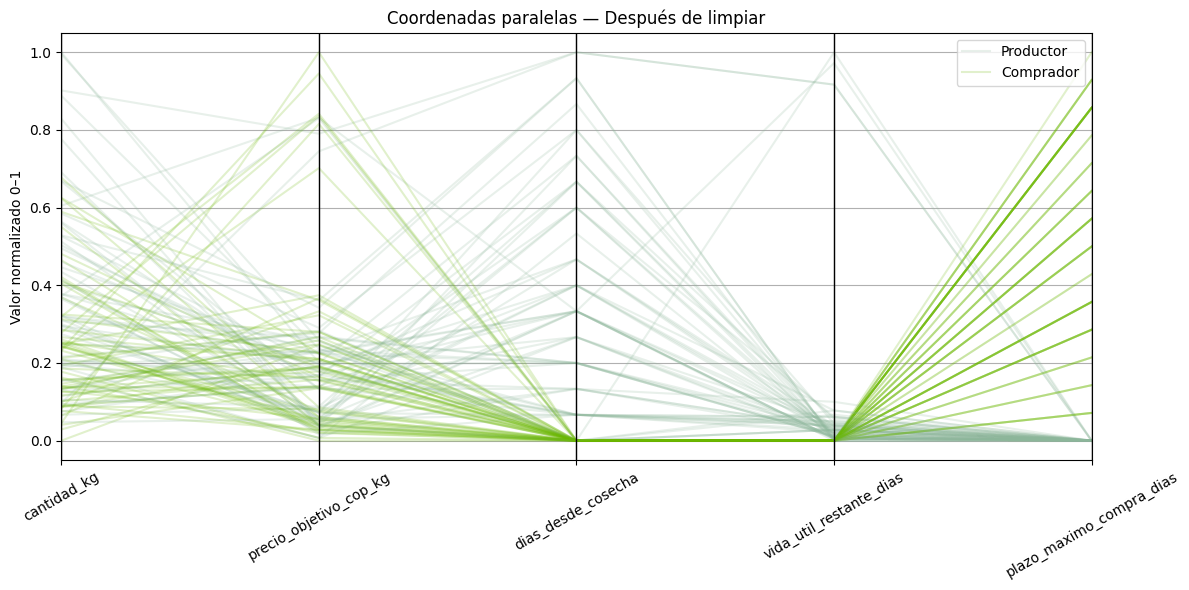

In [ ]:

from pandas.plotting import parallel_coordinates

# Esta celda también es autónoma.
SEED = 42

variables_paralelas = [
    "cantidad_kg",
    "precio_objetivo_cop_kg",
    "dias_desde_cosecha",
    "vida_util_restante_dias",
    "plazo_maximo_compra_dias"
]

despues_paralelo = (
    df_limpio[
        ["rol"] + variables_paralelas
    ]
    .copy()
)

# Aseguramos que todas las variables sean numéricas.
for columna in variables_paralelas:
    despues_paralelo[columna] = pd.to_numeric(
        despues_paralelo[columna],
        errors="coerce"
    )

# Tomamos una muestra reproducible de máximo 120 registros.
despues_paralelo = (
    despues_paralelo
    .dropna()
    .sample(
        n=min(
            120,
            len(despues_paralelo.dropna())
        ),
        random_state=SEED
    )
    .copy()
)

# Normalizamos cada variable al rango 0–1.
for columna in variables_paralelas:

    minimo = despues_paralelo[columna].min()
    maximo = despues_paralelo[columna].max()

    if maximo > minimo:

        despues_paralelo[columna] = (
            despues_paralelo[columna]
            - minimo
        ) / (
            maximo
            - minimo
        )

    else:
        despues_paralelo[columna] = 0


plt.figure(figsize=(12, 6))

parallel_coordinates(
    despues_paralelo,
    "rol",
    alpha=0.20
)

plt.title(
    "Coordenadas paralelas — Después de limpiar"
)

plt.ylabel(
    "Valor normalizado 0–1"
)

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()



## 17.14 Cómo interpretar estas gráficas en la sustentación

- **Heatmap de nulos:** muestra visualmente la completitud.
- **Barras de nulos:** confirma con cantidades exactas que los faltantes fueron tratados.
- **Embudo:** explica por qué se eliminaron determinadas filas.
- **Boxplots:** evidencian valores extremos antes y su control después.
- **Histogramas de densidad:** comprueban que la distribución principal se conserva.
- **Scatter:** permite revisar que los datos imputados siguen una región coherente.
- **Barras de categorías:** demuestran la normalización de etiquetas.
- **Correlación:** detecta posibles redundancias, no implica causalidad ni eliminación automática.
- **Coordenadas paralelas:** comparan simultáneamente varias variables antes y después.



# 18. Análisis descriptivo de la base limpia

El análisis exploratorio permite entender la base limpia antes de convertirla en datos de entrenamiento.


## 18.1 Distribución por producto

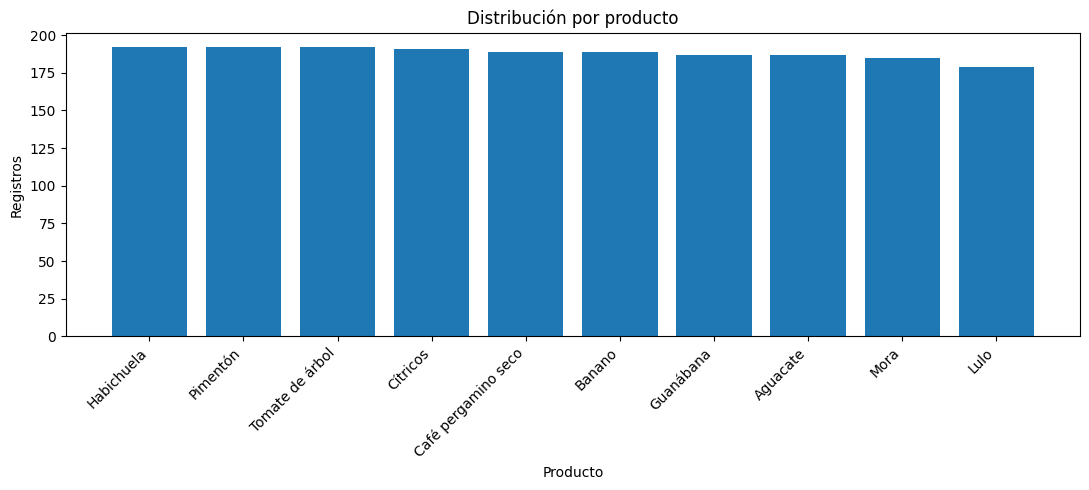

,Registros
producto,
Habichuela,192
Pimentón,192
Tomate de árbol,192
Cítricos,191
Café pergamino seco,189
Banano,189
Guanábana,187
Aguacate,187
Mora,185


In [ ]:

conteo_productos = (
    df_limpio["producto"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 5))
plt.bar(conteo_productos.index, conteo_productos.values)
plt.title("Distribución por producto")
plt.xlabel("Producto")
plt.ylabel("Registros")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(conteo_productos.rename("Registros").to_frame())


## 18.2 Productores vs compradores

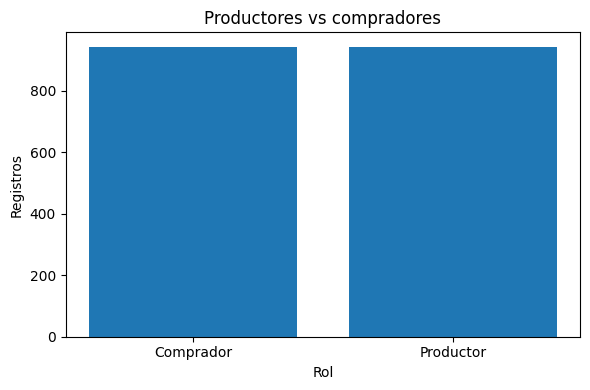

,Registros
rol,
Comprador,942
Productor,941


In [ ]:

conteo_roles = df_limpio["rol"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(conteo_roles.index, conteo_roles.values)
plt.title("Productores vs compradores")
plt.xlabel("Rol")
plt.ylabel("Registros")
plt.tight_layout()
plt.show()

display(conteo_roles.rename("Registros").to_frame())



## 18.3 Distribución de precios por producto

El boxplot permite observar mediana, dispersión y posibles valores atípicos.


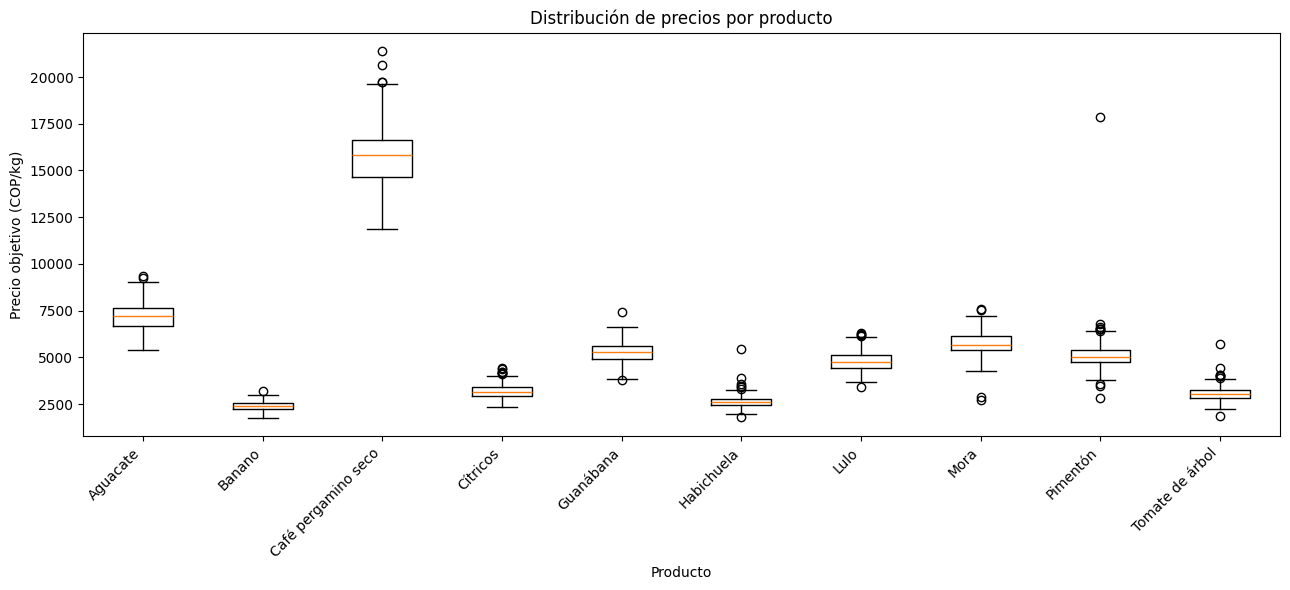

In [ ]:

productos_ordenados = sorted(df_limpio["producto"].unique())

datos_boxplot = [
    df_limpio.loc[
        df_limpio["producto"] == producto,
        "precio_objetivo_cop_kg"
    ].values
    for producto in productos_ordenados
]

plt.figure(figsize=(13, 6))
plt.boxplot(datos_boxplot, tick_labels=productos_ordenados)
plt.title("Distribución de precios por producto")
plt.xlabel("Producto")
plt.ylabel("Precio objetivo (COP/kg)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 18.4 Distribución de cantidades

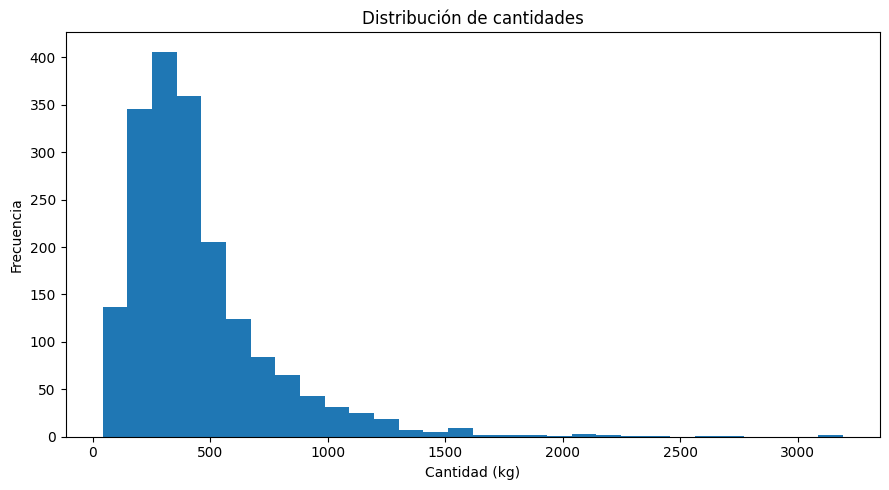

In [ ]:

plt.figure(figsize=(9, 5))
plt.hist(df_limpio["cantidad_kg"], bins=30)
plt.title("Distribución de cantidades")
plt.xlabel("Cantidad (kg)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


## 18.5 Distribución por zona

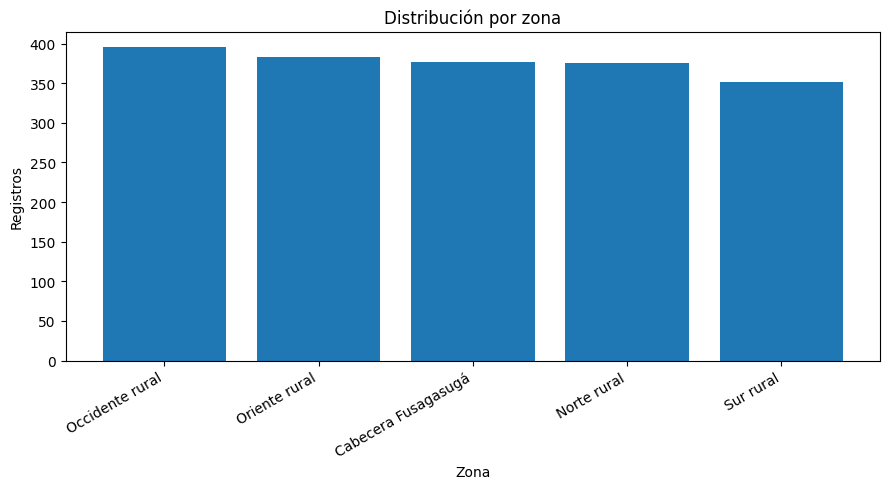

,Registros
zona,
Occidente rural,395
Oriente rural,383
Cabecera Fusagasugá,377
Norte rural,376
Sur rural,352


In [ ]:

conteo_zonas = df_limpio["zona"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(conteo_zonas.index, conteo_zonas.values)
plt.title("Distribución por zona")
plt.xlabel("Zona")
plt.ylabel("Registros")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(conteo_zonas.rename("Registros").to_frame())



## 18.6 Correlaciones numéricas

Se analizan precio, cantidad, distancia, vida útil y plazo. La correlación muestra asociación lineal, no causalidad.


,precio_objetivo_cop_kg,cantidad_kg,distancia_referencia_km,vida_util_restante_dias,plazo_maximo_compra_dias
precio_objetivo_cop_kg,1.000,0.010,0.043,0.614,-0.009
cantidad_kg,0.010,1.000,0.017,0.059,-0.089
distancia_referencia_km,0.043,0.017,1.000,0.033,0.007
vida_util_restante_dias,0.614,0.059,0.033,1.000,-0.232
plazo_maximo_compra_dias,-0.009,-0.089,0.007,-0.232,1.000


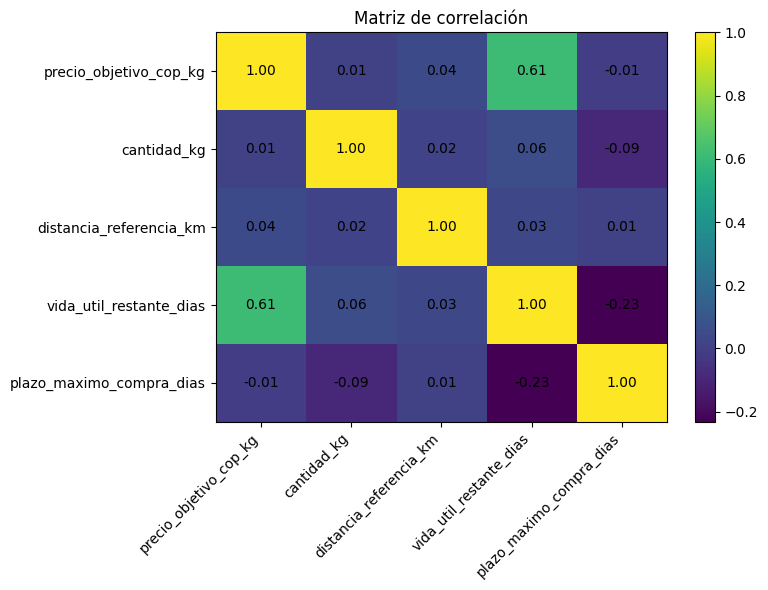

In [ ]:

columnas_correlacion = [
    "precio_objetivo_cop_kg",
    "cantidad_kg",
    "distancia_referencia_km",
    "vida_util_restante_dias",
    "plazo_maximo_compra_dias"
]

corr = df_limpio[columnas_correlacion].corr()

display(corr.round(3))

plt.figure(figsize=(8, 6))
imagen = plt.imshow(corr.values, aspect="auto")
plt.colorbar(imagen)

plt.xticks(
    range(len(columnas_correlacion)),
    columnas_correlacion,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(columnas_correlacion)),
    columnas_correlacion
)

for i in range(len(columnas_correlacion)):
    for j in range(len(columnas_correlacion)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()



# 19. Descargar la base limpia

Puedes escribir el nombre que quieras para el archivo. Si no agregas `.csv`, el cuadernillo lo añade automáticamente.

La variable `df_limpio` permanece en memoria y será la fuente de la Parte II.


In [ ]:
# ============================================================
# 19. DESCARGAR LA BASE LIMPIA
# ============================================================
# PROPÓSITO:
# Guardar el resultado de la limpieza como un archivo independiente.
# Este archivo será la ÚNICA entrada permitida para el entrenamiento
# de la Semana 5.
#
# Se conservan exactamente las 15 columnas originales del CSV v3.
# Las columnas auxiliares utilizadas para auditoría NO se exportan.
# ============================================================

nombre_salida = input(
    "Escribe el nombre que quieres darle a la base limpia: "
).strip()

if nombre_salida == "":
    nombre_salida = "AgroConecta_Semana4_Dataset_Limpio_v3"

nombre_salida = re.sub(
    r'[\\/:*?"<>|]+',
    "_",
    nombre_salida
)

if not nombre_salida.lower().endswith(".csv"):
    nombre_salida += ".csv"

COLUMNAS_BASE_V3 = [
    "id_registro",
    "rol",
    "producto",
    "zona",
    "cantidad_kg",
    "precio_objetivo_cop_kg",
    "fecha_registro",
    "fecha_disponibilidad_o_necesidad",
    "transporte_disponible",
    "dias_desde_cosecha",
    "vida_util_restante_dias",
    "plazo_maximo_compra_dias",
    "tipo_comprador",
    "frecuencia_compra",
    "activo"
]

faltantes_exportacion = [
    c for c in COLUMNAS_BASE_V3
    if c not in df_limpio.columns
]

if faltantes_exportacion:
    raise ValueError(
        "No se puede exportar porque faltan columnas del esquema v3: "
        + str(faltantes_exportacion)
    )

df_exportar = df_limpio[COLUMNAS_BASE_V3].copy()

df_exportar.to_csv(
    nombre_salida,
    index=False,
    encoding="utf-8-sig"
)

print("=" * 70)
print("CSV LIMPIO GENERADO CORRECTAMENTE")
print("=" * 70)
print("Archivo:", nombre_salida)
print("Registros:", len(df_exportar))
print("Columnas:", len(df_exportar.columns))
print("Nulos totales:", int(df_exportar.isna().sum().sum()))
print("\nIMPORTANTE:")
print("Descarga este archivo y consérvalo.")
print("La Semana 5 te pedirá VOLVER A CARGARLO MANUALMENTE.")

from google.colab import files
files.download(nombre_salida)

Escribe el nombre que quieres darle a la base limpia: 25 septiembre
CSV LIMPIO GENERADO CORRECTAMENTE
Archivo: 25 septiembre.csv
Registros: 1883
Columnas: 15
Nulos totales: 0

IMPORTANTE:
Descarga este archivo y consérvalo.
La Semana 5 te pedirá VOLVER A CARGARLO MANUALMENTE.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# 20. Resultado final de la Semana 4

> **“Partimos de una base sin procesar, identificamos valores faltantes, duplicados, inconsistencias categóricas y valores atípicos. Después aplicamos técnicas de limpieza y preprocesamiento y obtuvimos una base preparada para construir oportunidades comerciales y entrenar la red neuronal.”**

Esto evidencia:

> **Limpia, organiza y analiza datos.**



# Cierre de la Semana 4

Al terminar el cuadernillo debemos poder afirmar:

> **“Partimos de una base sin procesar, identificamos valores faltantes, duplicados, inconsistencias categóricas y valores atípicos. Después aplicamos técnicas de limpieza y preprocesamiento y obtuvimos una base preparada para construir oportunidades comerciales y entrenar la red neuronal.”**

### Archivo necesario para continuar

Descarga el CSV limpio con el nombre que prefieras. Ese archivo será la entrada del cuadernillo de la **Semana 5**.


---
# PARTE II — SEMANA 5
# Nueva carga del CSV limpio y entrenamiento del modelo

## Regla principal de esta etapa

Aunque `df_limpio` todavía pueda existir en la memoria de Colab, **no se utilizará para entrenar**.

Debes:

1. ejecutar la descarga de la Semana 4;
2. ubicar el CSV limpio en tu computador;
3. ejecutar la siguiente celda;
4. **subir nuevamente el archivo limpio**;
5. dejar que el cuadernillo lo valide antes de continuar.

Esto crea una frontera clara entre **preparación de datos** y **entrenamiento**.

In [ ]:
# ============================================================
# 21. IMPORTACIONES PARA ENTRENAMIENTO Y EVALUACIÓN
# ============================================================
# Estas librerías se utilizan desde esta etapa en adelante.
# No generan ni limpian datos: trabajan únicamente con el CSV
# limpio que se volverá a cargar en la siguiente celda.
# ============================================================

import os
import re
import json
import joblib
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style="whitegrid")

print("TensorFlow:", tf.__version__)
print("Entorno de entrenamiento listo.")

TensorFlow: 2.20.0
Entorno de entrenamiento listo.


## 22. Volver a cargar manualmente el CSV limpio

Esta es una parte **obligatoria** del flujo.

La celda no toma `df_limpio`. Abre nuevamente el selector de archivos de Google Colab y crea un DataFrame nuevo llamado `df_entrenamiento`.

Además realiza una auditoría corta para evitar que el usuario cargue por error el CSV sucio.

In [ ]:
# ============================================================
# 22. CARGAR NUEVAMENTE EL CSV LIMPIO
# ============================================================
# IMPORTANTE:
# - No usamos df_limpio.
# - Debes seleccionar el archivo descargado al final de Semana 4.
# - Se valida el esquema y la calidad mínima antes de entrenar.
# ============================================================

from google.colab import files

print("=" * 72)
print("SEMANA 5 — CARGA INDEPENDIENTE DEL CSV LIMPIO")
print("=" * 72)
print("Selecciona el CSV LIMPIO descargado en la Semana 4.")

archivos_limpios = files.upload()

nombre_csv_limpio = next(
    (
        nombre for nombre in archivos_limpios.keys()
        if nombre.lower().endswith(".csv")
    ),
    None
)

if nombre_csv_limpio is None:
    raise ValueError("Debes cargar un archivo CSV limpio.")

df_entrenamiento = pd.read_csv(
    nombre_csv_limpio,
    encoding="utf-8-sig"
)

COLUMNAS_BASE_V3 = [
    "id_registro",
    "rol",
    "producto",
    "zona",
    "cantidad_kg",
    "precio_objetivo_cop_kg",
    "fecha_registro",
    "fecha_disponibilidad_o_necesidad",
    "transporte_disponible",
    "dias_desde_cosecha",
    "vida_util_restante_dias",
    "plazo_maximo_compra_dias",
    "tipo_comprador",
    "frecuencia_compra",
    "activo"
]

faltantes = [
    columna for columna in COLUMNAS_BASE_V3
    if columna not in df_entrenamiento.columns
]

if faltantes:
    raise ValueError(
        "El archivo no tiene la estructura v3 esperada. "
        f"Faltan estas columnas: {faltantes}"
    )

# Se conserva únicamente el esquema oficial de 15 columnas.
df_entrenamiento = df_entrenamiento[COLUMNAS_BASE_V3].copy()

print("\nArchivo cargado:", nombre_csv_limpio)
print("Dimensiones:", df_entrenamiento.shape)
display(df_entrenamiento.head())

SEMANA 5 — CARGA INDEPENDIENTE DEL CSV LIMPIO
Selecciona el CSV LIMPIO descargado en la Semana 4.


Saving 25 septiembre.csv to 25 septiembre (1).csv

Archivo cargado: 25 septiembre (1).csv
Dimensiones: (1883, 15)


,id_registro,rol,producto,zona,cantidad_kg,precio_objetivo_cop_kg,fecha_registro,fecha_disponibilidad_o_necesidad,transporte_disponible,dias_desde_cosecha,vida_util_restante_dias,plazo_maximo_compra_dias,tipo_comprador,frecuencia_compra,activo
0,REG0001,Comprador,Habichuela,Occidente rural,619.00,2476.62,2026-08-20 12:14:32,2026-08-27 12:14:32,Sí,0,0,14,Plaza de mercado,Única,1
1,REG0002,Productor,Guanábana,Norte rural,1164.57,5218.72,2026-03-21 23:57:59,2026-03-23 23:57:59,Sí,4,2,0,No aplica,No aplica,1
2,REG0003,Productor,Pimentón,Occidente rural,412.63,4772.29,2026-08-06 14:27:18,2026-08-06 14:27:18,Sí,9,1,0,No aplica,No aplica,1
3,REG0004,Comprador,Mora,Norte rural,227.04,6218.56,2026-04-09 04:32:33,2026-04-10 04:32:33,No,0,0,10,Comerciante,Mensual,1
4,REG0005,Comprador,Habichuela,Sur rural,555.14,3184.25,2026-02-08 05:38:35,2026-02-12 05:38:35,No,0,0,2,Plaza de mercado,Mensual,1


In [ ]:
# ============================================================
# 22.1 VALIDAR QUE REALMENTE SEA EL CSV LIMPIO
# ============================================================
# Esta verificación detecta los problemas más evidentes que tenía
# la base sucia. Si alguno permanece, se detiene el entrenamiento.
# ============================================================

ZONAS_VALIDAS_MODELO = [
    "Cabecera Fusagasugá",
    "Norte rural",
    "Sur rural",
    "Oriente rural",
    "Occidente rural"
]

PRODUCTOS_VALIDOS_MODELO = [
    "Aguacate",
    "Banano",
    "Café pergamino seco",
    "Cítricos",
    "Guanábana",
    "Habichuela",
    "Lulo",
    "Mora",
    "Pimentón",
    "Tomate de árbol"
]

problemas_archivo = {}

problemas_archivo["Nulos"] = int(
    df_entrenamiento.isna().sum().sum()
)

problemas_archivo["Duplicados exactos"] = int(
    df_entrenamiento.duplicated().sum()
)

problemas_archivo["Roles inválidos"] = int(
    (~df_entrenamiento["rol"].isin(["Productor", "Comprador"])).sum()
)

problemas_archivo["Productos inválidos"] = int(
    (~df_entrenamiento["producto"].isin(PRODUCTOS_VALIDOS_MODELO)).sum()
)

problemas_archivo["Zonas inválidas"] = int(
    (~df_entrenamiento["zona"].isin(ZONAS_VALIDAS_MODELO)).sum()
)

problemas_archivo["Transporte inválido"] = int(
    (~df_entrenamiento["transporte_disponible"].isin(["Sí", "No"])).sum()
)

cantidad_revision = pd.to_numeric(
    df_entrenamiento["cantidad_kg"],
    errors="coerce"
)

precio_revision = pd.to_numeric(
    df_entrenamiento["precio_objetivo_cop_kg"],
    errors="coerce"
)

problemas_archivo["Cantidades inválidas"] = int(
    ((cantidad_revision <= 0) | (cantidad_revision > 5000)).sum()
)

problemas_archivo["Precios inválidos"] = int(
    ((precio_revision <= 0) | (precio_revision > 100000)).sum()
)

tabla_validacion = pd.DataFrame({
    "Control": list(problemas_archivo.keys()),
    "Problemas encontrados": list(problemas_archivo.values())
})

display(tabla_validacion)

if any(valor > 0 for valor in problemas_archivo.values()):
    raise ValueError(
        "El archivo cargado no supera la validación de limpieza. "
        "Es posible que hayas vuelto a cargar el CSV SUCIO. "
        "Regresa a la Semana 4, genera el CSV limpio y vuelve a cargarlo."
    )

# Conversión final de tipos para entrenamiento.
df_entrenamiento["cantidad_kg"] = pd.to_numeric(
    df_entrenamiento["cantidad_kg"]
)
df_entrenamiento["precio_objetivo_cop_kg"] = pd.to_numeric(
    df_entrenamiento["precio_objetivo_cop_kg"]
)
df_entrenamiento["fecha_registro"] = pd.to_datetime(
    df_entrenamiento["fecha_registro"],
    errors="raise"
)
df_entrenamiento["fecha_disponibilidad_o_necesidad"] = pd.to_datetime(
    df_entrenamiento["fecha_disponibilidad_o_necesidad"],
    errors="raise"
)

print("✓ El CSV cargado supera la validación.")
print("✓ Esta será la fuente independiente del entrenamiento.")

,Control,Problemas encontrados
0,Nulos,0
1,Duplicados exactos,0
2,Roles inválidos,0
3,Productos inválidos,0
4,Zonas inválidas,0
5,Transporte inválido,0
6,Cantidades inválidas,0
7,Precios inválidos,0


✓ El CSV cargado supera la validación.
✓ Esta será la fuente independiente del entrenamiento.


## 23. Separar productores y compradores

Una oportunidad comercial no es un registro individual. Se forma al comparar:

- una **oferta** registrada por un productor;
- una **demanda** registrada por un comprador.

Por eso el entrenamiento trabaja sobre pares Productor–Comprador.

In [ ]:
# ============================================================
# 23. SEPARAR LOS DOS ROLES
# ============================================================

productores = (
    df_entrenamiento[
        (df_entrenamiento["rol"] == "Productor") &
        (df_entrenamiento["activo"] == 1)
    ]
    .copy()
    .reset_index(drop=True)
)

compradores = (
    df_entrenamiento[
        (df_entrenamiento["rol"] == "Comprador") &
        (df_entrenamiento["activo"] == 1)
    ]
    .copy()
    .reset_index(drop=True)
)

print("Productores activos:", len(productores))
print("Compradores activos:", len(compradores))

if len(productores) == 0 or len(compradores) == 0:
    raise ValueError(
        "Se necesitan productores y compradores activos para construir oportunidades."
    )

print("\nProductos ofrecidos:")
display(productores["producto"].value_counts().to_frame("Productores"))

print("\nProductos demandados:")
display(compradores["producto"].value_counts().to_frame("Compradores"))

Productores activos: 941
Compradores activos: 942

Productos ofrecidos:


,Productores
producto,
Tomate de árbol,96
Guanábana,95
Mora,95
Habichuela,95
Cítricos,95
Café pergamino seco,94
Banano,94
Pimentón,93
Aguacate,93



Productos demandados:


,Compradores
producto,
Pimentón,99
Habichuela,97
Cítricos,96
Tomate de árbol,96
Café pergamino seco,95
Banano,95
Aguacate,94
Guanábana,92
Mora,90


## 24. Distancia territorial didáctica entre zonas

El CSV v3 registra **zonas**, no coordenadas GPS. Por eso no es correcto inventar una distancia exacta para cada persona.

En su lugar se utiliza una matriz de referencia para el experimento:

- misma zona rural: distancia corta de referencia;
- cabecera frente a zonas rurales: distancia intermedia;
- extremos rurales: distancia mayor.

### Límites logísticos usados por el recomendador

- **Ninguno tiene transporte:** máximo 12 km de referencia.
- **Solo una de las partes tiene transporte:** máximo 22 km.
- **Ambos tienen transporte:** máximo 35 km.

Estos valores son **didácticos** y deberán reemplazarse por rutas reales/Mapas/GPS si el proyecto pasa a una fase operativa.

In [ ]:
# ============================================================
# 24. MATRIZ DE DISTANCIA TERRITORIAL DE REFERENCIA
# ============================================================
# La matriz es simétrica: distancia(A, B) = distancia(B, A).
# Los valores NO son distancias GPS reales.
# ============================================================

DISTANCIA_ZONAS_KM = {
    ("Cabecera Fusagasugá", "Cabecera Fusagasugá"): 2.0,
    ("Norte rural", "Norte rural"): 5.0,
    ("Sur rural", "Sur rural"): 5.0,
    ("Oriente rural", "Oriente rural"): 5.0,
    ("Occidente rural", "Occidente rural"): 5.0,

    ("Cabecera Fusagasugá", "Norte rural"): 12.0,
    ("Cabecera Fusagasugá", "Sur rural"): 14.0,
    ("Cabecera Fusagasugá", "Oriente rural"): 16.0,
    ("Cabecera Fusagasugá", "Occidente rural"): 15.0,

    ("Norte rural", "Sur rural"): 26.0,
    ("Norte rural", "Oriente rural"): 18.0,
    ("Norte rural", "Occidente rural"): 20.0,

    ("Sur rural", "Oriente rural"): 21.0,
    ("Sur rural", "Occidente rural"): 18.0,

    ("Oriente rural", "Occidente rural"): 23.0
}

# Completar automáticamente la dirección inversa.
for (zona_a, zona_b), distancia in list(DISTANCIA_ZONAS_KM.items()):
    DISTANCIA_ZONAS_KM[(zona_b, zona_a)] = distancia

def distancia_entre_zonas(zona_a, zona_b):
    """Devuelve la distancia territorial didáctica entre dos zonas."""
    return float(
        DISTANCIA_ZONAS_KM.get(
            (zona_a, zona_b),
            35.0
        )
    )

def limite_logistico(transporte_a, transporte_b):
    """
    Establece la distancia máxima recomendada según disponibilidad
    de transporte de las dos partes.
    """
    a = transporte_a == "Sí"
    b = transporte_b == "Sí"

    if a and b:
        return 35.0
    if a or b:
        return 22.0
    return 12.0

# Mostrar la matriz como tabla.
matriz_distancias = pd.DataFrame(
    [
        [
            distancia_entre_zonas(fila, columna)
            for columna in ZONAS_VALIDAS_MODELO
        ]
        for fila in ZONAS_VALIDAS_MODELO
    ],
    index=ZONAS_VALIDAS_MODELO,
    columns=ZONAS_VALIDAS_MODELO
)

display(matriz_distancias)

,Cabecera Fusagasugá,Norte rural,Sur rural,Oriente rural,Occidente rural
Cabecera Fusagasugá,2.0,12.0,14.0,16.0,15.0
Norte rural,12.0,5.0,26.0,18.0,20.0
Sur rural,14.0,26.0,5.0,21.0,18.0
Oriente rural,16.0,18.0,21.0,5.0,23.0
Occidente rural,15.0,20.0,18.0,23.0,5.0


## 25. Construcción de oportunidades Productor–Comprador

Para que la red neuronal observe suficientes ejemplos útiles, se generan dos grupos:

1. **pares con el mismo producto**, que representan candidatos comercialmente plausibles;
2. **pares aleatorios**, que incluyen coincidencias y no coincidencias.

Esto evita entrenar con una base dominada casi por completo por pares imposibles.

In [ ]:
# ============================================================
# 25. GENERAR PARES PARA ENTRENAMIENTO
# ============================================================
# Se generan 6.000 pares como máximo:
# - 50 % buscando explícitamente el mismo producto;
# - 50 % mediante combinación aleatoria.
#
# Después se calculan variables derivadas que describen la
# compatibilidad comercial de cada par.
# ============================================================

rng = np.random.default_rng(SEED)
N_PARES = 6000
N_COINCIDENTES = N_PARES // 2
N_ALEATORIOS = N_PARES - N_COINCIDENTES

productos_comunes = sorted(
    set(productores["producto"])
    .intersection(set(compradores["producto"]))
)

if not productos_comunes:
    raise ValueError(
        "No existen productos comunes entre productores y compradores."
    )

lista_productores = []
lista_compradores = []

# ------------------------------------------------------------
# A. Pares que comparten producto
# ------------------------------------------------------------
for _ in range(N_COINCIDENTES):
    producto = rng.choice(productos_comunes)

    p_pool = productores[
        productores["producto"] == producto
    ]

    c_pool = compradores[
        compradores["producto"] == producto
    ]

    productor = p_pool.iloc[
        rng.integers(0, len(p_pool))
    ]

    comprador = c_pool.iloc[
        rng.integers(0, len(c_pool))
    ]

    lista_productores.append(productor)
    lista_compradores.append(comprador)

# ------------------------------------------------------------
# B. Pares aleatorios
# ------------------------------------------------------------
for _ in range(N_ALEATORIOS):
    productor = productores.iloc[
        rng.integers(0, len(productores))
    ]

    comprador = compradores.iloc[
        rng.integers(0, len(compradores))
    ]

    lista_productores.append(productor)
    lista_compradores.append(comprador)

prod_pares = pd.DataFrame(lista_productores).reset_index(drop=True)
comp_pares = pd.DataFrame(lista_compradores).reset_index(drop=True)

pares = pd.DataFrame({
    "id_productor": prod_pares["id_registro"].values,
    "id_comprador": comp_pares["id_registro"].values,
    "producto_productor": prod_pares["producto"].values,
    "producto_comprador": comp_pares["producto"].values,
    "zona_productor": prod_pares["zona"].values,
    "zona_comprador": comp_pares["zona"].values,
    "cantidad_ofrecida_kg": prod_pares["cantidad_kg"].values,
    "cantidad_solicitada_kg": comp_pares["cantidad_kg"].values,
    "precio_productor": prod_pares["precio_objetivo_cop_kg"].values,
    "presupuesto_comprador": comp_pares["precio_objetivo_cop_kg"].values,
    "transporte_productor": prod_pares["transporte_disponible"].values,
    "transporte_comprador": comp_pares["transporte_disponible"].values,
    "dias_desde_cosecha": prod_pares["dias_desde_cosecha"].values,
    "vida_util_restante_dias": prod_pares["vida_util_restante_dias"].values,
    "plazo_maximo_compra_dias": comp_pares["plazo_maximo_compra_dias"].values,
    "tipo_comprador": comp_pares["tipo_comprador"].values,
    "frecuencia_compra": comp_pares["frecuencia_compra"].values,
    "fecha_productor": prod_pares["fecha_disponibilidad_o_necesidad"].values,
    "fecha_comprador": comp_pares["fecha_disponibilidad_o_necesidad"].values
})

# ------------------------------------------------------------
# Variables derivadas
# ------------------------------------------------------------

pares["mismo_producto"] = (
    pares["producto_productor"] ==
    pares["producto_comprador"]
).astype(int)

pares["compatibilidad_cantidad"] = (
    np.minimum(
        pares["cantidad_ofrecida_kg"],
        pares["cantidad_solicitada_kg"]
    )
    /
    np.maximum(
        pares["cantidad_ofrecida_kg"],
        pares["cantidad_solicitada_kg"]
    )
).clip(0, 1)

pares["brecha_precio_relativa"] = (
    np.abs(
        pares["precio_productor"] -
        pares["presupuesto_comprador"]
    )
    /
    pares["presupuesto_comprador"].clip(lower=1)
).clip(0, 10)

pares["distancia_estimada"] = [
    distancia_entre_zonas(zp, zc)
    for zp, zc in zip(
        pares["zona_productor"],
        pares["zona_comprador"]
    )
]

pares["limite_logistico_km"] = [
    limite_logistico(tp, tc)
    for tp, tc in zip(
        pares["transporte_productor"],
        pares["transporte_comprador"]
    )
]

pares["transporte_compatible"] = (
    pares["distancia_estimada"] <=
    pares["limite_logistico_km"]
).astype(int)

pares["urgencia_compatible"] = (
    pares["vida_util_restante_dias"] >=
    pares["plazo_maximo_compra_dias"]
).astype(int)

fecha_p = pd.to_datetime(
    pares["fecha_productor"],
    errors="coerce"
)

fecha_c = pd.to_datetime(
    pares["fecha_comprador"],
    errors="coerce"
)

pares["diferencia_dias"] = (
    (fecha_p - fecha_c)
    .abs()
    .dt.days
    .fillna(30)
    .clip(0, 365)
)

pares["misma_temporalidad"] = (
    pares["diferencia_dias"] <= 14
).astype(int)

pares["compatibilidad_distancia"] = (
    1 -
    (
        pares["distancia_estimada"] /
        pares["limite_logistico_km"].clip(lower=1)
    )
).clip(0, 1)

print("Pares generados:", len(pares))
print(
    "Pares con mismo producto:",
    int(pares["mismo_producto"].sum())
)
display(pares.head())

Pares generados: 6000
Pares con mismo producto: 3329


,id_productor,id_comprador,producto_productor,producto_comprador,zona_productor,zona_comprador,cantidad_ofrecida_kg,cantidad_solicitada_kg,precio_productor,presupuesto_comprador,...,mismo_producto,compatibilidad_cantidad,brecha_precio_relativa,distancia_estimada,limite_logistico_km,transporte_compatible,urgencia_compatible,diferencia_dias,misma_temporalidad,compatibilidad_distancia
0,REG1587,REG1310,Aguacate,Aguacate,Oriente rural,Norte rural,591.670,775.56,7012.63,8157.620,...,1,0.762894,0.140358,18.0,22.0,1,1,25,0,0.181818
1,REG0885,REG1721,Guanábana,Guanábana,Norte rural,Occidente rural,186.120,670.19,4656.66,6149.270,...,1,0.277712,0.242730,20.0,22.0,1,0,2,1,0.090909
2,REG1487,REG0413,Aguacate,Aguacate,Occidente rural,Sur rural,381.900,255.95,7694.16,7374.150,...,1,0.670202,0.043396,18.0,22.0,1,0,39,0,0.181818
3,REG1114,REG1948,Aguacate,Aguacate,Cabecera Fusagasugá,Cabecera Fusagasugá,423.565,548.05,7246.90,6848.500,...,1,0.772858,0.058173,2.0,12.0,1,1,1,1,0.833333
4,REG1484,REG1383,Mora,Mora,Norte rural,Sur rural,133.650,767.14,4550.66,5647.305,...,1,0.174219,0.194189,26.0,22.0,0,0,60,0,0.000000


## 26. Etiqueta sintética didáctica

El CSV no contiene una columna que indique si una oportunidad terminó en venta real. Para poder entrenar un clasificador supervisado se construye una etiqueta sintética.

La regla pondera:

- coincidencia del producto;
- compatibilidad de cantidad;
- cercanía entre precio ofertado y presupuesto;
- distancia territorial;
- viabilidad de transporte;
- vida útil frente al plazo;
- cercanía temporal.

El modelo aprende a aproximar esta regla. **No debe interpretarse todavía como una probabilidad real de venta.**

,Cantidad
Etiqueta,
0,3102
1,2898


Proporción de oportunidades positivas: 48.30%


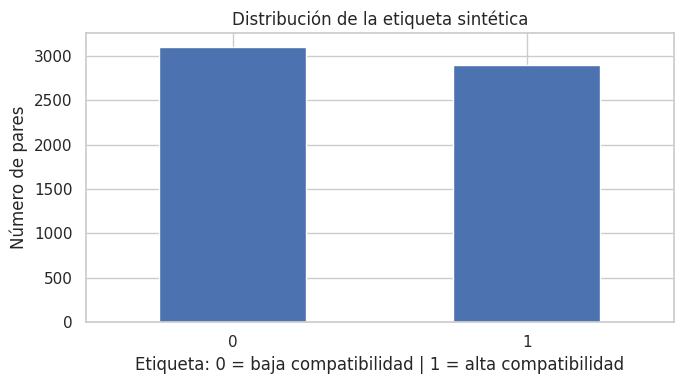

In [ ]:
# ============================================================
# 26. CONSTRUIR SCORE Y ETIQUETA SINTÉTICA
# ============================================================

pares["score_regla"] = (
    0.30 * pares["mismo_producto"] +
    0.15 * pares["compatibilidad_cantidad"] +
    0.20 * (1 / (1 + pares["brecha_precio_relativa"])) +
    0.10 * pares["compatibilidad_distancia"] +
    0.10 * pares["transporte_compatible"] +
    0.10 * pares["urgencia_compatible"] +
    0.05 * pares["misma_temporalidad"]
)

UMBRAL_ETIQUETA = 0.62

pares["etiqueta"] = (
    pares["score_regla"] >= UMBRAL_ETIQUETA
).astype(int)

distribucion_etiqueta = (
    pares["etiqueta"]
    .value_counts()
    .sort_index()
    .rename_axis("Etiqueta")
    .to_frame("Cantidad")
)

display(distribucion_etiqueta)

proporcion_positiva = pares["etiqueta"].mean()

print(
    "Proporción de oportunidades positivas:",
    f"{proporcion_positiva * 100:.2f}%"
)

if pares["etiqueta"].nunique() < 2:
    raise ValueError(
        "La etiqueta solo contiene una clase. "
        "No es posible entrenar un clasificador."
    )

# Gráfica de distribución de la etiqueta.
plt.figure(figsize=(7, 4))
pares["etiqueta"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de la etiqueta sintética")
plt.xlabel("Etiqueta: 0 = baja compatibilidad | 1 = alta compatibilidad")
plt.ylabel("Número de pares")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 27. Variables que entran al MLP

El modelo recibe una representación de cada oportunidad, no los IDs de las personas.

### Variables categóricas
- producto del productor;
- producto del comprador;
- zona del productor;
- zona del comprador;
- tipo de comprador;
- frecuencia de compra.

### Variables numéricas
- cantidades;
- precios;
- compatibilidad de cantidad;
- brecha de precio;
- viabilidad del transporte;
- vida útil;
- plazo;
- distancia;
- compatibilidad de distancia;
- temporalidad.

El preprocesador se ajusta **solo con el conjunto de entrenamiento** para evitar fuga de información.

In [ ]:
# ============================================================
# 27. PREPARAR VARIABLES DEL MODELO
# ============================================================

features = [
    "producto_productor",
    "producto_comprador",
    "zona_productor",
    "zona_comprador",
    "tipo_comprador",
    "frecuencia_compra",
    "cantidad_ofrecida_kg",
    "cantidad_solicitada_kg",
    "precio_productor",
    "presupuesto_comprador",
    "compatibilidad_cantidad",
    "brecha_precio_relativa",
    "transporte_compatible",
    "vida_util_restante_dias",
    "plazo_maximo_compra_dias",
    "distancia_estimada",
    "compatibilidad_distancia",
    "misma_temporalidad"
]

X = pares[features].copy()
y = pares["etiqueta"].astype(int).copy()

categoricas_modelo = [
    "producto_productor",
    "producto_comprador",
    "zona_productor",
    "zona_comprador",
    "tipo_comprador",
    "frecuencia_compra"
]

numericas_modelo = [
    "cantidad_ofrecida_kg",
    "cantidad_solicitada_kg",
    "precio_productor",
    "presupuesto_comprador",
    "compatibilidad_cantidad",
    "brecha_precio_relativa",
    "transporte_compatible",
    "vida_util_restante_dias",
    "plazo_maximo_compra_dias",
    "distancia_estimada",
    "compatibilidad_distancia",
    "misma_temporalidad"
]

def crear_preprocesador():
    """
    Escala las variables numéricas y aplica One-Hot Encoding
    a las variables categóricas.
    """
    try:
        encoder = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    except TypeError:
        encoder = OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )

    return ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                numericas_modelo
            ),
            (
                "cat",
                encoder,
                categoricas_modelo
            )
        ],
        remainder="drop"
    )

print("X:", X.shape)
print("y:", y.shape)
print("Variables preparadas.")

X: (6000, 18)
y: (6000,)
Variables preparadas.


# MODELO 1 — Base
## División 70 % entrenamiento / 15 % validación / 15 % prueba
## Dropout = 0,20

Esta configuración se conserva como referencia experimental.

In [ ]:
# ============================================================
# 28. SPLIT 70 / 15 / 15
# ============================================================

X_train70, X_temp70, y_train70, y_temp70 = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

X_val70, X_test70, y_val70, y_test70 = train_test_split(
    X_temp70,
    y_temp70,
    test_size=0.50,
    stratify=y_temp70,
    random_state=SEED
)

prep70 = crear_preprocesador()

X_train70_p = prep70.fit_transform(X_train70)
X_val70_p = prep70.transform(X_val70)
X_test70_p = prep70.transform(X_test70)

print("Entrenamiento:", X_train70_p.shape)
print("Validación:", X_val70_p.shape)
print("Prueba:", X_test70_p.shape)

Entrenamiento: (4200, 51)
Validación: (900, 51)
Prueba: (900, 51)


In [ ]:
# ============================================================
# 29. CONSTRUIR LA ARQUITECTURA MLP
# ============================================================
# Arquitectura:
# entrada -> Dense(32, ReLU) -> Dropout ->
# Dense(16, ReLU) -> Dropout -> Dense(1, Sigmoid)
# ============================================================

def construir_mlp(input_dim, dropout):
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.Precision(
                name="precision"
            ),
            tf.keras.metrics.Recall(
                name="recall"
            )
        ]
    )

    return modelo

modelo_base = construir_mlp(
    X_train70_p.shape[1],
    0.20
)

modelo_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,209 (8.63 KB)

 Trainable params: 2,209 (8.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# 30. ENTRENAR MODELO BASE
# ============================================================
# EarlyStopping detiene el entrenamiento si la pérdida de
# validación deja de mejorar durante 8 épocas.
# restore_best_weights=True recupera los mejores pesos.
# ============================================================

early_base = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

hist_base = modelo_base.fit(
    X_train70_p,
    y_train70,
    validation_data=(
        X_val70_p,
        y_val70
    ),
    epochs=60,
    batch_size=32,
    callbacks=[early_base],
    verbose=1
)

Epoch 1/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.6062 - loss: 0.6555 - precision: 0.5846 - recall: 0.6387 - val_accuracy: 0.7211 - val_loss: 0.5807 - val_precision: 0.7054 - val_recall: 0.7264
Epoch 2/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7043 - loss: 0.5606 - precision: 0.6871 - recall: 0.7122 - val_accuracy: 0.7856 - val_loss: 0.4863 - val_precision: 0.7531 - val_recall: 0.8276
Epoch 3/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7764 - loss: 0.4772 - precision: 0.7514 - recall: 0.8029 - val_accuracy: 0.8267 - val_loss: 0.4080 - val_precision: 0.7888 - val_recall: 0.8759
Epoch 4/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8090 - loss: 0.4194 - precision: 0.7842 - recall: 0.8344 - val_accuracy: 0.8500 - val_loss: 0.3603 - val_precision: 0.8112 - val_recall: 0.8989
Epoch 5/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8245 - loss: 0.3814 - precision: 0.7996 - recall: 0.8497 - val_accuracy: 0.8644 - val_loss: 0

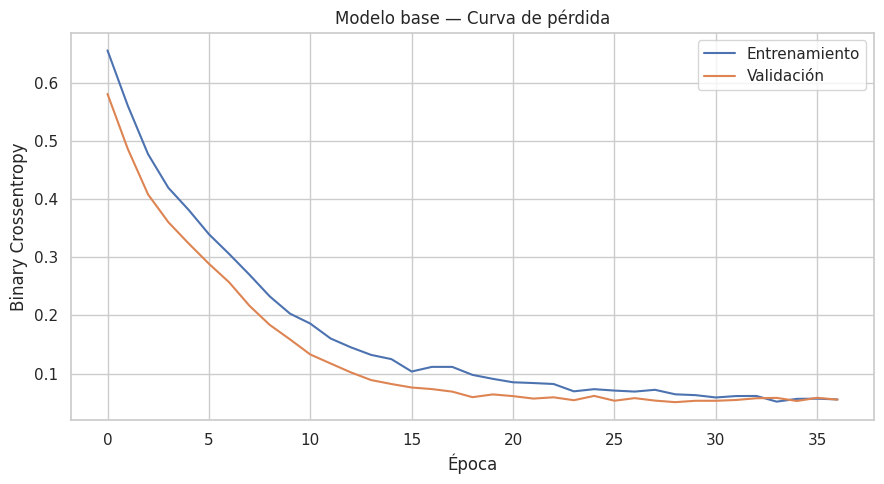

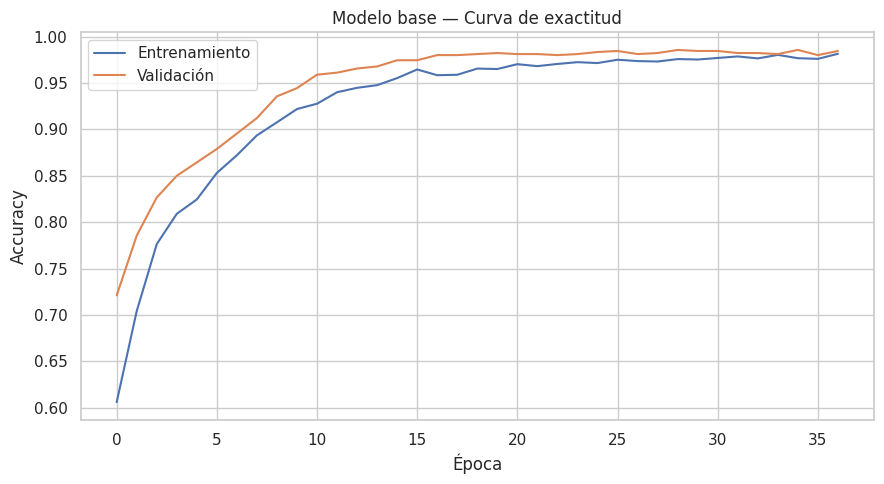

In [ ]:
# ============================================================
# 31. CURVAS DEL MODELO BASE
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    hist_base.history["loss"],
    label="Entrenamiento"
)
ax.plot(
    hist_base.history["val_loss"],
    label="Validación"
)
ax.set_title("Modelo base — Curva de pérdida")
ax.set_xlabel("Época")
ax.set_ylabel("Binary Crossentropy")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    hist_base.history["accuracy"],
    label="Entrenamiento"
)
ax.plot(
    hist_base.history["val_accuracy"],
    label="Validación"
)
ax.set_title("Modelo base — Curva de exactitud")
ax.set_xlabel("Época")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

# MODELO 2 — Optimizado
## División 80 % entrenamiento / 10 % validación / 10 % prueba
## Dropout = 0,30

Se conserva el segundo experimento de la versión 4 para comparar si una mayor proporción de entrenamiento y más regularización mejoran la generalización.

In [ ]:
# ============================================================
# 32. SPLIT 80 / 10 / 10
# ============================================================

X_train80, X_temp80, y_train80, y_temp80 = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

X_val80, X_test80, y_val80, y_test80 = train_test_split(
    X_temp80,
    y_temp80,
    test_size=0.50,
    stratify=y_temp80,
    random_state=SEED
)

prep80 = crear_preprocesador()

X_train80_p = prep80.fit_transform(X_train80)
X_val80_p = prep80.transform(X_val80)
X_test80_p = prep80.transform(X_test80)

print("Entrenamiento:", X_train80_p.shape)
print("Validación:", X_val80_p.shape)
print("Prueba:", X_test80_p.shape)

Entrenamiento: (4800, 51)
Validación: (600, 51)
Prueba: (600, 51)


In [ ]:
# ============================================================
# 33. ENTRENAR MODELO OPTIMIZADO
# ============================================================

modelo_optimizado = construir_mlp(
    X_train80_p.shape[1],
    0.30
)

early_opt = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

hist_opt = modelo_optimizado.fit(
    X_train80_p,
    y_train80,
    validation_data=(
        X_val80_p,
        y_val80
    ),
    epochs=60,
    batch_size=32,
    callbacks=[early_opt],
    verbose=1
)

Epoch 1/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5971 - loss: 0.6559 - precision: 0.5884 - recall: 0.5513 - val_accuracy: 0.7433 - val_loss: 0.5655 - val_precision: 0.7237 - val_recall: 0.7586
Epoch 2/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7125 - loss: 0.5511 - precision: 0.7036 - recall: 0.6993 - val_accuracy: 0.8033 - val_loss: 0.4668 - val_precision: 0.7544 - val_recall: 0.8793
Epoch 3/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7594 - loss: 0.4880 - precision: 0.7408 - recall: 0.7718 - val_accuracy: 0.8200 - val_loss: 0.4007 - val_precision: 0.7692 - val_recall: 0.8966
Epoch 4/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8110 - loss: 0.4208 - precision: 0.7812 - recall: 0.8456 - val_accuracy: 0.8550 - val_loss: 0.3443 - val_precision: 0.8104 - val_recall: 0.9138
Epoch 5/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8342 - loss: 0.3874 - precision: 0.8066 - recall: 0.8637 - val_accuracy: 0.8733 - val_loss: 0.

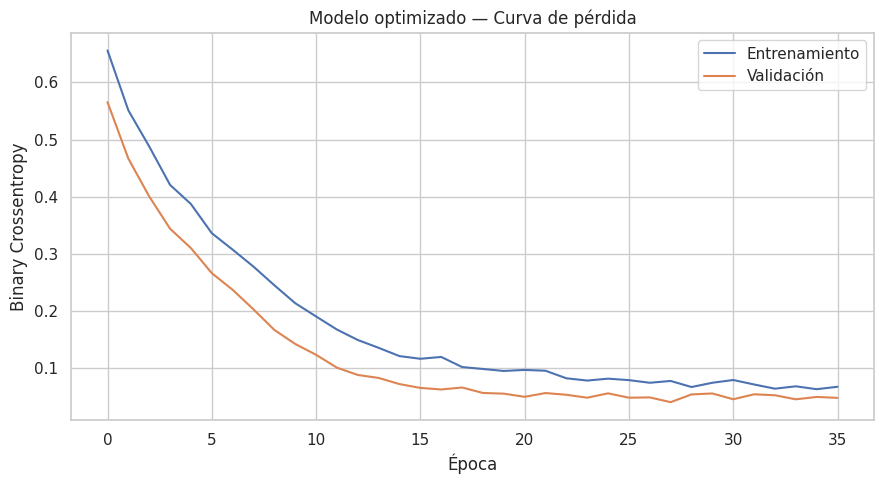

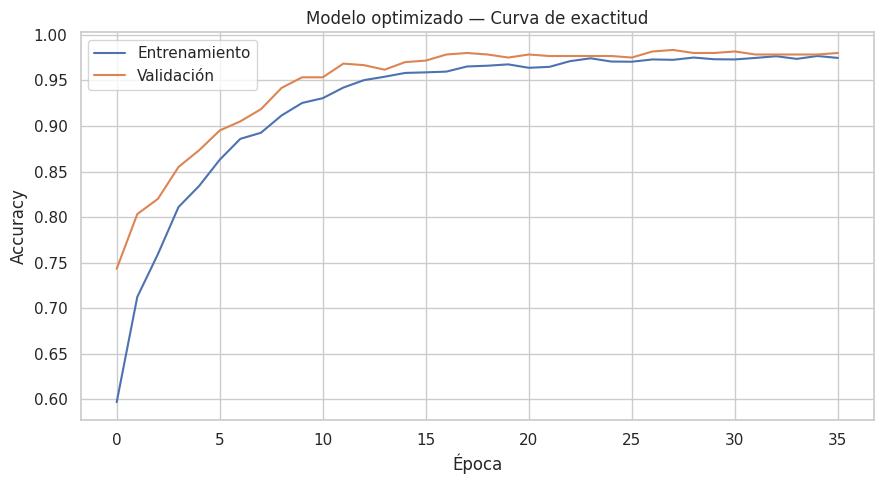

In [ ]:
# ============================================================
# 34. CURVAS DEL MODELO OPTIMIZADO
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    hist_opt.history["loss"],
    label="Entrenamiento"
)
ax.plot(
    hist_opt.history["val_loss"],
    label="Validación"
)
ax.set_title("Modelo optimizado — Curva de pérdida")
ax.set_xlabel("Época")
ax.set_ylabel("Binary Crossentropy")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    hist_opt.history["accuracy"],
    label="Entrenamiento"
)
ax.plot(
    hist_opt.history["val_accuracy"],
    label="Validación"
)
ax.set_title("Modelo optimizado — Curva de exactitud")
ax.set_xlabel("Época")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

---
# PARTE III — SEMANA 6
# Evaluación, comparación y mejora

Esta sección conserva la lógica de evaluación de la versión 4:

- Accuracy;
- Precision;
- Recall;
- F1;
- ROC-AUC;
- PR-AUC;
- matrices de confusión;
- curvas ROC y Precision–Recall;
- comparación entre las dos configuraciones.

Después se añade la capa de interacción solicitada.

In [ ]:
# ============================================================
# 35. FUNCIÓN DE EVALUACIÓN
# ============================================================

def evaluar_modelo(
    modelo,
    X_test_p,
    y_test,
    nombre
):
    prob = modelo.predict(
        X_test_p,
        verbose=0
    ).ravel()

    pred = (
        prob >= 0.50
    ).astype(int)

    metricas = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(
            y_test,
            pred
        ),
        "Precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            prob
        ),
        "PR-AUC": average_precision_score(
            y_test,
            prob
        )
    }

    return metricas, prob, pred

met_base, prob_base, pred_base = evaluar_modelo(
    modelo_base,
    X_test70_p,
    y_test70,
    "Base 70/15/15 — DP 0.20"
)

met_opt, prob_opt, pred_opt = evaluar_modelo(
    modelo_optimizado,
    X_test80_p,
    y_test80,
    "Optimizado 80/10/10 — DP 0.30"
)

tabla_metricas = pd.DataFrame(
    [met_base, met_opt]
)

display(tabla_metricas.round(4))

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Base 70/15/15 — DP 0.20,0.9656,0.9697,0.9585,0.9641,0.9962,0.9961
1,Optimizado 80/10/10 — DP 0.30,0.9800,0.9664,0.9931,0.9796,0.9991,0.9991


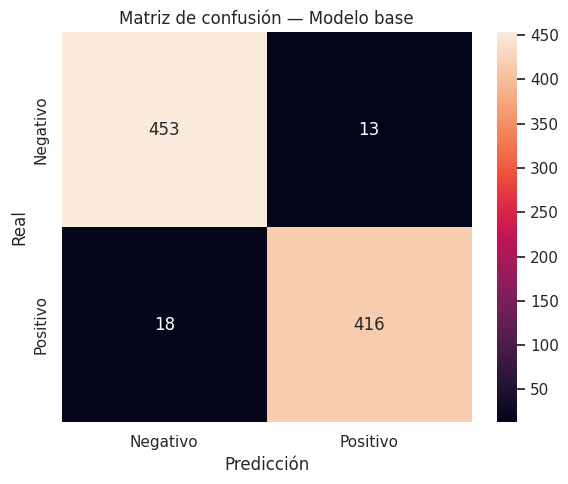

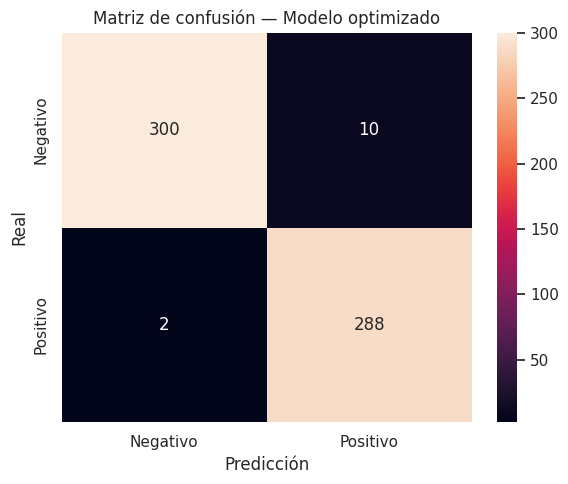

MODELO BASE
TN=453 | FP=13 | FN=18 | TP=416

MODELO OPTIMIZADO
TN=300 | FP=10 | FN=2 | TP=288


In [ ]:
# ============================================================
# 36. MATRICES DE CONFUSIÓN
# ============================================================

cm_base = confusion_matrix(
    y_test70,
    pred_base
)

cm_opt = confusion_matrix(
    y_test80,
    pred_opt
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_base,
    annot=True,
    fmt="d",
    xticklabels=["Negativo", "Positivo"],
    yticklabels=["Negativo", "Positivo"],
    ax=ax
)
ax.set_title("Matriz de confusión — Modelo base")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_opt,
    annot=True,
    fmt="d",
    xticklabels=["Negativo", "Positivo"],
    yticklabels=["Negativo", "Positivo"],
    ax=ax
)
ax.set_title("Matriz de confusión — Modelo optimizado")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

tn_b, fp_b, fn_b, tp_b = cm_base.ravel()
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()

print("MODELO BASE")
print(
    f"TN={tn_b} | FP={fp_b} | FN={fn_b} | TP={tp_b}"
)

print("\nMODELO OPTIMIZADO")
print(
    f"TN={tn_o} | FP={fp_o} | FN={fn_o} | TP={tp_o}"
)

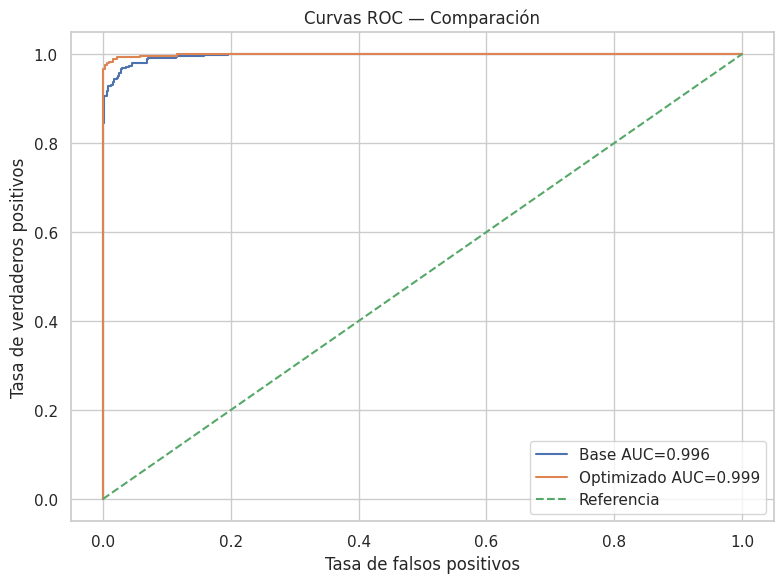

In [ ]:
# ============================================================
# 37. CURVAS ROC
# ============================================================

fpr_b, tpr_b, _ = roc_curve(
    y_test70,
    prob_base
)

fpr_o, tpr_o, _ = roc_curve(
    y_test80,
    prob_opt
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(
    fpr_b,
    tpr_b,
    label=f"Base AUC={met_base['ROC-AUC']:.3f}"
)
ax.plot(
    fpr_o,
    tpr_o,
    label=f"Optimizado AUC={met_opt['ROC-AUC']:.3f}"
)
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Referencia"
)
ax.set_title("Curvas ROC — Comparación")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.legend()
plt.tight_layout()
plt.show()

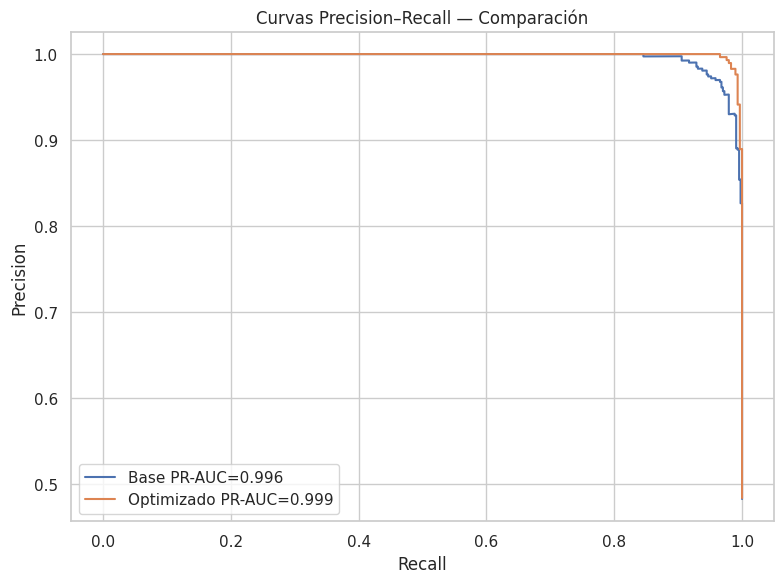

In [ ]:
# ============================================================
# 38. CURVAS PRECISION–RECALL
# ============================================================

precision_b, recall_b, _ = precision_recall_curve(
    y_test70,
    prob_base
)

precision_o, recall_o, _ = precision_recall_curve(
    y_test80,
    prob_opt
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(
    recall_b,
    precision_b,
    label=f"Base PR-AUC={met_base['PR-AUC']:.3f}"
)
ax.plot(
    recall_o,
    precision_o,
    label=f"Optimizado PR-AUC={met_opt['PR-AUC']:.3f}"
)
ax.set_title("Curvas Precision–Recall — Comparación")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()

## 39. Comparación visual de los modelos

La selección no se hace únicamente por Accuracy. El F1 permite observar el equilibrio entre Precision y Recall, mientras que ROC-AUC y PR-AUC ayudan a evaluar la capacidad de separación del modelo.

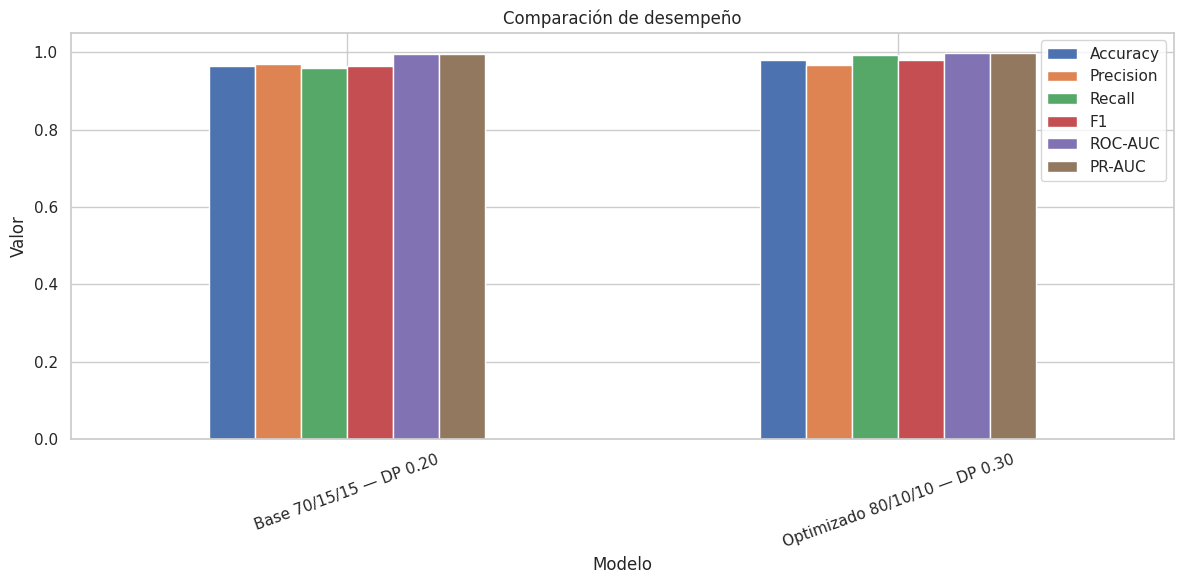

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Modelo,,,,,,
Base 70/15/15 — DP 0.20,0.9656,0.9697,0.9585,0.9641,0.9962,0.9961
Optimizado 80/10/10 — DP 0.30,0.9800,0.9664,0.9931,0.9796,0.9991,0.9991


In [ ]:
# ============================================================
# 39. COMPARACIÓN DE MÉTRICAS
# ============================================================

metricas_graf = (
    tabla_metricas
    .set_index("Modelo")
    [
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "PR-AUC"
        ]
    ]
)

ax = metricas_graf.plot(
    kind="bar",
    figsize=(12, 6)
)
ax.set_title("Comparación de desempeño")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1.05)
ax.tick_params(
    axis="x",
    rotation=20
)
plt.tight_layout()
plt.show()

display(metricas_graf.round(4))

In [ ]:
# ============================================================
# 40. CONCLUSIÓN EXPERIMENTAL
# ============================================================

mejor_f1 = tabla_metricas.loc[
    tabla_metricas["F1"].idxmax(),
    "Modelo"
]

delta_f1 = (
    met_opt["F1"] -
    met_base["F1"]
)

delta_auc = (
    met_opt["ROC-AUC"] -
    met_base["ROC-AUC"]
)

print("Modelo con mayor F1:", mejor_f1)
print(
    f"Diferencia de F1 "
    f"(optimizado - base): {delta_f1:+.4f}"
)
print(
    f"Diferencia de ROC-AUC "
    f"(optimizado - base): {delta_auc:+.4f}"
)

if delta_f1 > 0:
    print(
        "Interpretación: el modelo optimizado "
        "presenta mayor F1 en este experimento."
    )
elif delta_f1 < 0:
    print(
        "Interpretación: el modelo base "
        "presenta mayor F1 en este experimento."
    )
else:
    print(
        "Interpretación: ambos modelos "
        "presentan el mismo F1."
    )

Modelo con mayor F1: Optimizado 80/10/10 — DP 0.30
Diferencia de F1 (optimizado - base): +0.0155
Diferencia de ROC-AUC (optimizado - base): +0.0029
Interpretación: el modelo optimizado presenta mayor F1 en este experimento.


## 41. Seleccionar y guardar el mejor modelo

Se conserva el criterio de la versión 4: elegir la configuración con mayor F1 y guardar conjuntamente el preprocesador que aprendió sus transformaciones.

In [ ]:
# ============================================================
# 41. GUARDAR MODELO FINAL Y PREPROCESADOR
# ============================================================

if met_opt["F1"] >= met_base["F1"]:
    modelo_final = modelo_optimizado
    preprocesador_final = prep80
    nombre_modelo_final = (
        "AgroConecta_MLP_80_10_10_DP030.keras"
    )
else:
    modelo_final = modelo_base
    preprocesador_final = prep70
    nombre_modelo_final = (
        "AgroConecta_MLP_70_15_15_DP020.keras"
    )

modelo_final.save(nombre_modelo_final)

joblib.dump(
    preprocesador_final,
    "AgroConecta_Preprocesador.pkl"
)

print(
    "Modelo seleccionado:",
    nombre_modelo_final
)
print(
    "Preprocesador guardado:",
    "AgroConecta_Preprocesador.pkl"
)

Modelo seleccionado: AgroConecta_MLP_80_10_10_DP030.keras
Preprocesador guardado: AgroConecta_Preprocesador.pkl


---
# 42. INTERACCIÓN CON AGROCONECTA IA

Esta es la parte funcional más importante del prototipo.

El usuario puede escribir frases como:

- **“Soy comprador y necesito comprar 300 kg de mora en Norte rural. Tengo transporte.”**
- **“Quiero comprar 500 kilos de aguacate en la cabecera y no tengo transporte.”**
- **“Soy productor, vendo 700 kg de lulo en Sur rural y cuento con transporte.”**
- **“Tengo para vender 250 kilos de tomate de árbol en Oriente rural.”**

El sistema usa un **diccionario de intenciones y sinónimos** para identificar:

- rol;
- producto;
- cantidad;
- zona;
- disponibilidad de transporte.

Si falta un dato, el sistema lo solicita mediante `input()`.

Finalmente genera hasta **10 contrapartes**, calcula el puntaje del MLP, muestra distancia, precio y cantidad, y formula una recomendación de ajuste.

In [ ]:
# ============================================================
# 42. DICCIONARIOS DE INTERPRETACIÓN DE SOLICITUDES
# ============================================================
# Esta parte NO es otra red neuronal.
# Es una capa sencilla de interpretación basada en diccionarios
# y reglas para convertir lenguaje del usuario en variables que
# sí entiende el modelo de recomendación.
# ============================================================

def normalizar_frase(texto):
    """
    Pasa a minúsculas, elimina tildes y normaliza espacios.
    Se utiliza únicamente para comparar expresiones.
    """
    texto = str(texto).strip().lower()

    texto = "".join(
        caracter
        for caracter in unicodedata.normalize(
            "NFD",
            texto
        )
        if unicodedata.category(caracter) != "Mn"
    )

    texto = re.sub(
        r"\s+",
        " ",
        texto
    )

    return texto

DICCIONARIO_SOLICITUDES = {
    "roles_explicitos": {
        "Comprador": [
            "soy comprador",
            "somos compradores",
            "como comprador"
        ],
        "Productor": [
            "soy productor",
            "soy campesino",
            "somos productores",
            "como productor"
        ]
    },

    "intenciones": {
        "Comprador": [
            "necesito comprar",
            "quiero comprar",
            "busco comprar",
            "quiero adquirir",
            "necesito adquirir",
            "requiero comprar",
            "busco producto",
            "necesito producto"
        ],
        "Productor": [
            "quiero vender",
            "necesito vender",
            "tengo para vender",
            "ofrezco",
            "vendo",
            "quiero ofrecer",
            "tengo disponible",
            "tengo cosecha",
            "coseche"
        ]
    },

    "productos": {
        "Aguacate": [
            "aguacate",
            "aguacates"
        ],
        "Banano": [
            "banano",
            "bananos",
            "platano banano"
        ],
        "Café pergamino seco": [
            "cafe pergamino seco",
            "cafe pergamino",
            "pergamino seco"
        ],
        "Cítricos": [
            "citricos",
            "citrico"
        ],
        "Guanábana": [
            "guanabana",
            "guanabanas"
        ],
        "Habichuela": [
            "habichuela",
            "habichuelas"
        ],
        "Lulo": [
            "lulo",
            "lulos"
        ],
        "Mora": [
            "mora",
            "moras"
        ],
        "Pimentón": [
            "pimenton",
            "pimentones"
        ],
        "Tomate de árbol": [
            "tomate de arbol",
            "tomates de arbol"
        ]
    },

    "zonas": {
        "Cabecera Fusagasugá": [
            "cabecera fusagasuga",
            "cabecera",
            "centro de fusagasuga",
            "fusagasuga centro",
            "zona urbana"
        ],
        "Norte rural": [
            "norte rural",
            "zona norte",
            "norte"
        ],
        "Sur rural": [
            "sur rural",
            "zona sur",
            "sur"
        ],
        "Oriente rural": [
            "oriente rural",
            "zona oriental",
            "oriente"
        ],
        "Occidente rural": [
            "occidente rural",
            "zona occidental",
            "occidente"
        ]
    },

    "transporte_si": [
        "tengo transporte",
        "cuento con transporte",
        "dispongo de transporte",
        "si tengo transporte",
        "con transporte",
        "puedo transportar"
    ],

    "transporte_no": [
        "no tengo transporte",
        "no cuento con transporte",
        "sin transporte",
        "no dispongo de transporte",
        "no puedo transportar"
    ]
}

print("Diccionario de solicitudes cargado.")

Diccionario de solicitudes cargado.


In [ ]:
# ============================================================
# 43. EXTRAER DATOS DE UNA FRASE
# ============================================================

def convertir_numero_colombiano(texto):
    """
    Convierte formatos sencillos como:
    3000
    3.000
    3000,50
    3.000,50
    """
    valor = str(texto).strip()

    if "." in valor and "," in valor:
        valor = valor.replace(".", "")
        valor = valor.replace(",", ".")
    elif "," in valor:
        valor = valor.replace(",", ".")
    elif valor.count(".") >= 1:
        partes = valor.split(".")
        if all(
            len(p) == 3
            for p in partes[1:]
        ):
            valor = "".join(partes)

    return float(valor)

def buscar_categoria(
    frase_normalizada,
    mapa
):
    """
    Busca la primera categoría cuyo sinónimo aparezca
    dentro de la frase.
    """
    candidatos = []

    for categoria, sinonimos in mapa.items():
        for sinonimo in sinonimos:
            sinonimo_n = normalizar_frase(
                sinonimo
            )

            if sinonimo_n in frase_normalizada:
                candidatos.append(
                    (
                        len(sinonimo_n),
                        categoria
                    )
                )

    if not candidatos:
        return None

    # Preferir la coincidencia más larga y específica.
    candidatos.sort(
        reverse=True
    )

    return candidatos[0][1]

def extraer_solicitud(texto):
    """
    Identifica automáticamente los campos principales
    de una solicitud escrita en lenguaje natural.
    """
    frase = normalizar_frase(texto)

    resultado = {
        "rol": None,
        "producto": None,
        "cantidad_kg": None,
        "zona": None,
        "transporte_disponible": None,
        "precio_objetivo_cop_kg": None
    }

    # --------------------------------------------------------
    # 1. Rol: primero se buscan expresiones explícitas.
    # --------------------------------------------------------
    for rol, expresiones in (
        DICCIONARIO_SOLICITUDES[
            "roles_explicitos"
        ].items()
    ):
        if any(
            normalizar_frase(exp) in frase
            for exp in expresiones
        ):
            resultado["rol"] = rol
            break

    # Si no se encontró rol explícito, inferirlo por intención.
    if resultado["rol"] is None:
        for rol, expresiones in (
            DICCIONARIO_SOLICITUDES[
                "intenciones"
            ].items()
        ):
            if any(
                normalizar_frase(exp) in frase
                for exp in expresiones
            ):
                resultado["rol"] = rol
                break

    # --------------------------------------------------------
    # 2. Producto
    # --------------------------------------------------------
    resultado["producto"] = buscar_categoria(
        frase,
        DICCIONARIO_SOLICITUDES[
            "productos"
        ]
    )

    # --------------------------------------------------------
    # 3. Zona
    # --------------------------------------------------------
    resultado["zona"] = buscar_categoria(
        frase,
        DICCIONARIO_SOLICITUDES[
            "zonas"
        ]
    )

    # --------------------------------------------------------
    # 4. Cantidad
    # Busca números acompañados de kg/kilos/toneladas.
    # --------------------------------------------------------
    patron_cantidad = re.search(
        r"(\d+(?:[.,]\d+)?)\s*"
        r"(kg|kgs|kilo|kilos|kilogramo|kilogramos|"
        r"ton|tonelada|toneladas)\b",
        frase
    )

    if patron_cantidad:
        numero = convertir_numero_colombiano(
            patron_cantidad.group(1)
        )

        unidad = patron_cantidad.group(2)

        if unidad in [
            "ton",
            "tonelada",
            "toneladas"
        ]:
            numero *= 1000

        resultado["cantidad_kg"] = float(
            numero
        )

    # --------------------------------------------------------
    # 5. Transporte
    # Primero se evalúan negaciones para evitar que
    # "no tengo transporte" se confunda con "tengo transporte".
    # --------------------------------------------------------
    if any(
        normalizar_frase(exp) in frase
        for exp in DICCIONARIO_SOLICITUDES[
            "transporte_no"
        ]
    ):
        resultado[
            "transporte_disponible"
        ] = "No"

    elif any(
        normalizar_frase(exp) in frase
        for exp in DICCIONARIO_SOLICITUDES[
            "transporte_si"
        ]
    ):
        resultado[
            "transporte_disponible"
        ] = "Sí"

    # --------------------------------------------------------
    # 6. Precio o presupuesto por kg (opcional en la frase)
    # Ejemplos:
    # "presupuesto 3500"
    # "precio 4000"
    # "a 4.000 por kg"
    # --------------------------------------------------------
    patron_precio = re.search(
        r"(?:presupuesto|precio|pago|pagaria|vendo a|ofrezco a)"
        r"\s*(?:de\s*)?\$?\s*"
        r"((?:\d{1,3}(?:\.\d{3})+)|(?:\d+(?:,\d+)?))",
        frase
    )

    if patron_precio:
        resultado[
            "precio_objetivo_cop_kg"
        ] = convertir_numero_colombiano(
            patron_precio.group(1)
        )

    return resultado

# Prueba rápida del parser.
ejemplo_parser = (
    "Necesito comprar 300 kg de mora en Norte rural "
    "y tengo transporte"
)

print("Ejemplo:")
print(ejemplo_parser)
print("\nDatos detectados:")
print(extraer_solicitud(ejemplo_parser))

Ejemplo:
Necesito comprar 300 kg de mora en Norte rural y tengo transporte

Datos detectados:
{'rol': 'Comprador', 'producto': 'Mora', 'cantidad_kg': 300.0, 'zona': 'Norte rural', 'transporte_disponible': 'Sí', 'precio_objetivo_cop_kg': None}


In [ ]:
# ============================================================
# 44. COMPLETAR LOS DATOS QUE NO APAREZCAN EN LA FRASE
# ============================================================

def pedir_numero(
    mensaje,
    minimo=0.01
):
    while True:
        try:
            valor = convertir_numero_colombiano(
                input(mensaje)
            )

            if valor < minimo:
                print(
                    f"El valor debe ser mayor o igual a {minimo}."
                )
                continue

            return float(valor)

        except Exception:
            print(
                "Ingresa un número válido."
            )

def completar_solicitud(datos):
    """
    Solicita únicamente los campos que no fueron
    detectados en el texto del usuario.
    """
    datos = datos.copy()

    # Rol
    if datos["rol"] is None:
        print("\nNo pude identificar el rol.")
        rol = input(
            "¿Eres Productor o Comprador? "
        ).strip()

        rol_n = normalizar_frase(rol)

        if "productor" in rol_n:
            datos["rol"] = "Productor"
        elif "comprador" in rol_n:
            datos["rol"] = "Comprador"
        else:
            raise ValueError(
                "Rol no reconocido."
            )

    # Producto
    if datos["producto"] is None:
        print("\nProductos disponibles:")
        for producto in PRODUCTOS_VALIDOS_MODELO:
            print("-", producto)

        producto_texto = input(
            "¿Qué producto deseas ofrecer/comprar? "
        )

        datos["producto"] = buscar_categoria(
            normalizar_frase(producto_texto),
            DICCIONARIO_SOLICITUDES[
                "productos"
            ]
        )

        if datos["producto"] is None:
            raise ValueError(
                "Producto no reconocido."
            )

    # Cantidad
    if datos["cantidad_kg"] is None:
        datos["cantidad_kg"] = pedir_numero(
            "Cantidad requerida/ofrecida en kg: "
        )

    # Zona
    if datos["zona"] is None:
        print("\nZonas disponibles:")
        for zona in ZONAS_VALIDAS_MODELO:
            print("-", zona)

        zona_texto = input(
            "¿En qué zona te encuentras? "
        )

        datos["zona"] = buscar_categoria(
            normalizar_frase(zona_texto),
            DICCIONARIO_SOLICITUDES[
                "zonas"
            ]
        )

        if datos["zona"] is None:
            raise ValueError(
                "Zona no reconocida."
            )

    # Transporte
    if datos["transporte_disponible"] is None:
        transporte = input(
            "¿Cuentas con transporte? (Sí/No): "
        )

        transporte_n = normalizar_frase(
            transporte
        )

        datos[
            "transporte_disponible"
        ] = (
            "Sí"
            if transporte_n in [
                "si",
                "s",
                "yes"
            ]
            else "No"
        )

    # Precio/presupuesto
    if datos["precio_objetivo_cop_kg"] is None:
        if datos["rol"] == "Comprador":
            mensaje = (
                "Presupuesto máximo aproximado "
                "por kg (COP): "
            )
        else:
            mensaje = (
                "Precio objetivo de venta "
                "por kg (COP): "
            )

        datos[
            "precio_objetivo_cop_kg"
        ] = pedir_numero(mensaje)

    # Validaciones simples
    if datos["cantidad_kg"] > 5000:
        print(
            "Advertencia: la cantidad supera el rango "
            "utilizado durante la limpieza (> 5.000 kg)."
        )

    if datos["precio_objetivo_cop_kg"] > 100000:
        print(
            "Advertencia: el precio supera el rango "
            "utilizado durante la limpieza (> 100.000 COP/kg)."
        )

    return datos

In [ ]:
# ============================================================
# 45. CONSTRUIR LAS VARIABLES DE UNA CONSULTA
# ============================================================
# Convierte el usuario + cada candidato en la misma estructura
# utilizada durante el entrenamiento del MLP.
# ============================================================

def preparar_pares_consulta(
    usuario,
    candidatos
):
    filas = []

    for _, candidato in candidatos.iterrows():

        if usuario["rol"] == "Productor":
            productor = usuario
            comprador = candidato
        else:
            productor = candidato
            comprador = usuario

        distancia = distancia_entre_zonas(
            productor["zona"],
            comprador["zona"]
        )

        limite = limite_logistico(
            productor["transporte_disponible"],
            comprador["transporte_disponible"]
        )

        compat_cantidad = (
            min(
                float(productor["cantidad_kg"]),
                float(comprador["cantidad_kg"])
            )
            /
            max(
                float(productor["cantidad_kg"]),
                float(comprador["cantidad_kg"])
            )
        )

        brecha_precio = (
            abs(
                float(
                    productor[
                        "precio_objetivo_cop_kg"
                    ]
                )
                -
                float(
                    comprador[
                        "precio_objetivo_cop_kg"
                    ]
                )
            )
            /
            max(
                float(
                    comprador[
                        "precio_objetivo_cop_kg"
                    ]
                ),
                1.0
            )
        )

        transporte_compatible = int(
            distancia <= limite
        )

        compat_distancia = max(
            0.0,
            min(
                1.0,
                1.0 - (
                    distancia /
                    max(limite, 1.0)
                )
            )
        )

        # Para consultas interactivas se utiliza una fecha actual.
        # Los valores de urgencia/plazo se completan con valores
        # razonables si no vienen en el registro.
        vida_util = float(
            productor.get(
                "vida_util_restante_dias",
                10
            )
        )

        plazo = float(
            comprador.get(
                "plazo_maximo_compra_dias",
                5
            )
        )

        tipo_comprador = comprador.get(
            "tipo_comprador",
            "No informado"
        )

        frecuencia = comprador.get(
            "frecuencia_compra",
            "No informado"
        )

        filas.append({
            "producto_productor":
                productor["producto"],
            "producto_comprador":
                comprador["producto"],
            "zona_productor":
                productor["zona"],
            "zona_comprador":
                comprador["zona"],
            "tipo_comprador":
                tipo_comprador,
            "frecuencia_compra":
                frecuencia,
            "cantidad_ofrecida_kg":
                float(productor["cantidad_kg"]),
            "cantidad_solicitada_kg":
                float(comprador["cantidad_kg"]),
            "precio_productor":
                float(
                    productor[
                        "precio_objetivo_cop_kg"
                    ]
                ),
            "presupuesto_comprador":
                float(
                    comprador[
                        "precio_objetivo_cop_kg"
                    ]
                ),
            "compatibilidad_cantidad":
                compat_cantidad,
            "brecha_precio_relativa":
                brecha_precio,
            "transporte_compatible":
                transporte_compatible,
            "vida_util_restante_dias":
                vida_util,
            "plazo_maximo_compra_dias":
                plazo,
            "distancia_estimada":
                distancia,
            "compatibilidad_distancia":
                compat_distancia,
            "misma_temporalidad":
                1
        })

    return pd.DataFrame(filas)

In [ ]:
# ============================================================
# 46. GENERAR TOP 10 DE OPORTUNIDADES
# ============================================================

def recomendar_oportunidades(
    datos_usuario,
    top_n=10
):
    """
    1. Busca el rol contrario.
    2. Exige el mismo producto.
    3. Aplica límites de distancia según transporte.
    4. Calcula el puntaje del MLP.
    5. Devuelve las mejores oportunidades.
    """

    rol_objetivo = (
        "Comprador"
        if datos_usuario["rol"] == "Productor"
        else "Productor"
    )

    candidatos = df_entrenamiento[
        (df_entrenamiento["rol"] == rol_objetivo) &
        (
            df_entrenamiento["producto"] ==
            datos_usuario["producto"]
        ) &
        (df_entrenamiento["activo"] == 1)
    ].copy()

    if candidatos.empty:
        return pd.DataFrame(), (
            "No existen contrapartes activas "
            "para ese producto."
        )

    # Calcular distancia y límite individual.
    candidatos["distancia_estimada_km"] = [
        distancia_entre_zonas(
            datos_usuario["zona"],
            zona_candidato
        )
        for zona_candidato in candidatos["zona"]
    ]

    candidatos["limite_logistico_km"] = [
        limite_logistico(
            datos_usuario[
                "transporte_disponible"
            ],
            transporte_candidato
        )
        for transporte_candidato
        in candidatos[
            "transporte_disponible"
        ]
    ]

    candidatos["elegible_distancia"] = (
        candidatos[
            "distancia_estimada_km"
        ]
        <=
        candidatos[
            "limite_logistico_km"
        ]
    )

    candidatos_elegibles = candidatos[
        candidatos["elegible_distancia"]
    ].copy()

    if candidatos_elegibles.empty:
        return pd.DataFrame(), (
            "Hay contrapartes para el producto, "
            "pero ninguna queda dentro del límite "
            "logístico establecido según el transporte."
        )

    # Construir la estructura que espera el MLP.
    consulta = preparar_pares_consulta(
        datos_usuario,
        candidatos_elegibles
    )

    X_consulta = preprocesador_final.transform(
        consulta[features]
    )

    puntajes = modelo_final.predict(
        X_consulta,
        verbose=0
    ).ravel()

    resultado = candidatos_elegibles.copy()

    resultado["compatibilidad_modelo"] = (
        puntajes * 100
    )

    # Variables descriptivas adicionales.
    resultado["diferencia_cantidad_kg"] = abs(
        resultado["cantidad_kg"] -
        datos_usuario["cantidad_kg"]
    )

    resultado["diferencia_precio_cop_kg"] = abs(
        resultado[
            "precio_objetivo_cop_kg"
        ] -
        datos_usuario[
            "precio_objetivo_cop_kg"
        ]
    )

    resultado = (
        resultado
        .sort_values(
            by=[
                "compatibilidad_modelo",
                "distancia_estimada_km",
                "diferencia_precio_cop_kg"
            ],
            ascending=[
                False,
                True,
                True
            ]
        )
        .head(top_n)
        .reset_index(drop=True)
    )

    return resultado, None

In [ ]:
# ============================================================
# 47. EXPLICAR SI CONVIENE AJUSTAR OFERTA O DEMANDA
# ============================================================

def generar_consejo(
    datos_usuario,
    resultado
):
    if resultado.empty:
        return (
            "No es posible generar un ajuste porque "
            "no existen oportunidades elegibles."
        )

    mejor = resultado.iloc[0]

    precio_usuario = float(
        datos_usuario[
            "precio_objetivo_cop_kg"
        ]
    )

    precio_mejor = float(
        mejor[
            "precio_objetivo_cop_kg"
        ]
    )

    cantidad_usuario = float(
        datos_usuario["cantidad_kg"]
    )

    cantidad_mejor = float(
        mejor["cantidad_kg"]
    )

    mensajes = []

    if datos_usuario["rol"] == "Comprador":

        if precio_usuario < precio_mejor:
            mensajes.append(
                "Te recomiendo ajustar tu DEMANDA: "
                f"tu presupuesto es aproximadamente "
                f"${precio_usuario:,.0f} COP/kg y la mejor "
                f"oferta encontrada está cerca de "
                f"${precio_mejor:,.0f} COP/kg."
            )
        else:
            mensajes.append(
                "Tu presupuesto se encuentra alineado "
                "con la mejor oferta encontrada."
            )

        if cantidad_usuario > cantidad_mejor:
            mensajes.append(
                f"La mejor opción individual dispone de "
                f"{cantidad_mejor:,.1f} kg frente a los "
                f"{cantidad_usuario:,.1f} kg solicitados. "
                "Podrías ajustar la cantidad de una sola compra "
                "o dividir la demanda entre varias opciones del Top 10."
            )

        mensajes.append(
            "La mejor opción de COMPRA es el productor "
            f"{mejor['id_registro']} en {mejor['zona']}, "
            f"a {mejor['distancia_estimada_km']:.1f} km "
            f"de referencia, con un puntaje de "
            f"{mejor['compatibilidad_modelo']:.2f}%."
        )

    else:

        if precio_usuario > precio_mejor:
            mensajes.append(
                "Te recomiendo ajustar tu OFERTA: "
                f"tu precio objetivo es aproximadamente "
                f"${precio_usuario:,.0f} COP/kg y el mejor "
                f"comprador registra cerca de "
                f"${precio_mejor:,.0f} COP/kg."
            )
        else:
            mensajes.append(
                "Tu precio de oferta se encuentra alineado "
                "con la mejor demanda encontrada."
            )

        if cantidad_usuario > cantidad_mejor:
            mensajes.append(
                f"El mejor comprador solicita "
                f"{cantidad_mejor:,.1f} kg frente a los "
                f"{cantidad_usuario:,.1f} kg ofrecidos. "
                "Podrías dividir la oferta entre varios compradores "
                "del Top 10."
            )

        mensajes.append(
            "La mejor opción de VENTA es el comprador "
            f"{mejor['id_registro']} en {mejor['zona']}, "
            f"a {mejor['distancia_estimada_km']:.1f} km "
            f"de referencia, con un puntaje de "
            f"{mejor['compatibilidad_modelo']:.2f}%."
        )

    return " ".join(mensajes)

In [ ]:
# ============================================================
# 48. GRÁFICAS REPRESENTATIVAS DEL TOP 10
# ============================================================

def graficar_recomendaciones(
    resultado,
    datos_usuario
):
    if resultado.empty:
        print(
            "No hay resultados para graficar."
        )
        return

    etiquetas = [
        str(x)
        for x in resultado["id_registro"]
    ]

    # --------------------------------------------------------
    # GRÁFICA 1: ranking del modelo
    # --------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=(11, 5)
    )
    ax.bar(
        etiquetas,
        resultado[
            "compatibilidad_modelo"
        ]
    )
    ax.set_title(
        "Top de oportunidades — Puntaje de compatibilidad"
    )
    ax.set_xlabel("ID de la contraparte")
    ax.set_ylabel("Compatibilidad (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(
        axis="x",
        rotation=45
    )
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # GRÁFICA 2: comparación de precios
    # --------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=(11, 5)
    )
    ax.bar(
        etiquetas,
        resultado[
            "precio_objetivo_cop_kg"
        ]
    )
    ax.axhline(
        datos_usuario[
            "precio_objetivo_cop_kg"
        ],
        linestyle="--",
        label=(
            "Precio/presupuesto del usuario"
        )
    )
    ax.set_title(
        "Precio de las mejores contrapartes"
    )
    ax.set_xlabel("ID de la contraparte")
    ax.set_ylabel("COP por kg")
    ax.tick_params(
        axis="x",
        rotation=45
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # GRÁFICA 3: distancia vs compatibilidad
    # --------------------------------------------------------
    fig, ax = plt.subplots(
        figsize=(9, 5)
    )
    ax.scatter(
        resultado[
            "distancia_estimada_km"
        ],
        resultado[
            "compatibilidad_modelo"
        ]
    )

    for _, fila in resultado.iterrows():
        ax.annotate(
            str(fila["id_registro"]),
            (
                fila[
                    "distancia_estimada_km"
                ],
                fila[
                    "compatibilidad_modelo"
                ]
            )
        )

    ax.set_title(
        "Distancia territorial vs compatibilidad"
    )
    ax.set_xlabel(
        "Distancia de referencia (km)"
    )
    ax.set_ylabel(
        "Compatibilidad (%)"
    )
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# 49. PROGRAMA INTERACTIVO COMPLETO
# ============================================================

def agroconecta_interactivo():
    print("=" * 72)
    print("AGROCONECTA IA — IDENTIFICACIÓN DE OPORTUNIDADES")
    print("=" * 72)

    print(
        "\nEscribe tu solicitud de forma natural."
    )

    print(
        "Ejemplo: Soy comprador y necesito comprar "
        "300 kg de mora en Norte rural. Tengo transporte."
    )

    texto = input(
        "\nTu solicitud: "
    )

    # 1. Extraer automáticamente lo posible.
    datos = extraer_solicitud(texto)

    print("\nDatos detectados inicialmente:")
    for clave, valor in datos.items():
        print(f"- {clave}: {valor}")

    # 2. Preguntar únicamente lo que falte.
    datos = completar_solicitud(
        datos
    )

    # 3. Completar campos auxiliares para crear pares.
    hoy = pd.Timestamp.today().normalize()

    usuario = pd.Series({
        "id_registro": "USUARIO_INTERACTIVO",
        "rol": datos["rol"],
        "producto": datos["producto"],
        "zona": datos["zona"],
        "cantidad_kg": float(
            datos["cantidad_kg"]
        ),
        "precio_objetivo_cop_kg": float(
            datos[
                "precio_objetivo_cop_kg"
            ]
        ),
        "fecha_registro": hoy,
        "fecha_disponibilidad_o_necesidad": hoy,
        "transporte_disponible":
            datos[
                "transporte_disponible"
            ],
        "dias_desde_cosecha":
            2
            if datos["rol"] == "Productor"
            else 0,
        "vida_util_restante_dias":
            10
            if datos["rol"] == "Productor"
            else 0,
        "plazo_maximo_compra_dias":
            5
            if datos["rol"] == "Comprador"
            else 0,
        "tipo_comprador":
            "No informado"
            if datos["rol"] == "Comprador"
            else "No aplica",
        "frecuencia_compra":
            "No informado"
            if datos["rol"] == "Comprador"
            else "No aplica",
        "activo": 1
    })

    print("\n" + "=" * 72)
    print("SOLICITUD INTERPRETADA")
    print("=" * 72)
    print("Rol:", usuario["rol"])
    print("Producto:", usuario["producto"])
    print(
        "Cantidad:",
        f"{usuario['cantidad_kg']:,.2f} kg"
    )
    print("Zona:", usuario["zona"])
    print(
        "Transporte:",
        usuario["transporte_disponible"]
    )
    print(
        "Precio / presupuesto:",
        f"${usuario['precio_objetivo_cop_kg']:,.0f} COP/kg"
    )

    # 4. Buscar oportunidades.
    resultado, error = recomendar_oportunidades(
        usuario,
        top_n=10
    )

    if error is not None:
        print("\n" + error)
        return

    # 5. Mostrar Top 10.
    print("\n" + "=" * 72)
    print(
        f"TOP {len(resultado)} OPORTUNIDADES RECOMENDADAS"
    )
    print("=" * 72)

    columnas_mostrar = [
        "id_registro",
        "rol",
        "producto",
        "zona",
        "cantidad_kg",
        "precio_objetivo_cop_kg",
        "transporte_disponible",
        "distancia_estimada_km",
        "limite_logistico_km",
        "compatibilidad_modelo"
    ]

    display(
        resultado[
            columnas_mostrar
        ].style.format({
            "cantidad_kg":
                "{:,.2f}",
            "precio_objetivo_cop_kg":
                "${:,.0f}",
            "distancia_estimada_km":
                "{:.1f}",
            "limite_logistico_km":
                "{:.1f}",
            "compatibilidad_modelo":
                "{:.2f}%"
        })
    )

    # 6. Generar recomendación textual.
    consejo = generar_consejo(
        usuario,
        resultado
    )

    print("\n" + "=" * 72)
    print("RECOMENDACIÓN DE AGROCONECTA IA")
    print("=" * 72)
    print(consejo)

    # 7. Mostrar gráficas representativas.
    print("\nGenerando gráficas del Top de oportunidades...")
    graficar_recomendaciones(
        resultado,
        usuario
    )

    print(
        "\nNota: el porcentaje es un puntaje de "
        "compatibilidad aprendido sobre una etiqueta sintética; "
        "no es una probabilidad calibrada de venta."
    )

    return resultado

print(
    "Función lista. Ejecuta la siguiente celda "
    "para iniciar la interacción."
)

Función lista. Ejecuta la siguiente celda para iniciar la interacción.


---
# PARTE IV — SEMANA 8
# Limpieza, balanceo y preprocesamiento con software libre

Esta parte no reinicia el proyecto. Audita los objetos producidos en las semanas anteriores y fortalece la preparación del conjunto de entrenamiento. TensorFlow/Keras se mantiene como implementación principal y PyTorch replica la arquitectura para comprobar que el comportamiento no dependa de un único framework.

| Componente | Uso en AgroConecta IA |
|---|---|
| Python | Lenguaje de programación y orquestación |
| Pandas y NumPy | Limpieza, transformación y cálculo vectorizado |
| Matplotlib y Seaborn | Visualización exploratoria |
| Scikit-learn | Split estratificado, escalado, codificación y métricas |
| TensorFlow + Keras | Entrenamiento principal e interacción |
| PyTorch | Reimplementación comparativa de la MLP |
| Joblib | Persistencia del preprocesador |


In [ ]:
# ============================================================
# 51. CONTROL ACUMULATIVO DE CALIDAD Y TRAZABILIDAD
# ============================================================

controles_semana8 = pd.DataFrame({
    "Indicador": [
        "Registros recibidos en Semana 4",
        "Registros disponibles para entrenamiento",
        "Variables del CSV limpio",
        "Nulos en el CSV limpio",
        "Duplicados en el CSV limpio",
        "Pares Productor–Comprador",
        "Variables de entrada del modelo"
    ],
    "Resultado": [
        len(df_sucio),
        len(df_entrenamiento),
        len(COLUMNAS_BASE_V3),
        int(df_entrenamiento.isna().sum().sum()),
        int(df_entrenamiento.duplicated().sum()),
        len(pares),
        len(features)
    ]
})

display(controles_semana8)

if list(df_entrenamiento.columns) != COLUMNAS_BASE_V3:
    raise ValueError("El CSV limpio no conserva las 15 variables oficiales.")
if df_entrenamiento.isna().sum().sum() != 0:
    raise ValueError("Persisten valores nulos antes del entrenamiento.")
if df_entrenamiento.duplicated().sum() != 0:
    raise ValueError("Persisten filas duplicadas antes del entrenamiento.")
if len(pares) != 6000:
    raise ValueError("Se esperaban 6.000 pares Productor–Comprador.")

print("✓ Semana 8 parte de la misma base limpia validada en Semana 5.")
print("✓ No se reconstruyó ni sustituyó el trabajo de Semanas 4–6.")


,Indicador,Resultado
0,Registros recibidos en Semana 4,2000
1,Registros disponibles para entrenamiento,1883
2,Variables del CSV limpio,15
3,Nulos en el CSV limpio,0
4,Duplicados en el CSV limpio,0
5,Pares Productor–Comprador,6000
6,Variables de entrada del modelo,18


✓ Semana 8 parte de la misma base limpia validada en Semana 5.
✓ No se reconstruyó ni sustituyó el trabajo de Semanas 4–6.


## 52. Balanceo de la variable objetivo

El balanceo se evalúa después de construir los pares porque la clase objetivo pertenece a la relación Productor–Comprador, no a los registros individuales. Se conserva el muestreo estratificado y se calculan pesos de clase exclusivamente con `y_train80`. Esta decisión evita fuga de información desde validación o prueba.

No se aplica SMOTE automáticamente. En variables comerciales mixtas, crear observaciones sintéticas después de One-Hot Encoding puede producir combinaciones difíciles de interpretar. Cuando las clases se encuentran razonablemente equilibradas, los pesos de clase son suficientes y preservan los ejemplos observados.


,Clase,Cantidad,Porcentaje,Significado
0,0,3102,51.7,Compatibilidad baja
1,1,2898,48.3,Compatibilidad alta


Razón minoritaria/mayoritaria: 0.934
Pesos calculados solo con entrenamiento: {0: 0.9669621273166801, 1: 1.0353753235547887}
Estrategia: Split estratificado + pesos de clase; SMOTE no requerido


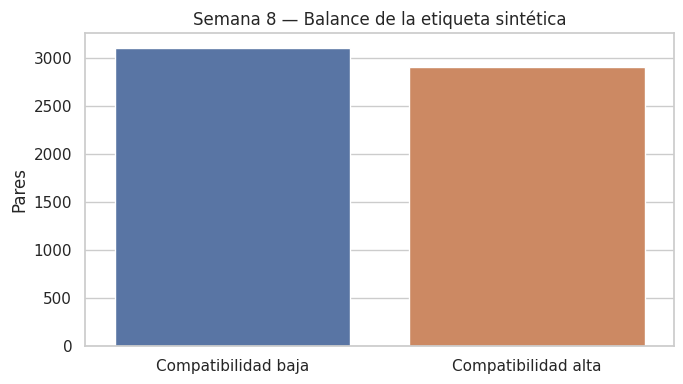

In [ ]:
# ============================================================
# 52. DIAGNÓSTICO DE BALANCE Y PESOS DE CLASE
# ============================================================

from sklearn.utils.class_weight import compute_class_weight

conteo_clases = y.value_counts().sort_index()
clase_minoritaria = int(conteo_clases.idxmin())
razon_balance = float(conteo_clases.min() / conteo_clases.max())

clases_train = np.sort(y_train80.unique())
pesos_array = compute_class_weight(
    class_weight="balanced",
    classes=clases_train,
    y=y_train80.to_numpy()
)
pesos_clase_semana8 = {
    int(clase): float(peso)
    for clase, peso in zip(clases_train, pesos_array)
}

tabla_balance = pd.DataFrame({
    "Clase": conteo_clases.index,
    "Cantidad": conteo_clases.values,
    "Porcentaje": (conteo_clases.values / len(y) * 100).round(2),
    "Significado": ["Compatibilidad baja", "Compatibilidad alta"]
})

display(tabla_balance)
print(f"Razón minoritaria/mayoritaria: {razon_balance:.3f}")
print("Pesos calculados solo con entrenamiento:", pesos_clase_semana8)

estrategia_balanceo = (
    "Split estratificado + pesos de clase; SMOTE no requerido"
    if razon_balance >= 0.80
    else "Split estratificado + pesos de clase; revisar SMOTE solo como experimento"
)
print("Estrategia:", estrategia_balanceo)

plt.figure(figsize=(7, 4))
sns.barplot(data=tabla_balance, x="Significado", y="Cantidad", hue="Significado", legend=False)
plt.title("Semana 8 — Balance de la etiqueta sintética")
plt.xlabel("")
plt.ylabel("Pares")
plt.tight_layout()
plt.show()


## 53. Verificación del preprocesamiento sin fuga de información

El `ColumnTransformer` de la configuración 80/10/10 ya fue ajustado con `fit_transform(X_train80)` y se aplicó a validación y prueba únicamente mediante `transform`. En consecuencia, las medias, desviaciones y categorías del preprocesador proceden solo del conjunto de entrenamiento.


In [ ]:
# ============================================================
# 53. AUDITORÍA DEL SPLIT Y DEL PREPROCESAMIENTO
# ============================================================

auditoria_split = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación", "Prueba"],
    "Registros": [len(X_train80), len(X_val80), len(X_test80)],
    "Porcentaje": [
        len(X_train80) / len(X) * 100,
        len(X_val80) / len(X) * 100,
        len(X_test80) / len(X) * 100
    ],
    "Transformación": [
        "fit_transform: aprende parámetros",
        "transform: no aprende parámetros",
        "transform: no aprende parámetros"
    ]
})

display(auditoria_split.round(2))
print("Forma original:", X.shape)
print("Forma preprocesada:", X_train80_p.shape)
print("Numéricas escaladas:", len(numericas_modelo))
print("Categóricas codificadas:", len(categoricas_modelo))

assert set(X_train80.index).isdisjoint(X_val80.index)
assert set(X_train80.index).isdisjoint(X_test80.index)
assert set(X_val80.index).isdisjoint(X_test80.index)
print("✓ No existen índices compartidos entre train, validación y prueba.")


,Conjunto,Registros,Porcentaje,Transformación
0,Entrenamiento,4800,80.0,fit_transform: aprende parámetros
1,Validación,600,10.0,transform: no aprende parámetros
2,Prueba,600,10.0,transform: no aprende parámetros


Forma original: (6000, 18)
Forma preprocesada: (4800, 51)
Numéricas escaladas: 12
Categóricas codificadas: 6
✓ No existen índices compartidos entre train, validación y prueba.


## 54. TensorFlow + Keras con pesos de clase

Se entrena una extensión del modelo optimizado, conservando `32 → Dropout(0,30) → 16 → Dropout(0,30) → Sigmoid`, Adam con tasa de aprendizaje de 0,001, Binary Crossentropy, máximo de 60 épocas y parada temprana. La diferencia es que `class_weight` incorpora el balance calculado en entrenamiento.


In [ ]:
# ============================================================
# 54. ENTRENAMIENTO KERAS BALANCEADO — SEMANA 8
# ============================================================

def construir_mlp_keras_semana8(input_dim):
    modelo = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dropout(0.30),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ], name="AgroConecta_MLP_Keras_Semana8")

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )
    return modelo

modelo_keras_balanceado = construir_mlp_keras_semana8(X_train80_p.shape[1])
early_keras_s8 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

hist_keras_s8 = modelo_keras_balanceado.fit(
    X_train80_p.astype("float32"),
    y_train80.to_numpy().astype("float32"),
    validation_data=(
        X_val80_p.astype("float32"),
        y_val80.to_numpy().astype("float32")
    ),
    class_weight=pesos_clase_semana8,
    epochs=60,
    batch_size=32,
    callbacks=[early_keras_s8],
    verbose=1
)

met_keras_s8, prob_keras_s8, pred_keras_s8 = evaluar_modelo(
    modelo_keras_balanceado,
    X_test80_p.astype("float32"),
    y_test80,
    "TensorFlow/Keras balanceado"
)
display(pd.DataFrame([met_keras_s8]).round(4))


Epoch 1/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5846 - loss: 0.6744 - precision: 0.5677 - recall: 0.5863 - val_accuracy: 0.7317 - val_loss: 0.5850 - val_precision: 0.7074 - val_recall: 0.7586
Epoch 2/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6904 - loss: 0.5709 - precision: 0.6812 - recall: 0.6747 - val_accuracy: 0.7983 - val_loss: 0.4932 - val_precision: 0.7538 - val_recall: 0.8655
Epoch 3/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7556 - loss: 0.5027 - precision: 0.7396 - recall: 0.7623 - val_accuracy: 0.8233 - val_loss: 0.4157 - val_precision: 0.7706 - val_recall: 0.9034
Epoch 4/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7969 - loss: 0.4332 - precision: 0.7746 - recall: 0.8171 - val_accuracy: 0.8483 - val_loss: 0.3558 - val_precision: 0.7901 - val_recall: 0.9345
Epoch 5/60
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8283 - loss: 0.3882 - precision: 0.8032 - recall: 0.8538 - val_accuracy: 0.8683 - val_loss: 0.

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,TensorFlow/Keras balanceado,0.98,0.9664,0.9931,0.9796,0.998,0.9981


## 55. Implementación equivalente con PyTorch

PyTorch recibe exactamente las matrices transformadas por `prep80`. La capa final entrega *logits* y `BCEWithLogitsLoss` aplica internamente la función sigmoide de manera numéricamente estable. El `pos_weight` se calcula únicamente con las etiquetas de entrenamiento. La comparación es técnica: el recomendador final continúa usando Keras para conservar la interfaz desarrollada en Semana 6.


In [ ]:
# ============================================================
# 55. ENTRENAMIENTO COMPARATIVO CON PYTORCH
# ============================================================

import copy
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(SEED)
np.random.seed(SEED)
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Xtr_t = torch.tensor(X_train80_p, dtype=torch.float32)
ytr_t = torch.tensor(y_train80.to_numpy(), dtype=torch.float32).view(-1, 1)
Xva_t = torch.tensor(X_val80_p, dtype=torch.float32)
yva_t = torch.tensor(y_val80.to_numpy(), dtype=torch.float32).view(-1, 1)
Xte_t = torch.tensor(X_test80_p, dtype=torch.float32)

generador_torch = torch.Generator().manual_seed(SEED)
loader_train = DataLoader(
    TensorDataset(Xtr_t, ytr_t),
    batch_size=32,
    shuffle=True,
    generator=generador_torch
)

class AgroConectaMLPTorch(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.red(x)

modelo_torch = AgroConectaMLPTorch(X_train80_p.shape[1]).to(dispositivo)
n_neg = float((y_train80 == 0).sum())
n_pos = float((y_train80 == 1).sum())
pos_weight = torch.tensor([n_neg / max(n_pos, 1.0)], device=dispositivo)
criterio_torch = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizador_torch = torch.optim.Adam(modelo_torch.parameters(), lr=0.001)

hist_torch = {"loss": [], "val_loss": []}
mejor_estado = None
mejor_val_loss = float("inf")
paciencia = 8
sin_mejora = 0

for epoca in range(1, 61):
    modelo_torch.train()
    perdidas = []
    for xb, yb in loader_train:
        xb, yb = xb.to(dispositivo), yb.to(dispositivo)
        optimizador_torch.zero_grad()
        loss = criterio_torch(modelo_torch(xb), yb)
        loss.backward()
        optimizador_torch.step()
        perdidas.append(loss.item())

    modelo_torch.eval()
    with torch.no_grad():
        val_loss = criterio_torch(
            modelo_torch(Xva_t.to(dispositivo)),
            yva_t.to(dispositivo)
        ).item()

    train_loss = float(np.mean(perdidas))
    hist_torch["loss"].append(train_loss)
    hist_torch["val_loss"].append(val_loss)

    if val_loss < mejor_val_loss - 1e-5:
        mejor_val_loss = val_loss
        mejor_estado = copy.deepcopy(modelo_torch.state_dict())
        sin_mejora = 0
    else:
        sin_mejora += 1

    if epoca == 1 or epoca % 10 == 0:
        print(f"Época {epoca:02d} | loss={train_loss:.4f} | val_loss={val_loss:.4f}")
    if sin_mejora >= paciencia:
        print(f"Early stopping en época {epoca}.")
        break

modelo_torch.load_state_dict(mejor_estado)
modelo_torch.eval()
with torch.no_grad():
    logits_test = modelo_torch(Xte_t.to(dispositivo))
    prob_torch_s8 = torch.sigmoid(logits_test).cpu().numpy().ravel()

pred_torch_s8 = (prob_torch_s8 >= 0.50).astype(int)
met_torch_s8 = {
    "Modelo": "PyTorch balanceado",
    "Accuracy": accuracy_score(y_test80, pred_torch_s8),
    "Precision": precision_score(y_test80, pred_torch_s8, zero_division=0),
    "Recall": recall_score(y_test80, pred_torch_s8, zero_division=0),
    "F1": f1_score(y_test80, pred_torch_s8, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test80, prob_torch_s8),
    "PR-AUC": average_precision_score(y_test80, prob_torch_s8)
}

print("Dispositivo PyTorch:", dispositivo)
display(pd.DataFrame([met_torch_s8]).round(4))


Época 01 | loss=0.6826 | val_loss=0.6021
Época 10 | loss=0.1669 | val_loss=0.1057
Época 20 | loss=0.0855 | val_loss=0.0609
Época 30 | loss=0.0779 | val_loss=0.0543
Época 40 | loss=0.0682 | val_loss=0.0475
Early stopping en época 49.
Dispositivo PyTorch: cuda


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,PyTorch balanceado,0.9767,0.9726,0.9793,0.9759,0.9969,0.9976


## 56. Comparación justa entre frameworks

La tabla compara modelos evaluados con el conjunto de prueba 80/10/10. Diferencias pequeñas son esperables por la inicialización y los algoritmos internos. El objetivo no es declarar un framework “ganador”, sino comprobar que el patrón aprendido es reproducible.


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Optimizado 80/10/10 — DP 0.30,0.9800,0.9664,0.9931,0.9796,0.9991,0.9991
1,TensorFlow/Keras balanceado,0.9800,0.9664,0.9931,0.9796,0.9980,0.9981
2,PyTorch balanceado,0.9767,0.9726,0.9793,0.9759,0.9969,0.9976


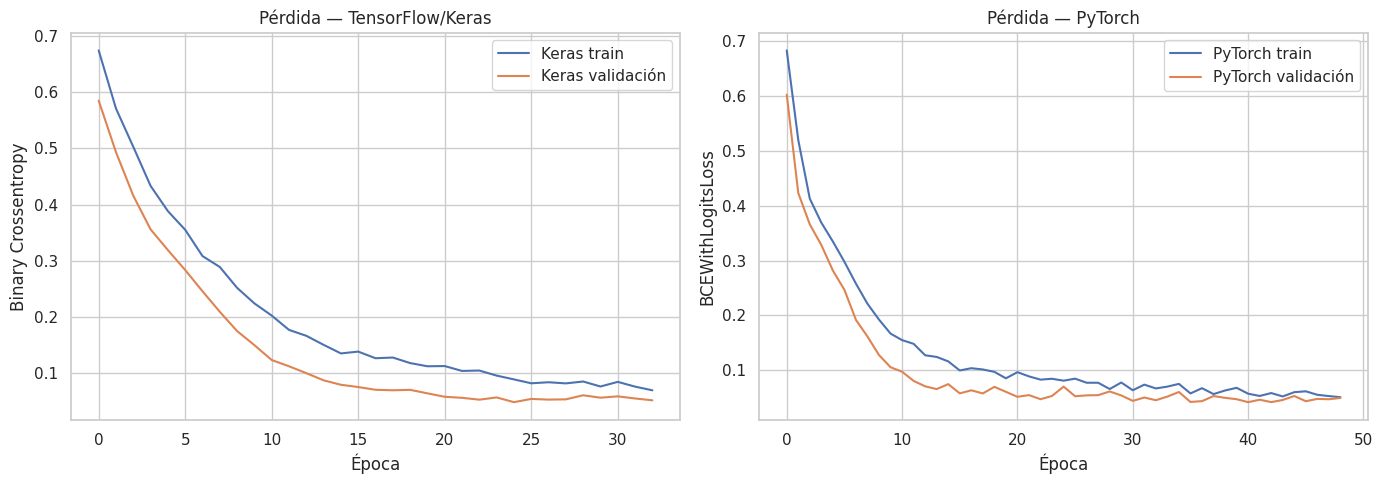

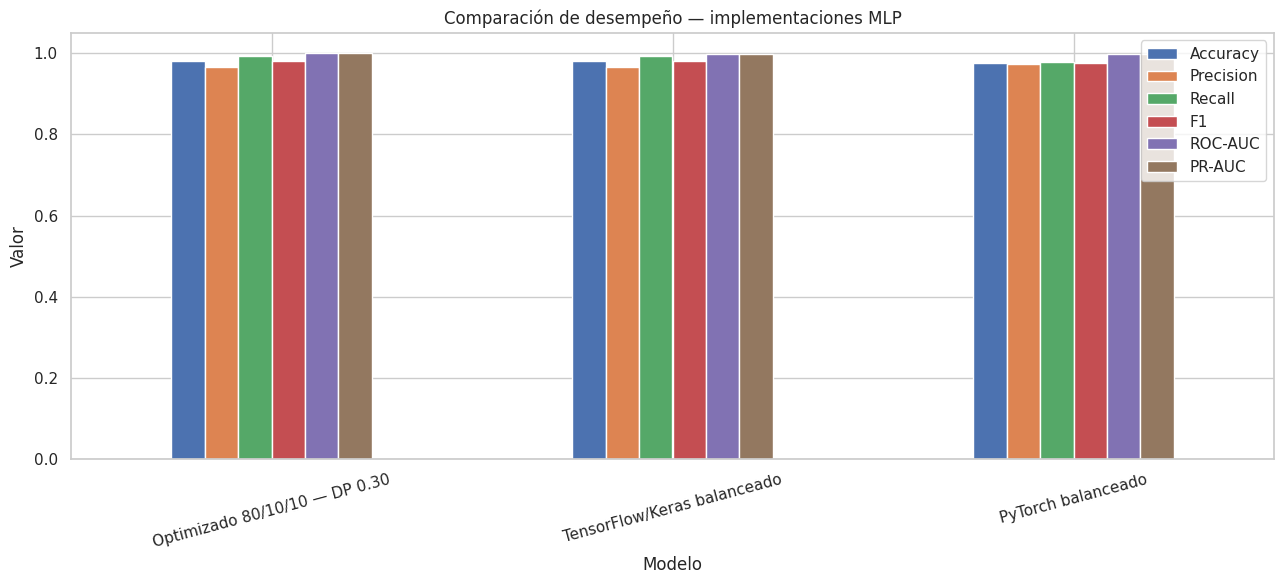

Modelo Keras conectado al recomendador: Keras optimizado 80/10/10
F1 seleccionado: 0.9796
Modelo PyTorch guardado como evidencia comparativa.


In [ ]:
# ============================================================
# 56. CURVAS Y MÉTRICAS KERAS–PYTORCH
# ============================================================

comparacion_frameworks = pd.DataFrame([
    met_opt,
    met_keras_s8,
    met_torch_s8
])
display(comparacion_frameworks.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist_keras_s8.history["loss"], label="Keras train")
axes[0].plot(hist_keras_s8.history["val_loss"], label="Keras validación")
axes[0].set_title("Pérdida — TensorFlow/Keras")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Binary Crossentropy")
axes[0].legend()

axes[1].plot(hist_torch["loss"], label="PyTorch train")
axes[1].plot(hist_torch["val_loss"], label="PyTorch validación")
axes[1].set_title("Pérdida — PyTorch")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("BCEWithLogitsLoss")
axes[1].legend()
plt.tight_layout()
plt.show()

ax = comparacion_frameworks.set_index("Modelo")[[
    "Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"
]].plot(kind="bar", figsize=(13, 6))
ax.set_ylim(0, 1.05)
ax.set_title("Comparación de desempeño — implementaciones MLP")
ax.set_ylabel("Valor")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

# El recomendador conserva Keras. Se selecciona la mejor versión Keras por F1.
candidatos_keras = [
    (met_base, modelo_base, prep70, "Keras base 70/15/15"),
    (met_opt, modelo_optimizado, prep80, "Keras optimizado 80/10/10"),
    (met_keras_s8, modelo_keras_balanceado, prep80, "Keras balanceado Semana 8")
]
metrica_final, modelo_final, preprocesador_final, nombre_configuracion_final = max(
    candidatos_keras,
    key=lambda elemento: elemento[0]["F1"]
)
f1_final = metrica_final["F1"]

modelo_final.save("AgroConecta_MLP_Keras_Final_Integrado.keras")
joblib.dump(preprocesador_final, "AgroConecta_Preprocesador_Final_Integrado.pkl")
torch.save({
    "model_state_dict": modelo_torch.state_dict(),
    "input_dim": int(X_train80_p.shape[1]),
    "arquitectura": [32, 16, 1],
    "dropout": 0.30,
    "umbral": 0.50
}, "AgroConecta_MLP_PyTorch_Comparativo.pt")

print("Modelo Keras conectado al recomendador:", nombre_configuracion_final)
print(f"F1 seleccionado: {f1_final:.4f}")
print("Modelo PyTorch guardado como evidencia comparativa.")


---
# PARTE V — SEMANA 9
# Diccionario de datos y visualización inicial de patrones

Se documentan dos niveles: las 15 variables del CSV limpio y las 18 entradas del modelo. Esta separación permite distinguir los datos proporcionados por los actores de las características construidas para comparar una oferta con una demanda.


In [ ]:
# ============================================================
# 57. DICCIONARIO DE LAS 15 VARIABLES DEL DATASET
# ============================================================

diccionario_dataset = pd.DataFrame([
    ["id_registro", "Identificador", "Texto", "Código único del registro", "No aplica", "Validar unicidad; se excluye del modelo"],
    ["rol", "Socioeconómica", "Categórica", "Actor que publica el registro", "Productor/Comprador", "Normalización canónica"],
    ["producto", "Productiva", "Categórica", "Producto ofrecido o solicitado", "Nombre de producto", "Catálogo de 10 productos"],
    ["zona", "Territorial", "Categórica", "Zona general de ubicación", "Zona", "Normalización a cinco zonas"],
    ["cantidad_kg", "Productiva", "Numérica continua", "Cantidad ofrecida o requerida", "kg", "Imputación por mediana de producto y rol; límites 0–5.000"],
    ["precio_objetivo_cop_kg", "Económica", "Numérica continua", "Precio esperado o presupuesto", "COP/kg", "Imputación por mediana; límites 0–100.000"],
    ["fecha_registro", "Temporal", "Fecha", "Fecha de creación del registro", "AAAA-MM-DD", "Conversión datetime e imputación controlada"],
    ["fecha_disponibilidad_o_necesidad", "Temporal", "Fecha", "Fecha esperada para vender o comprar", "AAAA-MM-DD", "Conversión datetime e imputación controlada"],
    ["transporte_disponible", "Logística", "Categórica binaria", "Disponibilidad de transporte", "Sí/No", "Normalización de variantes"],
    ["dias_desde_cosecha", "Productiva", "Numérica discreta", "Antigüedad del producto cosechado", "días", "Validación e imputación por rol"],
    ["vida_util_restante_dias", "Productiva", "Numérica discreta", "Vida útil estimada restante", "días", "Validación e imputación por producto"],
    ["plazo_maximo_compra_dias", "Comercial", "Numérica discreta", "Tiempo máximo que acepta esperar el comprador", "días", "Validación e imputación por rol"],
    ["tipo_comprador", "Socioeconómica", "Categórica", "Clasificación del comprador", "Categoría", "No aplica para productor; categoría desconocida controlada"],
    ["frecuencia_compra", "Comercial", "Categórica", "Periodicidad de compra", "Categoría", "No aplica para productor; normalización"],
    ["activo", "Operativa", "Binaria", "Indica si el registro participa en recomendaciones", "0/1", "Conversión a entero y validación"]
], columns=["Variable", "Dimensión", "Tipo", "Descripción", "Unidad/Dominio", "Tratamiento"])

display(diccionario_dataset)
print("Variables documentadas:", len(diccionario_dataset))


,Variable,Dimensión,Tipo,Descripción,Unidad/Dominio,Tratamiento
0,id_registro,Identificador,Texto,Código único del registro,No aplica,Validar unicidad; se excluye del modelo
1,rol,Socioeconómica,Categórica,Actor que publica el registro,Productor/Comprador,Normalización canónica
2,producto,Productiva,Categórica,Producto ofrecido o solicitado,Nombre de producto,Catálogo de 10 productos
3,zona,Territorial,Categórica,Zona general de ubicación,Zona,Normalización a cinco zonas
4,cantidad_kg,Productiva,Numérica continua,Cantidad ofrecida o requerida,kg,Imputación por mediana de producto y rol; lími...
5,precio_objetivo_cop_kg,Económica,Numérica continua,Precio esperado o presupuesto,COP/kg,Imputación por mediana; límites 0–100.000
6,fecha_registro,Temporal,Fecha,Fecha de creación del registro,AAAA-MM-DD,Conversión datetime e imputación controlada
7,fecha_disponibilidad_o_necesidad,Temporal,Fecha,Fecha esperada para vender o comprar,AAAA-MM-DD,Conversión datetime e imputación controlada
8,transporte_disponible,Logística,Categórica binaria,Disponibilidad de transporte,Sí/No,Normalización de variantes
9,dias_desde_cosecha,Productiva,Numérica discreta,Antigüedad del producto cosechado,días,Validación e imputación por rol


Variables documentadas: 15


In [ ]:
# ============================================================
# 58. DICCIONARIO DE LAS 18 VARIABLES DEL MODELO
# ============================================================

descripciones_modelo = {
    "producto_productor": ("Categórica", "Producto publicado por el productor", "One-Hot"),
    "producto_comprador": ("Categórica", "Producto solicitado por el comprador", "One-Hot"),
    "zona_productor": ("Categórica", "Zona del productor", "One-Hot"),
    "zona_comprador": ("Categórica", "Zona del comprador", "One-Hot"),
    "tipo_comprador": ("Categórica", "Perfil comercial del comprador", "One-Hot"),
    "frecuencia_compra": ("Categórica", "Periodicidad declarada de compra", "One-Hot"),
    "cantidad_ofrecida_kg": ("Numérica", "Cantidad disponible", "StandardScaler"),
    "cantidad_solicitada_kg": ("Numérica", "Cantidad demandada", "StandardScaler"),
    "precio_productor": ("Numérica", "Precio esperado por el productor", "StandardScaler"),
    "presupuesto_comprador": ("Numérica", "Presupuesto del comprador por kg", "StandardScaler"),
    "compatibilidad_cantidad": ("Numérica [0,1]", "Proporción entre cantidades", "StandardScaler"),
    "brecha_precio_relativa": ("Numérica", "Diferencia relativa de precio", "StandardScaler"),
    "transporte_compatible": ("Binaria", "Cumplimiento del límite logístico", "StandardScaler"),
    "vida_util_restante_dias": ("Numérica", "Permanencia estimada del producto", "StandardScaler"),
    "plazo_maximo_compra_dias": ("Numérica", "Plazo máximo de compra", "StandardScaler"),
    "distancia_estimada": ("Numérica", "Distancia territorial didáctica", "StandardScaler"),
    "compatibilidad_distancia": ("Numérica [0,1]", "Margen disponible frente al límite logístico", "StandardScaler"),
    "misma_temporalidad": ("Binaria", "Fechas separadas por máximo 14 días", "StandardScaler")
}

diccionario_modelo = pd.DataFrame([
    [variable, *descripciones_modelo[variable]]
    for variable in features
], columns=["Variable", "Tipo", "Descripción", "Transformación"])

display(diccionario_modelo)
print("Variables de entrada documentadas:", len(diccionario_modelo))


,Variable,Tipo,Descripción,Transformación
0,producto_productor,Categórica,Producto publicado por el productor,One-Hot
1,producto_comprador,Categórica,Producto solicitado por el comprador,One-Hot
2,zona_productor,Categórica,Zona del productor,One-Hot
3,zona_comprador,Categórica,Zona del comprador,One-Hot
4,tipo_comprador,Categórica,Perfil comercial del comprador,One-Hot
5,frecuencia_compra,Categórica,Periodicidad declarada de compra,One-Hot
6,cantidad_ofrecida_kg,Numérica,Cantidad disponible,StandardScaler
7,cantidad_solicitada_kg,Numérica,Cantidad demandada,StandardScaler
8,precio_productor,Numérica,Precio esperado por el productor,StandardScaler
9,presupuesto_comprador,Numérica,Presupuesto del comprador por kg,StandardScaler


Variables de entrada documentadas: 18


## 59. Visualización inicial de patrones significativos

Las gráficas relacionan directamente la problemática comercial con las variables del modelo: disponibilidad por producto, cobertura territorial, balance de oportunidades y efecto de cantidad, precio y distancia. Las asociaciones no prueban causalidad, especialmente porque la etiqueta es sintética.


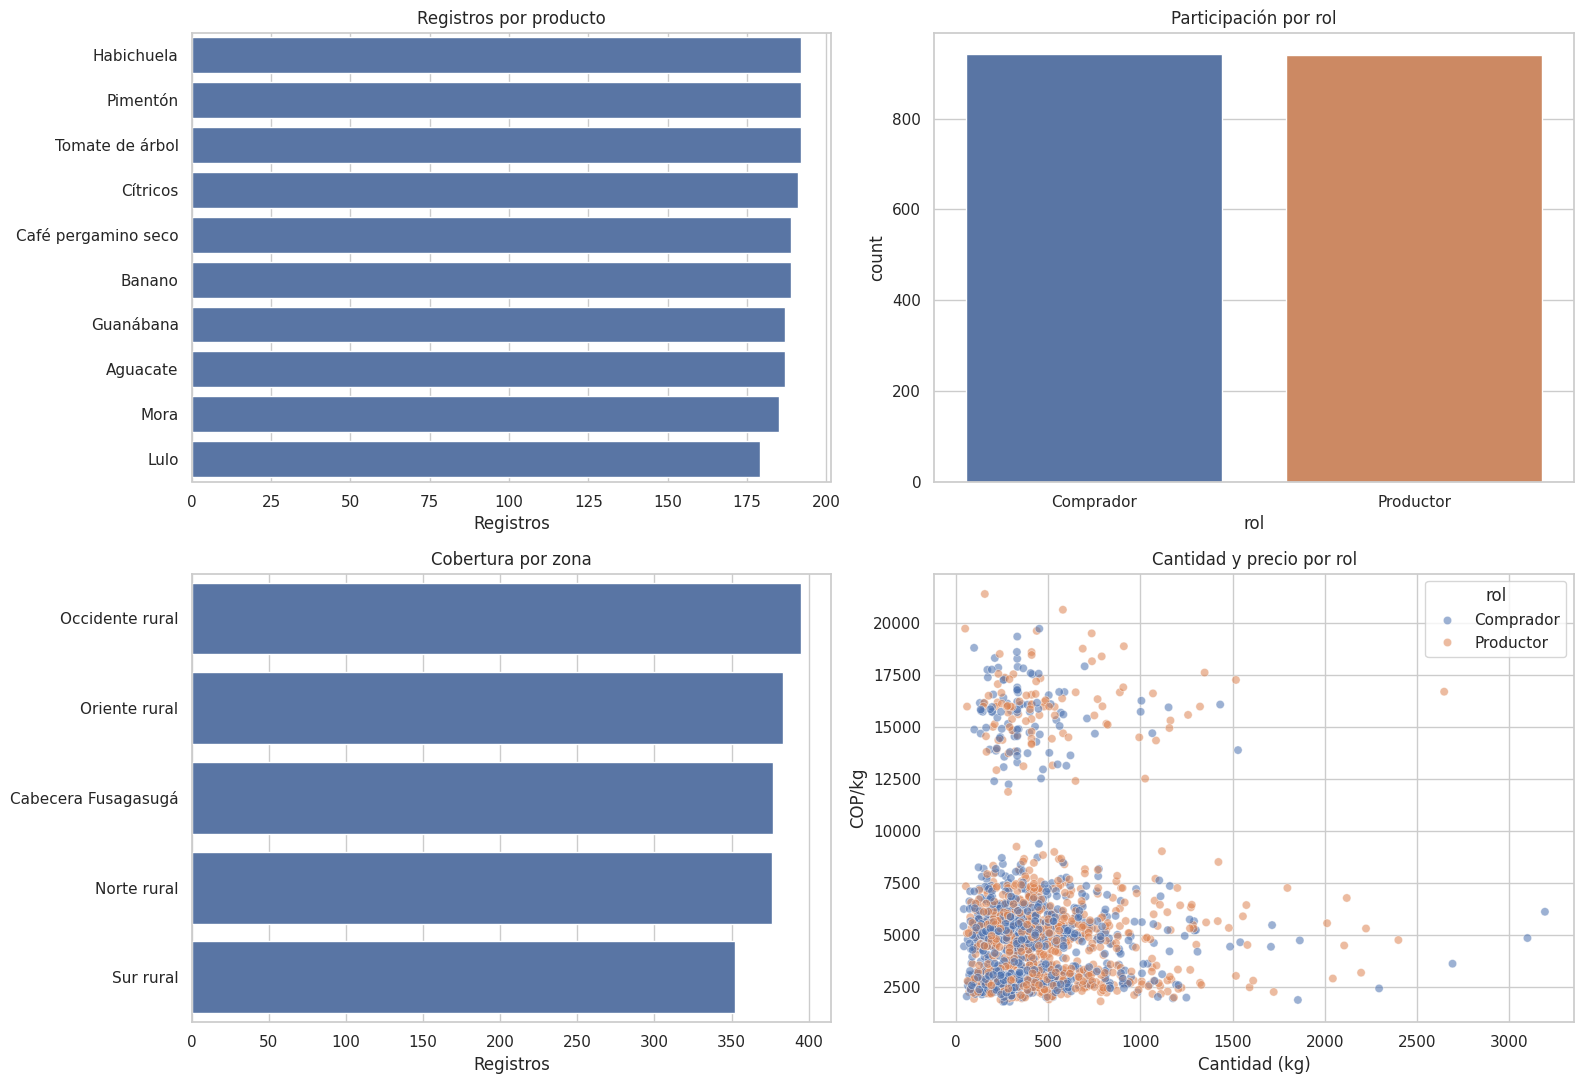

In [ ]:
# ============================================================
# 59. PANEL EXPLORATORIO DEL DATASET LIMPIO
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
sns.countplot(data=df_entrenamiento, y="producto", order=df_entrenamiento["producto"].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title("Registros por producto")
axes[0, 0].set_xlabel("Registros")
axes[0, 0].set_ylabel("")

sns.countplot(data=df_entrenamiento, x="rol", hue="rol", legend=False, ax=axes[0, 1])
axes[0, 1].set_title("Participación por rol")

sns.countplot(data=df_entrenamiento, y="zona", order=df_entrenamiento["zona"].value_counts().index, ax=axes[1, 0])
axes[1, 0].set_title("Cobertura por zona")
axes[1, 0].set_xlabel("Registros")
axes[1, 0].set_ylabel("")

sns.scatterplot(data=df_entrenamiento, x="cantidad_kg", y="precio_objetivo_cop_kg", hue="rol", alpha=0.55, ax=axes[1, 1])
axes[1, 1].set_title("Cantidad y precio por rol")
axes[1, 1].set_xlabel("Cantidad (kg)")
axes[1, 1].set_ylabel("COP/kg")
plt.tight_layout()
plt.show()


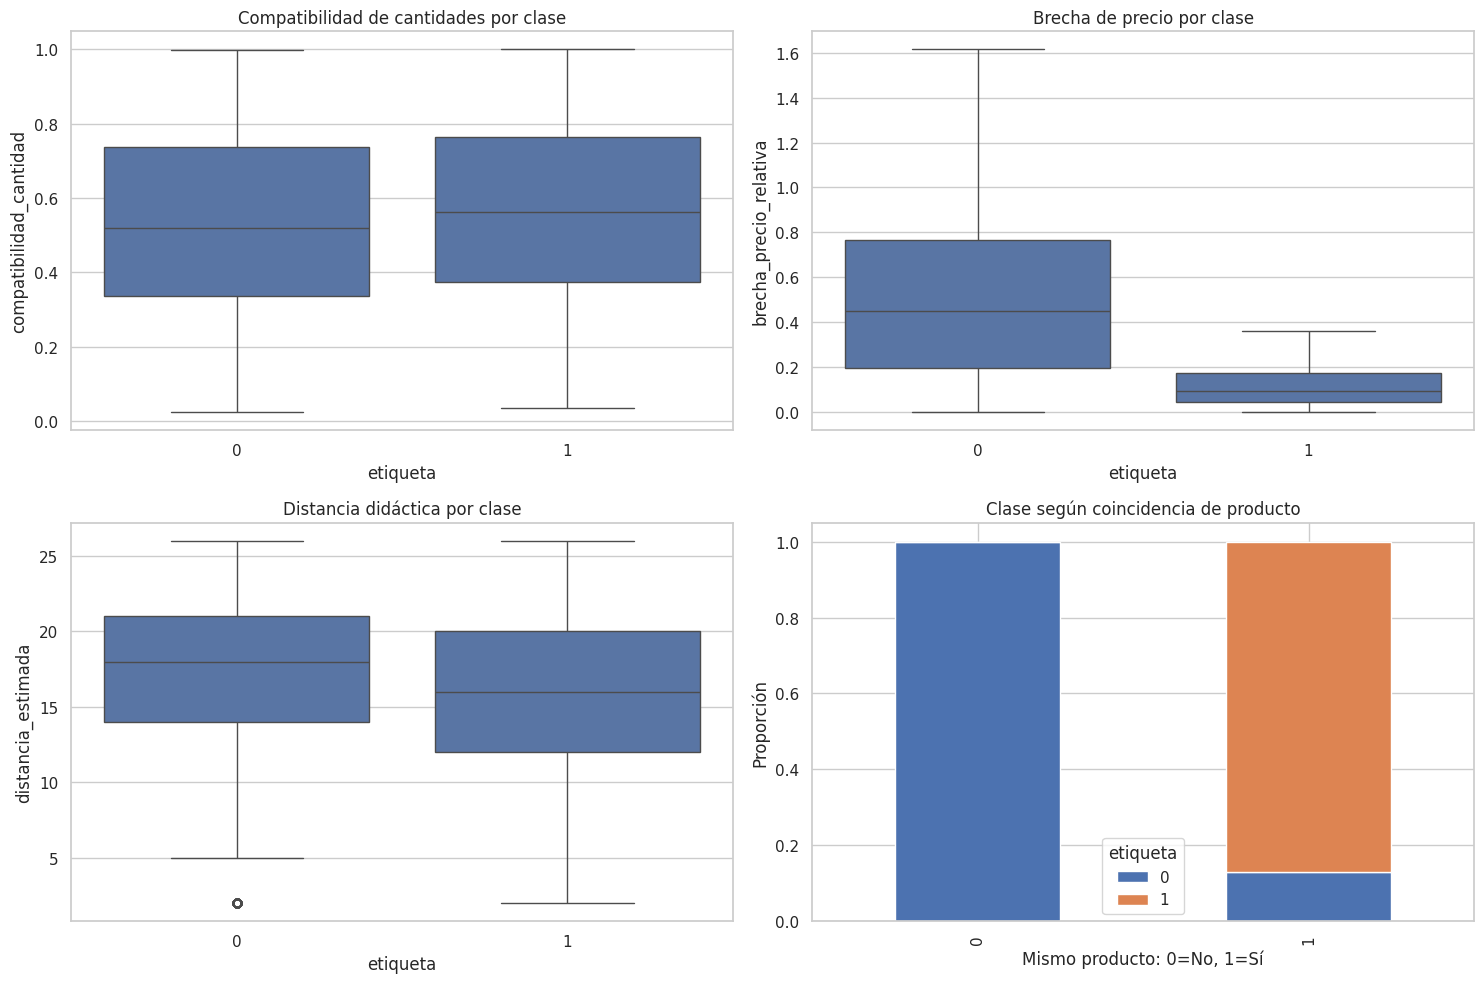

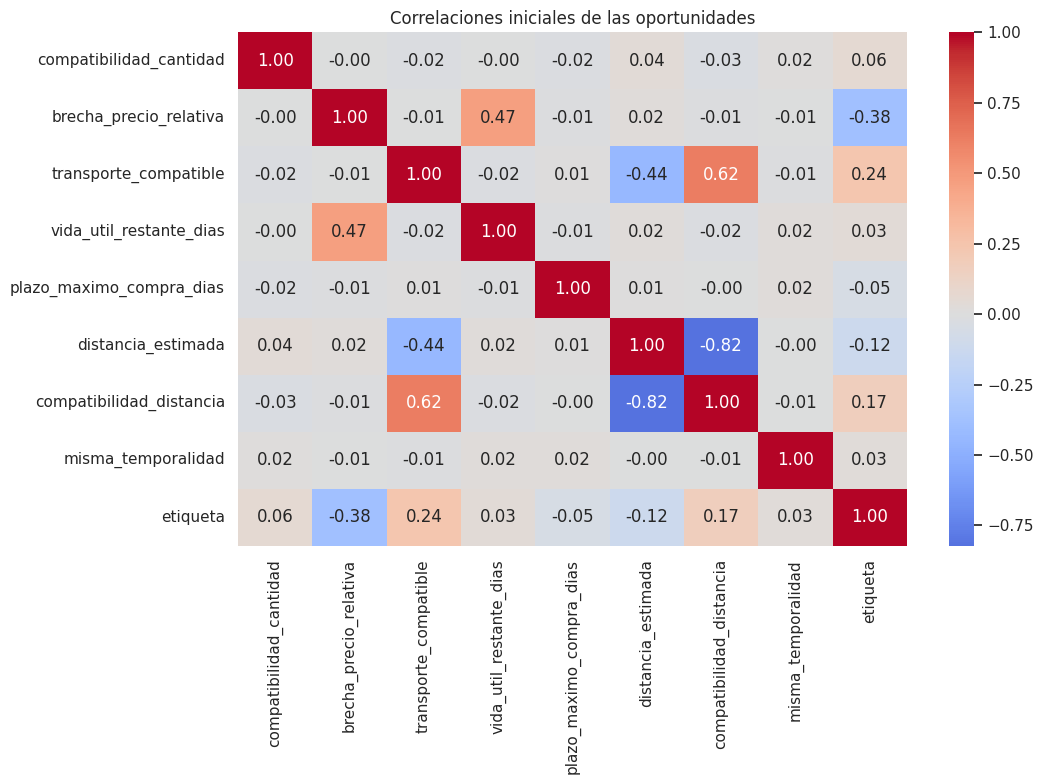

In [ ]:
# ============================================================
# 60. PATRONES DE COMPATIBILIDAD EN LOS PARES
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.boxplot(data=pares, x="etiqueta", y="compatibilidad_cantidad", ax=axes[0, 0])
axes[0, 0].set_title("Compatibilidad de cantidades por clase")

sns.boxplot(data=pares, x="etiqueta", y="brecha_precio_relativa", showfliers=False, ax=axes[0, 1])
axes[0, 1].set_title("Brecha de precio por clase")

sns.boxplot(data=pares, x="etiqueta", y="distancia_estimada", ax=axes[1, 0])
axes[1, 0].set_title("Distancia didáctica por clase")

tabla_producto_clase = pd.crosstab(pares["mismo_producto"], pares["etiqueta"], normalize="index")
tabla_producto_clase.plot(kind="bar", stacked=True, ax=axes[1, 1])
axes[1, 1].set_title("Clase según coincidencia de producto")
axes[1, 1].set_xlabel("Mismo producto: 0=No, 1=Sí")
axes[1, 1].set_ylabel("Proporción")
plt.tight_layout()
plt.show()

variables_correlacion = [
    "compatibilidad_cantidad", "brecha_precio_relativa",
    "transporte_compatible", "vida_util_restante_dias",
    "plazo_maximo_compra_dias", "distancia_estimada",
    "compatibilidad_distancia", "misma_temporalidad", "etiqueta"
]
plt.figure(figsize=(11, 8))
sns.heatmap(pares[variables_correlacion].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlaciones iniciales de las oportunidades")
plt.tight_layout()
plt.show()


## 61. Exportación reproducible

El paquete final reúne datos, documentación, transformadores y modelos. El CSV sucio no se incluye para evitar confundirlo con la fuente apta para entrenamiento; debe conservarse aparte como evidencia de entrada de Semana 4.


In [ ]:
# ============================================================
# 61. EXPORTAR ENTREGABLES DE SEMANAS 4–9
# ============================================================

from pathlib import Path
import zipfile

CARPETA_ENTREGA = Path("AgroConecta_Entregables_Integrados")
CARPETA_ENTREGA.mkdir(exist_ok=True)

df_entrenamiento.to_csv(CARPETA_ENTREGA / "AgroConecta_Dataset_Limpio.csv", index=False, encoding="utf-8-sig")
pares.to_csv(CARPETA_ENTREGA / "AgroConecta_Pares_Productor_Comprador.csv", index=False, encoding="utf-8-sig")
diccionario_dataset.to_csv(CARPETA_ENTREGA / "AgroConecta_Diccionario_Dataset.csv", index=False, encoding="utf-8-sig")
diccionario_modelo.to_csv(CARPETA_ENTREGA / "AgroConecta_Diccionario_Modelo.csv", index=False, encoding="utf-8-sig")
comparacion_frameworks.to_csv(CARPETA_ENTREGA / "AgroConecta_Metricas_Frameworks.csv", index=False, encoding="utf-8-sig")

modelo_final.save(CARPETA_ENTREGA / "AgroConecta_MLP_Keras_Final.keras")
joblib.dump(preprocesador_final, CARPETA_ENTREGA / "AgroConecta_Preprocesador.pkl")
torch.save({
    "model_state_dict": modelo_torch.state_dict(),
    "input_dim": int(X_train80_p.shape[1]),
    "features": features,
    "dropout": 0.30
}, CARPETA_ENTREGA / "AgroConecta_MLP_PyTorch_Comparativo.pt")

metadata_integrada = {
    "proyecto": "AgroConecta IA",
    "semanas": [4, 5, 6, 8, 9],
    "registros_iniciales": int(len(df_sucio)),
    "registros_limpios": int(len(df_entrenamiento)),
    "variables_dataset": int(len(COLUMNAS_BASE_V3)),
    "pares": int(len(pares)),
    "variables_modelo": int(len(features)),
    "caracteristicas_preprocesadas_80": int(X_train80_p.shape[1]),
    "split_optimizado": {"train": len(X_train80), "validation": len(X_val80), "test": len(X_test80)},
    "estrategia_balanceo": estrategia_balanceo,
    "pesos_clase": pesos_clase_semana8,
    "framework_principal": "TensorFlow/Keras",
    "framework_comparativo": "PyTorch",
    "modelo_interactivo": nombre_configuracion_final,
    "advertencia": "Etiqueta y distancias sintéticas; el ranking no es probabilidad calibrada de venta."
}

with open(CARPETA_ENTREGA / "AgroConecta_Metadata_Integrada.json", "w", encoding="utf-8") as archivo:
    json.dump(metadata_integrada, archivo, ensure_ascii=False, indent=2)

ruta_zip = Path("AgroConecta_IA_Entregables_Semanas_4_5_6_8_9.zip")
with zipfile.ZipFile(ruta_zip, "w", compression=zipfile.ZIP_DEFLATED) as paquete:
    for archivo in sorted(CARPETA_ENTREGA.iterdir()):
        paquete.write(archivo, arcname=archivo.name)

print("Paquete generado:", ruta_zip)
print("Contenido:")
for archivo in sorted(CARPETA_ENTREGA.iterdir()):
    print("-", archivo.name)


Paquete generado: AgroConecta_IA_Entregables_Semanas_4_5_6_8_9.zip
Contenido:
- AgroConecta_Dataset_Limpio.csv
- AgroConecta_Diccionario_Dataset.csv
- AgroConecta_Diccionario_Modelo.csv
- AgroConecta_MLP_Keras_Final.keras
- AgroConecta_MLP_PyTorch_Comparativo.pt
- AgroConecta_Metadata_Integrada.json
- AgroConecta_Metricas_Frameworks.csv
- AgroConecta_Pares_Productor_Comprador.csv
- AgroConecta_Preprocesador.pkl


# 62. Respuestas para la sustentación

1. **La limpieza ocurre antes del entrenamiento** porque nulos, errores de tipo, duplicados y outliers alterarían las relaciones aprendidas.
2. **El CSV limpio se descarga y recarga** para demostrar que Semana 5 consume un artefacto independiente, reproducible y verificable.
3. **El CSV v3 contiene** nulos, duplicados, variantes textuales, cantidades negativas o extremas, precios inválidos, fechas defectuosas y categorías inconsistentes; se corrige mediante normalización, conversión, reglas de dominio, imputación y eliminación justificada.
4. **Se usan pares Productor–Comprador** porque una oportunidad comercial depende de la compatibilidad entre una oferta y una demanda.
5. **La etiqueta es sintética** porque se deriva de reglas diseñadas y no de ventas reales observadas.
6. **Los pares coincidentes y aleatorios** aportan ejemplos positivos plausibles y casos negativos o difíciles para aprender separación.
7. **La zona se transforma en distancia** mediante una matriz territorial simétrica entre cinco zonas.
8. **La distancia es didáctica** porque no utiliza coordenadas, red vial, tráfico ni GPS.
9. **El límite logístico** es 12 km sin transporte, 22 km si una parte tiene transporte y 35 km si ambas lo tienen.
10. **Las curvas de pérdida** muestran si el error disminuye y si validación acompaña al entrenamiento.
11. **Hay sobreajuste** cuando la pérdida de entrenamiento continúa bajando mientras validación empeora de forma sostenida; Dropout y EarlyStopping lo reducen.
12. **TN, FP, FN y TP** son rechazos correctos, oportunidades falsas, oportunidades omitidas y oportunidades detectadas correctamente.
13. **Precision** mide cuántas recomendaciones positivas son correctas; **Recall**, cuántas oportunidades reales detecta; **F1** equilibra ambas.
14. **El ranking no es probabilidad de venta** porque fue entrenado con una etiqueta sintética y no está calibrado con cierres comerciales reales.
15. **Una brecha grande de precio** reduce compatibilidad porque aleja la expectativa del productor del presupuesto del comprador.
16. **Cantidades incompatibles** reducen el puntaje y pueden exigir dividir la oferta o la demanda.
17. **Sin candidatos dentro del límite**, el sistema informa la restricción y no inventa recomendaciones.
18. **El diccionario de solicitudes** relaciona expresiones del usuario con rol, producto, zona y transporte.
19. **Los datos faltantes en la frase** se solicitan mediante preguntas de aclaración: rol, producto, cantidad, zona, transporte y precio/presupuesto.
20. **Para reemplazar la etiqueta sintética** se necesitan contactos reales, negociaciones, ventas cerradas/no cerradas, cantidades, precios, tiempos, distancias y resultados logísticos.
21. **Antes de usar datos personales** se requieren consentimiento informado, minimización, cifrado, control de acceso, trazabilidad, retención limitada y anonimización.
22. **La supervisión humana permanece** porque una recomendación errónea puede afectar ingresos, inventario, transporte y relaciones comerciales.


# 63. Conclusión integrada

AgroConecta IA conserva el ciclo original y lo fortalece sin cambiar su propósito: parte de 2.000 registros sintéticos con problemas controlados, limpia y documenta la información, construye relaciones Productor–Comprador, transforma variables sin fuga, entrena una MLP y presenta oportunidades explicables al usuario.

La Semana 8 formaliza el balanceo mediante estratificación y pesos de clase y añade una réplica PyTorch de la MLP TensorFlow/Keras. La Semana 9 incorpora diccionarios de datos y visualizaciones directamente conectadas con precio, cantidad, producto, zona y logística. Keras continúa como motor del recomendador; PyTorch funciona como evidencia de portabilidad hacia una futura plataforma de software libre.

La evolución siguiente es trasladar el preprocesador y el modelo Keras a una API, almacenar actores y publicaciones en PostgreSQL y construir una interfaz web. En producción deberán sustituirse las etiquetas y distancias didácticas por transacciones autorizadas y rutas verificadas, manteniendo siempre supervisión humana.


In [ ]:
# ============================================================
# 64. DESCARGAR EL PAQUETE INTEGRADO
# ============================================================

from google.colab import files as archivos_colab
archivos_colab.download(str(ruta_zip))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
# 65. Interacción final

Esta celda se dejó al final deliberadamente. Así, al usar **Ejecutar todas**, primero se completan la limpieza, los entrenamientos, las métricas, el balanceo, los diccionarios y las exportaciones; después el usuario puede escribir su solicitud comercial.


AGROCONECTA IA — SISTEMA INTEGRADO LISTO
Modelo del recomendador: Keras optimizado 80/10/10
F1 de referencia: 0.9796
Escribe una solicitud para buscar oportunidades.
AGROCONECTA IA — IDENTIFICACIÓN DE OPORTUNIDADES

Escribe tu solicitud de forma natural.
Ejemplo: Soy comprador y necesito comprar 300 kg de mora en Norte rural. Tengo transporte.

Tu solicitud: necesito vender 56 kilos de lulo

Datos detectados inicialmente:
- rol: Productor
- producto: Lulo
- cantidad_kg: 56.0
- zona: None
- transporte_disponible: None
- precio_objetivo_cop_kg: None

Zonas disponibles:
- Cabecera Fusagasugá
- Norte rural
- Sur rural
- Oriente rural
- Occidente rural
¿En qué zona te encuentras? occidente rural
¿Cuentas con transporte? (Sí/No): no
Precio objetivo de venta por kg (COP): 6700

SOLICITUD INTERPRETADA
Rol: Productor
Producto: Lulo
Cantidad: 56.00 kg
Zona: Occidente rural
Transporte: No
Precio / presupuesto: $6,700 COP/kg

TOP 10 OPORTUNIDADES RECOMENDADAS


,id_registro,rol,producto,zona,cantidad_kg,precio_objetivo_cop_kg,transporte_disponible,distancia_estimada_km,limite_logistico_km,compatibilidad_modelo
0,REG0841,Comprador,Lulo,Cabecera Fusagasugá,174.69,"$5,854",Sí,15.0,22.0,99.49%
1,REG0811,Comprador,Lulo,Occidente rural,94.70,"$4,373",Sí,5.0,22.0,98.59%
2,REG0401,Comprador,Lulo,Cabecera Fusagasugá,107.74,"$4,297",Sí,15.0,22.0,98.06%
3,REG1997,Comprador,Lulo,Occidente rural,232.18,"$5,168",Sí,5.0,22.0,98.06%
4,REG1422,Comprador,Lulo,Occidente rural,365.52,"$5,713",Sí,5.0,22.0,97.91%
5,REG0736,Comprador,Lulo,Norte rural,151.98,"$4,744",Sí,20.0,22.0,97.83%
6,REG0558,Comprador,Lulo,Occidente rural,211.86,"$5,092",No,5.0,12.0,97.30%
7,REG0765,Comprador,Lulo,Occidente rural,765.33,"$4,771",No,5.0,12.0,96.67%
8,REG0152,Comprador,Lulo,Sur rural,126.73,"$5,055",Sí,18.0,22.0,96.56%
9,REG1933,Comprador,Lulo,Occidente rural,400.78,"$5,267",Sí,5.0,22.0,96.56%



RECOMENDACIÓN DE AGROCONECTA IA
Te recomiendo ajustar tu OFERTA: tu precio objetivo es aproximadamente $6,700 COP/kg y el mejor comprador registra cerca de $5,854 COP/kg. La mejor opción de VENTA es el comprador REG0841 en Cabecera Fusagasugá, a 15.0 km de referencia, con un puntaje de 99.49%.

Generando gráficas del Top de oportunidades...


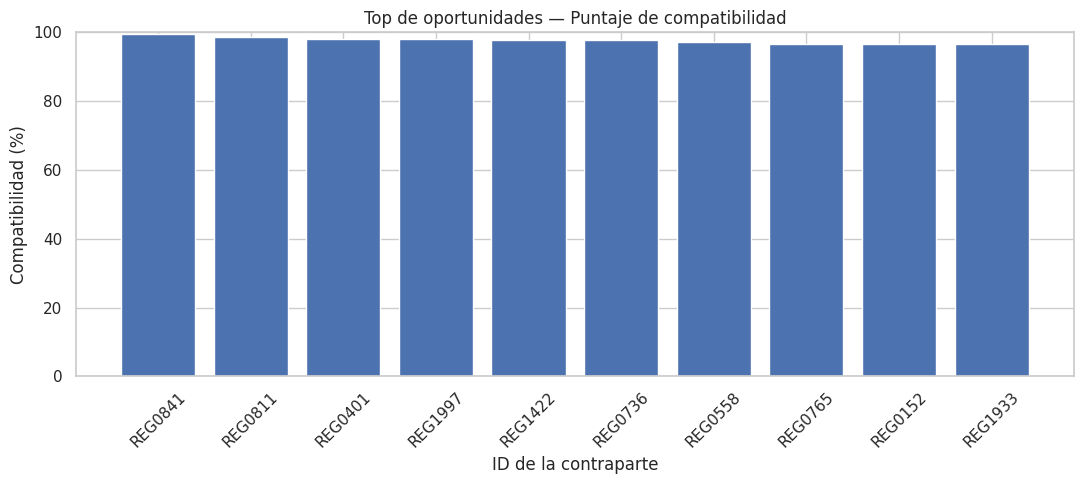

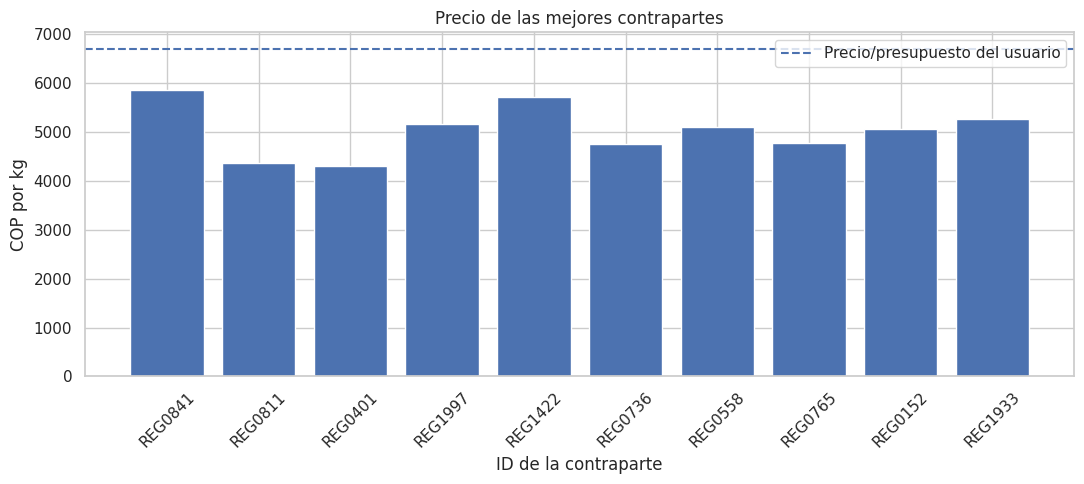

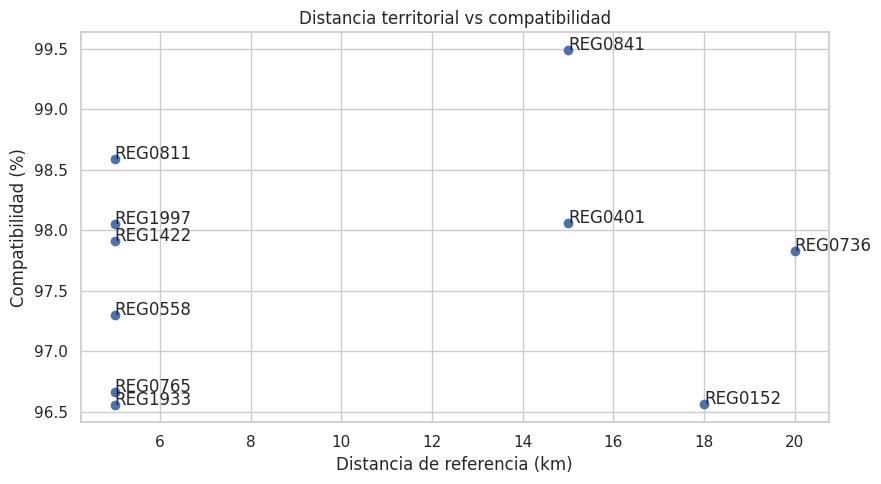


Nota: el porcentaje es un puntaje de compatibilidad aprendido sobre una etiqueta sintética; no es una probabilidad calibrada de venta.


In [ ]:
# ============================================================
# 65. INICIAR EL RECOMENDADOR INTEGRADO
# ============================================================

objetos_necesarios = [
    "modelo_final", "preprocesador_final", "metrica_final",
    "extraer_solicitud", "completar_solicitud",
    "preparar_pares_consulta", "recomendar_oportunidades",
    "generar_consejo", "graficar_recomendaciones",
    "agroconecta_interactivo"
]
faltantes = [nombre for nombre in objetos_necesarios if nombre not in globals()]
if faltantes:
    raise RuntimeError("Faltan componentes previos: " + ", ".join(faltantes))

print("=" * 72)
print("AGROCONECTA IA — SISTEMA INTEGRADO LISTO")
print("=" * 72)
print("Modelo del recomendador:", nombre_configuracion_final)
print(f"F1 de referencia: {f1_final:.4f}")
print("Escribe una solicitud para buscar oportunidades.")

resultado_interactivo = agroconecta_interactivo()
